# IMPORT LIBRARY

In [ ]:
!pip install optuna datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 18.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import drive
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support


from tqdm import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, AutoConfig, set_seed
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_fscore_support
from torch.nn.functional import softmax

from datasets import Dataset

import tensorflow as tf
import random

import optuna
from optuna.samplers import TPESampler
from optuna.samplers import GridSampler


import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"

In [ ]:
# Mount to Google Drive
drive.mount('/content/drive')

# Masuk ke folder Thesis Ardi
path = '/content/drive/MyDrive/Thesis Ardi'
os.chdir(path)

Mounted at /content/drive


# READ DATASET

In [ ]:
df = pd.read_csv('Dataset Thesis/Dataset Fix.csv')
df.head()

,Smiles,Label
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,1
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,1
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,1
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,1
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,1


# DEF UNIVERSAL

In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)

    # Print numeric results
    print(f"=== {name} ===")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"F1: {f1}")
    print("Confusion Matrix:")
    print(cm)
    print()

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [ ]:
def evaluate_tunning(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)

    # Print numeric results
    print(f"=== {name} ===")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"F1: {f1}")
    print("Confusion Matrix:")
    print(cm)
    print()

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return acc, prec, rec, f1

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=108,
        return_tensors="pt"
    )

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="macro", zero_division=0)
    rec  = recall_score(labels, preds, average="macro", zero_division=0)
    f1   = f1_score(labels, preds, average="macro", zero_division=0)

    return {
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1
    }

In [ ]:
def save_loss_from_trainer(trainer, save_path):
    train_losses = []
    eval_losses = []
    epochs = []

    for log in trainer.state.log_history:
        # Train loss (per epoch jika logging_strategy='epoch')
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_losses.append(log["loss"])
            epochs.append(log["epoch"])

        # Eval loss
        if "eval_loss" in log and "epoch" in log:
            eval_losses.append(log["eval_loss"])

    # Samakan panjang (aman dari error)
    min_len = min(len(train_losses), len(eval_losses))

    df_loss = pd.DataFrame({
        "epoch": epochs[:min_len],
        "train_loss": train_losses[:min_len],
        "eval_loss": eval_losses[:min_len]
    })

    df_loss.to_csv(save_path, index=False)
    print(f"Loss history saved to {save_path}")

    return df_loss


In [ ]:
def plot_loss(df_loss, title="Training vs Validation Loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(df_loss["epoch"], df_loss["train_loss"], marker="o", label="Train Loss")
    plt.plot(df_loss["epoch"], df_loss["eval_loss"], marker="s", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def set_all_seeds(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    set_seed(seed)
    print(f"All seeds locked to {seed}")

In [ ]:
seed_value = 42
set_all_seeds(seed_value)

All seeds locked to 42


# TRANSFORMERS BERT MODEL 1 ("JuIm/SMILES_BERT")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "JuIm/SMILES_BERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([  0, 262,  21,  33, 270,  33,  39,  12,  50,  33,  39,  21, 278,  22,
          33,  39,  12, 393,  33,  39,  22,  13,  39, 266,  51,  13, 279,  13,
         278,  23,  33,  39,  12,  39,  33,  39,  12,  39,  33,  39,  23,  13,
          50,  24, 277,  12, 262,  24,  13,  50,  12,  39,  13,  39,  13, 279,
           2,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.584900,0.607899,0.801250,0.807739,0.753950,0.869792
2,0.491000,0.525920,0.751250,0.782988,0.673546,0.934896
3,0.421900,0.563755,0.781250,0.729521,0.897338,0.614583
4,0.386500,0.455810,0.852500,0.849105,0.834171,0.864583
5,0.370400,0.509930,0.846250,0.844893,0.819071,0.872396
6,0.361900,0.402992,0.858750,0.856417,0.836228,0.877604
7,0.331300,0.470537,0.853750,0.852459,0.826406,0.880208
8,0.305700,0.600395,0.845000,0.849879,0.794118,0.914062
9,0.301700,0.526314,0.856250,0.843962,0.881020,0.809896


TrainOutput(global_step=2106, training_loss=0.3950424013201215, metrics={'train_runtime': 503.4205, 'train_samples_per_second': 74.133, 'train_steps_per_second': 9.296, 'total_flos': 932066802502560.0, 'train_loss': 0.3950424013201215, 'epoch': 9.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       416
           1       0.84      0.88      0.86       384

    accuracy                           0.86       800
   macro avg       0.86      0.86      0.86       800
weighted avg       0.86      0.86      0.86       800


Confusion Matrix:
[[350  66]
 [ 47 337]]


=== JuIm BERT Baseline Model ===
Accuracy: 0.85875
Precision: 0.8362282878411911
Recall: 0.8776041666666666
F1: 0.8564167725540025
Confusion Matrix:
[[350  66]
 [ 47 337]]



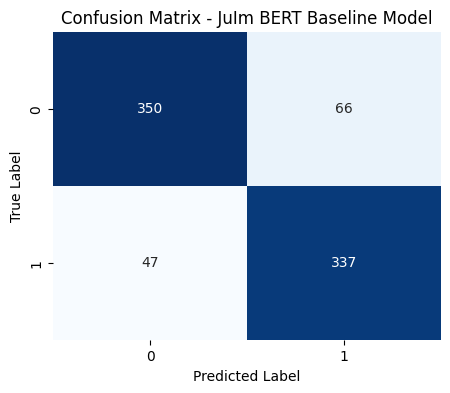

In [ ]:
# Model Evaluate
evaluate_model("JuIm BERT Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/JuIm BERT_baseline_loss.csv")

Loss history saved to Data Hasil/JuIm BERT_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training JuIm BERT with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.598200,0.641989,0.755000,0.778281,0.688000,0.895833
2,0.488300,0.497101,0.773750,0.795480,0.702595,0.916667
3,0.438300,0.434627,0.838750,0.830040,0.840000,0.820312
4,0.393000,0.460331,0.843750,0.839125,0.829517,0.848958
5,0.373400,0.747306,0.823750,0.831943,0.767033,0.908854
6,0.344000,0.408102,0.832500,0.837379,0.784091,0.898438
7,0.315900,0.589200,0.847500,0.850856,0.801843,0.906250
8,0.318100,0.508059,0.857500,0.851948,0.849741,0.854167
9,0.271700,0.602759,0.862500,0.851351,0.884831,0.820312
10,0.246200,0.598933,0.851250,0.829757,0.920635,0.755208


=== JuIm BERT  adp=0.1 hdp=0.1 ===
Accuracy: 0.86
Precision: 0.8675675675675676
Recall: 0.8359375
F1: 0.8514588859416445
Confusion Matrix:
[[367  49]
 [ 63 321]]



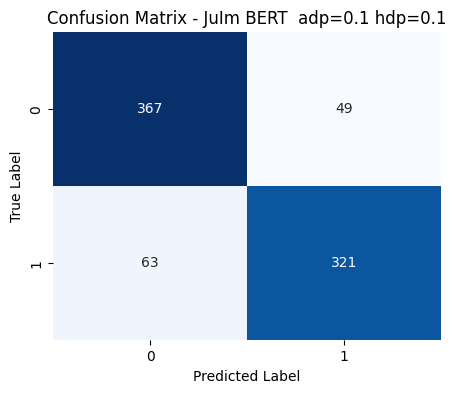


=== Training JuIm BERT with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.607800,0.816537,0.707500,0.743982,0.641509,0.885417
2,0.489300,0.405721,0.836250,0.835220,0.807786,0.864583
3,0.422200,0.398843,0.843750,0.833997,0.850949,0.817708
4,0.382000,0.410004,0.856250,0.849279,0.854881,0.843750
5,0.371200,0.484416,0.837500,0.841076,0.792627,0.895833
6,0.340000,0.498874,0.841250,0.846061,0.791383,0.908854
7,0.325100,0.539239,0.847500,0.848635,0.810427,0.890625


=== JuIm BERT  adp=0.1 hdp=0.2 ===
Accuracy: 0.8475
Precision: 0.8104265402843602
Recall: 0.890625
F1: 0.8486352357320099
Confusion Matrix:
[[336  80]
 [ 42 342]]



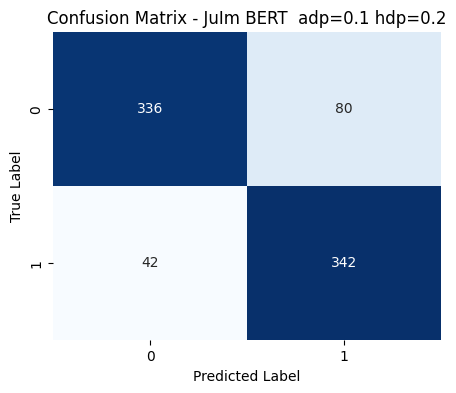


=== Training JuIm BERT with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.567100,0.721857,0.767500,0.784223,0.707113,0.880208
2,0.515200,0.475144,0.795000,0.805226,0.740175,0.882812
3,0.440500,0.461230,0.826250,0.811908,0.845070,0.781250
4,0.401000,0.459882,0.832500,0.838554,0.780269,0.906250
5,0.390400,0.545833,0.782500,0.806236,0.704280,0.942708
6,0.353900,0.419440,0.852500,0.850633,0.827586,0.875000
7,0.351800,0.573317,0.843750,0.841972,0.818182,0.867188
8,0.327600,0.542459,0.860000,0.851064,0.869565,0.833333
9,0.312200,0.659111,0.852500,0.857143,0.800905,0.921875
10,0.283500,0.578317,0.857500,0.853093,0.844388,0.861979


=== JuIm BERT  adp=0.1 hdp=0.3 ===
Accuracy: 0.85
Precision: 0.8157894736842105
Recall: 0.8880208333333334
F1: 0.8503740648379052
Confusion Matrix:
[[339  77]
 [ 43 341]]



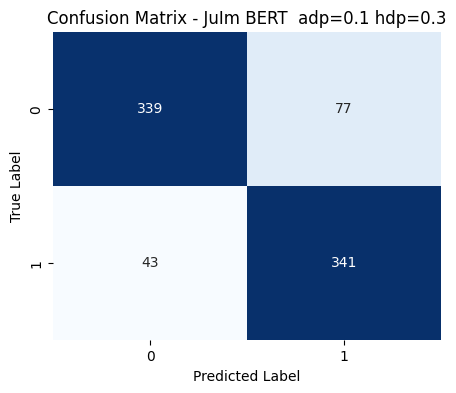


=== Training JuIm BERT with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.584700,0.643091,0.775000,0.785203,0.724670,0.856771
2,0.487200,0.448488,0.817500,0.821516,0.774194,0.875000
3,0.448500,0.590348,0.801250,0.767883,0.873754,0.684896
4,0.438600,0.495132,0.835000,0.817175,0.872781,0.768229
5,0.384900,0.498169,0.808750,0.821886,0.743158,0.919271
6,0.358300,0.466657,0.840000,0.830688,0.844086,0.817708
7,0.361200,0.450524,0.853750,0.846658,0.852243,0.841146
8,0.336800,0.485543,0.853750,0.837725,0.896142,0.786458
9,0.306000,0.521443,0.853750,0.839065,0.889213,0.794271
10,0.290100,0.539942,0.857500,0.844687,0.885714,0.807292


=== JuIm BERT  adp=0.2 hdp=0.1 ===
Accuracy: 0.8575
Precision: 0.8857142857142857
Recall: 0.8072916666666666
F1: 0.8446866485013624
Confusion Matrix:
[[376  40]
 [ 74 310]]



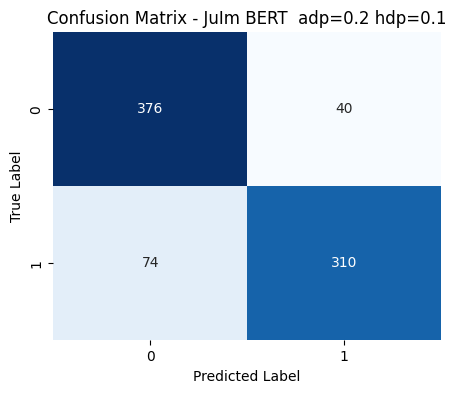


=== Training JuIm BERT with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.557300,0.962051,0.717500,0.755940,0.645756,0.911458
2,0.503500,0.470761,0.773750,0.795941,0.701789,0.919271
3,0.455700,0.421470,0.847500,0.843590,0.830808,0.856771
4,0.412600,0.460874,0.841250,0.839037,0.817284,0.861979
5,0.388000,0.426583,0.858750,0.847503,0.879552,0.817708
6,0.348500,0.437013,0.827500,0.835714,0.769737,0.914062
7,0.340500,0.608812,0.830000,0.837321,0.774336,0.911458
8,0.342500,0.596648,0.835000,0.841346,0.781250,0.911458


=== JuIm BERT  adp=0.2 hdp=0.2 ===
Accuracy: 0.835
Precision: 0.78125
Recall: 0.9114583333333334
F1: 0.8413461538461539
Confusion Matrix:
[[318  98]
 [ 34 350]]



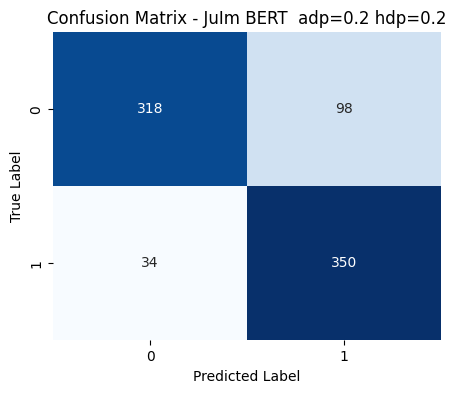


=== Training JuIm BERT with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.577200,0.597243,0.797500,0.806683,0.744493,0.880208
2,0.517100,0.469212,0.806250,0.813926,0.755011,0.882812
3,0.437500,0.475435,0.825000,0.807692,0.854651,0.765625
4,0.407000,0.489200,0.850000,0.844961,0.838462,0.851562
5,0.383200,0.776774,0.776250,0.800890,0.699029,0.937500
6,0.359500,0.523981,0.846250,0.850547,0.797267,0.911458
7,0.358300,0.683619,0.830000,0.835749,0.779279,0.901042
8,0.338500,0.551587,0.835000,0.839416,0.787671,0.898438
9,0.294900,0.650000,0.856250,0.850843,0.847545,0.854167
10,0.307700,0.624141,0.853750,0.847458,0.848564,0.846354


=== JuIm BERT  adp=0.2 hdp=0.3 ===
Accuracy: 0.85
Precision: 0.9049079754601227
Recall: 0.7682291666666666
F1: 0.8309859154929577
Confusion Matrix:
[[385  31]
 [ 89 295]]



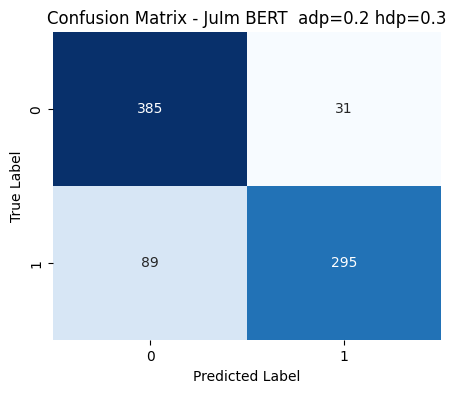


=== Training JuIm BERT with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.584900,0.639665,0.771250,0.785463,0.714286,0.872396
2,0.506500,0.453729,0.808750,0.800000,0.803150,0.796875
3,0.442000,0.493770,0.811250,0.821724,0.751620,0.906250
4,0.398300,0.398986,0.850000,0.843342,0.845550,0.841146
5,0.374700,0.438311,0.833750,0.841099,0.777042,0.916667
6,0.351200,0.429533,0.855000,0.846154,0.862162,0.830729
7,0.363900,0.487779,0.853750,0.852086,0.828010,0.877604
8,0.335000,0.494370,0.857500,0.848404,0.866848,0.830729
9,0.304000,0.532394,0.858750,0.849534,0.869210,0.830729
10,0.290500,0.472170,0.857500,0.849604,0.860963,0.838542


=== JuIm BERT  adp=0.3 hdp=0.1 ===
Accuracy: 0.8575
Precision: 0.8609625668449198
Recall: 0.8385416666666666
F1: 0.8496042216358839
Confusion Matrix:
[[364  52]
 [ 62 322]]



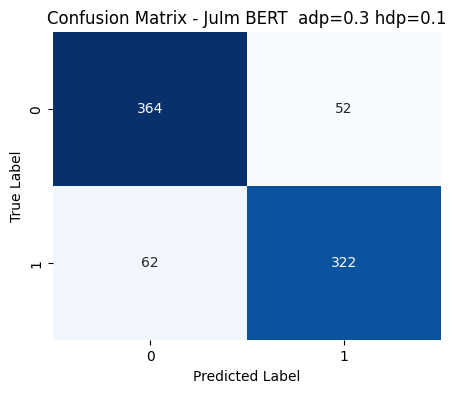


=== Training JuIm BERT with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.585400,0.600896,0.782500,0.771053,0.779255,0.763021
2,0.475500,0.496408,0.773750,0.795941,0.701789,0.919271
3,0.491500,0.581357,0.770000,0.793722,0.696850,0.921875
4,0.423600,0.482042,0.835000,0.820163,0.860000,0.783854
5,0.418900,0.456943,0.840000,0.839196,0.810680,0.869792
6,0.400300,0.435041,0.850000,0.843342,0.845550,0.841146
7,0.379000,0.443861,0.826250,0.833533,0.771619,0.906250
8,0.343300,0.654372,0.825000,0.833729,0.766376,0.914062
9,0.327900,0.572687,0.855000,0.854637,0.823671,0.888021
10,0.328800,0.502904,0.866250,0.861219,0.857881,0.864583


=== JuIm BERT  adp=0.3 hdp=0.2 ===
Accuracy: 0.85875
Precision: 0.8312958435207825
Recall: 0.8854166666666666
F1: 0.8575031525851198
Confusion Matrix:
[[347  69]
 [ 44 340]]



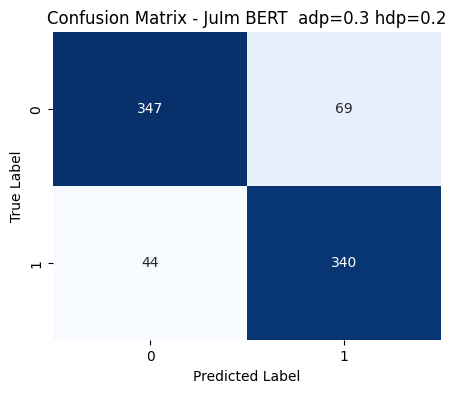


=== Training JuIm BERT with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.587300,0.848048,0.793750,0.796044,0.757647,0.838542
2,0.510000,0.423859,0.843750,0.836601,0.839895,0.833333
3,0.469400,0.660837,0.755000,0.684887,0.894958,0.554688
4,0.434300,0.435757,0.847500,0.842377,0.835897,0.848958
5,0.413800,0.461988,0.850000,0.846939,0.830000,0.864583
6,0.372600,0.505379,0.830000,0.836145,0.778027,0.903646
7,0.387900,0.438768,0.835000,0.836634,0.797170,0.880208
8,0.350100,0.665354,0.836250,0.836454,0.803357,0.872396


=== JuIm BERT  adp=0.3 hdp=0.3 ===
Accuracy: 0.83625
Precision: 0.8033573141486811
Recall: 0.8723958333333334
F1: 0.83645443196005
Confusion Matrix:
[[334  82]
 [ 49 335]]



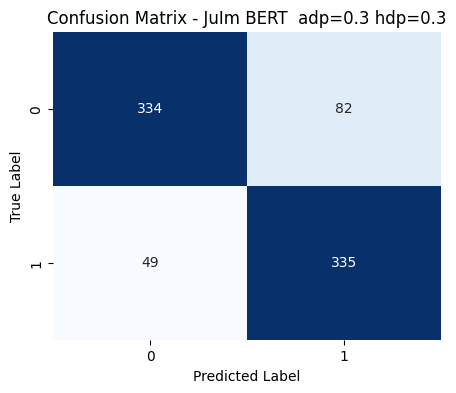

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training JuIm BERT with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
            "JuIm/SMILES_BERT",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"JuIm BERT  adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning JuIm BERT ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning JuIm BERT ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.86000   0.867568   
1                           0.1                  0.2   0.84750   0.810427   
2                           0.1                  0.3   0.85000   0.815789   
3                           0.2                  0.1   0.85750   0.885714   
4                           0.2                  0.2   0.83500   0.781250   
5                           0.2                  0.3   0.85000   0.904908   
6                           0.3                  0.1   0.85750   0.860963   
7                           0.3                  0.2   0.85875   0.831296   
8                           0.3                  0.3   0.83625   0.803357   

     Recall        F1  
0  0.835938  0.851459  
1  0.890625  0.848635  
2  0.888021  0.850374  
3  0.807292  0.844687  
4  0.911458  0.841346  
5  0.768229  0.830986  
6  0.83854

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
7,0.3,0.2,0.85875,0.831296,0.885417,0.857503


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.2)

In [ ]:
df_results.to_csv('Data Hasil/JuIm BERT Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\nJuIm BERT TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("JuIm/SMILES_BERT")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("JuIm/SMILES_BERT", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_JuIm_BERT")
        np.save("Data Hasil/Best_Model_JuIm_BERT/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-07 02:42:48,461] A new study created in memory with name: no-name-93b92b53-5e42-474c-9747-ebecc8a58b1a


Start Hyperparameter Tunning

JuIm BERT TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.536400,0.732250,0.752500,0.772936,0.690574,0.877604
2,0.449700,0.422905,0.821250,0.822360,0.786223,0.861979
3,0.393900,0.455828,0.817500,0.793201,0.869565,0.729167
4,0.360000,0.513527,0.840000,0.842752,0.797674,0.893229
5,0.338600,0.596744,0.813750,0.825322,0.750533,0.916667
6,0.315200,0.489141,0.811250,0.825434,0.742204,0.929688
7,0.309600,0.636986,0.831250,0.835566,0.784897,0.893229



 Nilai Terbaik Baru Ditemukan
Menyimpan Model Baru


...


JuIm BERT TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at JuIm/SMILES_BERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.537300,0.516143,0.772500,0.783333,0.721491,0.856771
2,0.435000,0.520415,0.767500,0.789593,0.698000,0.908854
3,0.388900,0.436811,0.815000,0.822967,0.761062,0.895833
4,0.340000,0.420051,0.851250,0.850314,0.822384,0.880208
5,0.305200,0.535269,0.835000,0.840580,0.783784,0.906250


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.537300,0.516143,0.772500,0.783333,0.721491,0.856771
2,0.435000,0.520415,0.767500,0.789593,0.698000,0.908854
3,0.388900,0.436811,0.815000,0.822967,0.761062,0.895833
4,0.340000,0.420051,0.851250,0.850314,0.822384,0.880208
5,0.305200,0.535269,0.835000,0.840580,0.783784,0.906250
6,0.288200,0.411427,0.843750,0.833997,0.850949,0.817708
7,0.270900,0.555752,0.845000,0.847666,0.802326,0.898438


[I 2026-01-07 04:52:41,109] Trial 17 finished with value: 0.8503144654088051 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 16 with value: 0.8668341708542714.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_JuIm_BERT.csv", index=False)
joblib.dump(study, f"Data Hasil/study_JuIm_BERT.pkl")


=== BEST RESULT ===
Best F1: 0.8668341708542714
Best Params: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}


['Data Hasil/study_JuIm_BERT.pkl']

In [ ]:
data_bert_juim = pd.read_csv("Data Hasil/optuna_results_JuIm_BERT.csv")
data_bert_juim

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.842752,2026-01-07 02:42:48.464168,2026-01-07 02:48:12.032626,0 days 00:05:23.568458,8,0.00002,0.01,0.84000,"[[322, 94], [41, 343]]",0.842752,0.797674,0.893229,"[0.5364, 0.4497, 0.3939, 0.36, 0.3386, 0.3152,...","[0.732250452041626, 0.4229048788547516, 0.4558...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.859355,2026-01-07 02:48:12.033615,2026-01-07 02:57:20.439829,0 days 00:09:08.406214,8,0.00005,0.00,0.86375,"[[368, 48], [64, 320]]",0.859355,0.851662,0.867188,"[0.5746, 0.5018, 0.4481, 0.3943, 0.389, 0.3709...","[0.5420765280723572, 0.4803389012813568, 0.430...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.846452,2026-01-07 02:57:20.442119,2026-01-07 03:02:42.151109,0 days 00:05:21.708990,8,0.00005,0.10,0.85125,"[[299, 117], [38, 346]]",0.846452,0.838875,0.854167,"[0.5972, 0.4857, 0.4628, 0.4038, 0.3901, 0.365...","[0.7361674308776855, 0.4431178569793701, 0.591...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.853503,2026-01-07 03:02:42.152019,2026-01-07 03:10:42.424704,0 days 00:08:00.272685,16,0.00002,0.01,0.85625,"[[365, 51], [63, 321]]",0.853503,0.835411,0.872396,"[0.5449, 0.4169, 0.3649, 0.3413, 0.3032, 0.300...","[0.5148776173591614, 0.4532422721385956, 0.430...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.862500,2026-01-07 03:10:42.425950,2026-01-07 03:18:08.284918,0 days 00:07:25.858968,16,0.00003,0.10,0.86250,"[[343, 73], [47, 337]]",0.862500,0.829327,0.898438,"[0.5373, 0.435, 0.3892, 0.34, 0.3056, 0.2892, ...","[0.5161256194114685, 0.5206073522567749, 0.438...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.852580,2026-01-07 03:18:08.285930,2026-01-07 03:25:00.131008,0 days 00:06:51.845078,8,0.00003,0.01,0.85000,"[[377, 39], [82, 302]]",0.852580,0.806977,0.903646,"[0.5676, 0.4632, 0.3967, 0.3642, 0.3503, 0.354...","[0.7415120601654053, 0.4519088864326477, 0.412...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.856089,2026-01-07 03:25:00.132054,2026-01-07 03:33:21.306369,0 days 00:08:21.174315,8,0.00002,0.10,0.85375,"[[326, 90], [38, 346]]",0.856089,0.811189,0.906250,"[0.5288, 0.4396, 0.3891, 0.3676, 0.3365, 0.326...","[0.5217843055725098, 0.44259917736053467, 0.44...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.856777,2026-01-07 03:33:21.307386,2026-01-07 03:42:00.050773,0 days 00:08:38.743387,16,0.00005,0.01,0.86000,"[[345, 71], [47, 337]]",0.856777,0.841709,0.872396,"[0.5341, 0.4189, 0.3669, 0.3763, 0.3176, 0.306...","[0.5314035415649414, 0.43987366557121277, 0.60...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.857875,2026-01-07 03:42:00.052106,2026-01-07 03:52:37.729405,0 days 00:10:37.677299,16,0.00005,0.10,0.86125,"[[330, 86], [42, 342]]",0.857875,0.843829,0.872396,"[0.5434, 0.4418, 0.3915, 0.3935, 0.323, 0.3238...","[0.48803114891052246, 0.43471747636795044, 0.4...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.838951,2026-01-07 03:52:37.730429,2026-01-07 03:57:20.185924,0 days 00:04:42.455495,16,0.00002,0.00,0.83875,"[[305, 111], [28, 356]]",0.838951,0.805755,0.875000,"[0.5414, 0.4267, 0.3681, 0.3501, 0.3124, 0.307...","[0.5351364016532898, 0.4527492821216583, 0.423...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_bert_juim.sort_values(by='value', ascending=False, inplace=True)
data_bert_juim

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
16,16,0.866834,2026-01-07 04:39:46.349621,2026-01-07 04:47:57.495908,0 days 00:08:11.146287,16,0.00005,0.00,0.86750,"[[384, 32], [89, 295]]",0.866834,0.837379,0.898438,"[0.5233, 0.4428, 0.3827, 0.3851, 0.34, 0.3126,...","[0.5911698937416077, 0.41185352206230164, 0.43...",16,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
13,13,0.862644,2026-01-07 04:20:39.241556,2026-01-07 04:29:03.019576,0 days 00:08:23.778020,8,0.00003,0.00,0.86625,"[[333, 83], [42, 342]]",0.862644,0.850633,0.875000,"[0.5557, 0.4821, 0.4228, 0.3765, 0.3831, 0.341...","[0.7234466075897217, 0.4537779688835144, 0.500...",13,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.862500,2026-01-07 03:10:42.425950,2026-01-07 03:18:08.284918,0 days 00:07:25.858968,16,0.00003,0.10,0.86250,"[[343, 73], [47, 337]]",0.862500,0.829327,0.898438,"[0.5373, 0.435, 0.3892, 0.34, 0.3056, 0.2892, ...","[0.5161256194114685, 0.5206073522567749, 0.438...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.859355,2026-01-07 02:48:12.033615,2026-01-07 02:57:20.439829,0 days 00:09:08.406214,8,0.00005,0.00,0.86375,"[[368, 48], [64, 320]]",0.859355,0.851662,0.867188,"[0.5746, 0.5018, 0.4481, 0.3943, 0.389, 0.3709...","[0.5420765280723572, 0.4803389012813568, 0.430...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.857875,2026-01-07 03:42:00.052106,2026-01-07 03:52:37.729405,0 days 00:10:37.677299,16,0.00005,0.10,0.86125,"[[330, 86], [42, 342]]",0.857875,0.843829,0.872396,"[0.5434, 0.4418, 0.3915, 0.3935, 0.323, 0.3238...","[0.48803114891052246, 0.43471747636795044, 0.4...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
11,11,0.857868,2026-01-07 04:02:40.983414,2026-01-07 04:10:41.015191,0 days 00:08:00.031777,16,0.00003,0.01,0.86000,"[[353, 63], [51, 333]]",0.857868,0.836634,0.880208,"[0.5279, 0.4192, 0.3697, 0.3426, 0.3004, 0.298...","[0.5331102609634399, 0.4314005970954895, 0.441...",11,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
12,12,0.857143,2026-01-07 04:10:41.016221,2026-01-07 04:20:39.240215,0 days 00:09:58.223994,16,0.00002,0.10,0.86125,"[[352, 64], [51, 333]]",0.857143,0.847328,0.867188,"[0.5635, 0.4305, 0.3896, 0.3598, 0.3071, 0.292...","[0.48401176929473877, 0.4930099546909332, 0.46...",12,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.856777,2026-01-07 03:33:21.307386,2026-01-07 03:42:00.050773,0 days 00:08:38.743387,16,0.00005,0.01,0.86000,"[[345, 71], [47, 337]]",0.856777,0.841709,0.872396,"[0.5341, 0.4189, 0.3669, 0.3763, 0.3176, 0.306...","[0.5314035415649414, 0.43987366557121277, 0.60...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.856089,2026-01-07 03:25:00.132054,2026-01-07 03:33:21.306369,0 days 00:08:21.174315,8,0.00002,0.10,0.85375,"[[326, 90], [38, 346]]",0.856089,0.811189,0.906250,"[0.5288, 0.4396, 0.3891, 0.3676, 0.3365, 0.326...","[0.5217843055725098, 0.44259917736053467, 0.44...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
15,15,0.854569,2026-01-07 04:34:25.090718,2026-01-07 04:39:46.348654,0 days 00:05:21.257936,8,0.00003,0.10,0.85875,"[[322, 94], [41, 343]]",0.854569,0.844784,0.864583,"[0.5356, 0.4584, 0.4035, 0.3881, 0.3519, 0.325...","[0.5556899905204773, 0.4442594647407532, 0.448...",15,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


# TRANSFORMERS BERT MODEL 2 ("unikei/bert-base-smiles")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "unikei/bert-base-smiles"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([   2,  129,   23,  116,   23,   27,    7,   34,   23, 3563,   23,   27,
            7,  279,   23,  127,    8,   27,    7,   23,   35,    8,  109,    8,
          369,   23,   27,    7,   27,   23,   27,    7,   27,   23,  164,    8,
         1112,    7,  343,    8,   34,    7,   27,    8,   27,    8,  109,    3,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.489200,0.481251,0.820000,0.806971,0.831492,0.783854
2,0.351100,0.373758,0.845000,0.845387,0.811005,0.882812
3,0.303600,0.485056,0.847500,0.846734,0.817961,0.877604
4,0.259300,0.492269,0.860000,0.853403,0.857895,0.848958
5,0.220500,0.552566,0.860000,0.857506,0.838308,0.877604
6,0.172900,0.510529,0.862500,0.860051,0.840796,0.880208
7,0.137300,0.693680,0.867500,0.867500,0.834135,0.903646
8,0.127600,0.709241,0.855000,0.856079,0.817536,0.898438
9,0.090000,0.855067,0.848750,0.848181,0.818402,0.880208
10,0.070700,0.792216,0.858750,0.852673,0.853786,0.851562


TrainOutput(global_step=2340, training_loss=0.22222788313515165, metrics={'train_runtime': 538.9085, 'train_samples_per_second': 69.251, 'train_steps_per_second': 8.684, 'total_flos': 1035629780558400.0, 'train_loss': 0.22222788313515165, 'epoch': 10.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.83      0.87       416
           1       0.83      0.90      0.87       384

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800


Confusion Matrix:
[[347  69]
 [ 37 347]]


=== unikei BERT Baseline Model ===
Accuracy: 0.8675
Precision: 0.8341346153846154
Recall: 0.9036458333333334
F1: 0.8675
Confusion Matrix:
[[347  69]
 [ 37 347]]



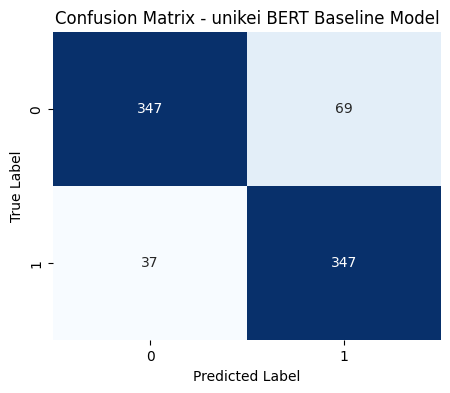

In [ ]:
# Model Evaluate
evaluate_model("unikei BERT Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/unikei BERT_baseline_loss.csv")

Loss history saved to Data Hasil/unikei BERT_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training unikei BERT with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.469700,0.469684,0.810000,0.811881,0.773585,0.854167
2,0.369600,0.557593,0.787500,0.811947,0.705769,0.955729
3,0.288000,0.407244,0.855000,0.848958,0.848958,0.848958
4,0.221800,0.633153,0.856250,0.856429,0.822542,0.893229
5,0.190200,0.675148,0.855000,0.853904,0.826829,0.882812
6,0.152700,0.633858,0.857500,0.849604,0.860963,0.838542
7,0.137100,0.788906,0.861250,0.852980,0.867925,0.838542


=== unikei BERT  adp=0.1 hdp=0.1 ===
Accuracy: 0.86125
Precision: 0.8679245283018868
Recall: 0.8385416666666666
F1: 0.8529801324503311
Confusion Matrix:
[[367  49]
 [ 62 322]]



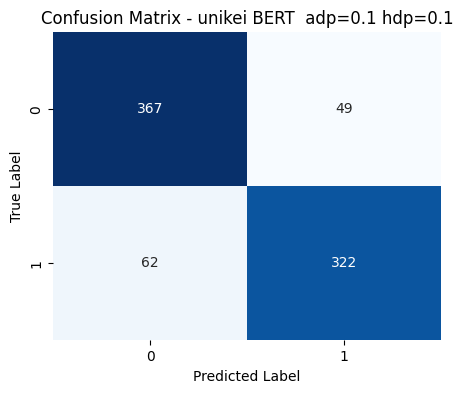


=== Training unikei BERT with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.518000,0.560432,0.806250,0.804046,0.781327,0.828125
2,0.387200,0.509871,0.792500,0.814732,0.712891,0.950521
3,0.304200,0.444999,0.850000,0.847328,0.828358,0.867188
4,0.249900,0.512945,0.867500,0.859788,0.873656,0.846354
5,0.231000,0.540547,0.853750,0.854296,0.818616,0.893229
6,0.182500,0.584035,0.866250,0.863346,0.847118,0.880208
7,0.154900,0.650617,0.868750,0.865212,0.853165,0.877604
8,0.146300,0.751440,0.850000,0.853659,0.802752,0.911458
9,0.104500,0.898700,0.867500,0.865823,0.842365,0.890625
10,0.100600,0.726212,0.873750,0.867280,0.875332,0.859375


=== unikei BERT  adp=0.1 hdp=0.2 ===
Accuracy: 0.86625
Precision: 0.850632911392405
Recall: 0.875
F1: 0.8626444159178434
Confusion Matrix:
[[357  59]
 [ 48 336]]



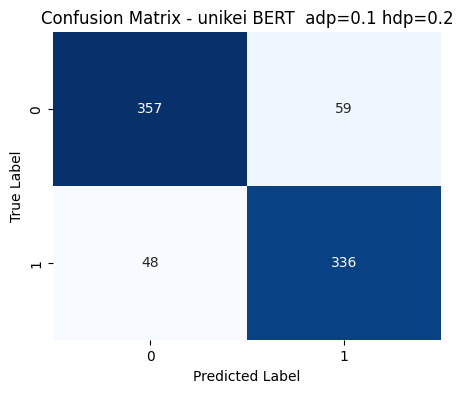


=== Training unikei BERT with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.506700,0.498205,0.810000,0.807107,0.787129,0.828125
2,0.378500,0.418175,0.842500,0.839695,0.820896,0.859375
3,0.322000,0.526511,0.842500,0.827869,0.870690,0.789062
4,0.278900,0.526522,0.856250,0.854246,0.832099,0.877604
5,0.247300,0.595263,0.848750,0.849315,0.813842,0.888021
6,0.219300,0.554287,0.871250,0.865359,0.868766,0.861979
7,0.206300,0.640272,0.863750,0.862200,0.837838,0.888021
8,0.160400,0.701215,0.863750,0.863579,0.831325,0.898438
9,0.153900,0.737520,0.878750,0.876117,0.859649,0.893229
10,0.124400,0.750913,0.868750,0.867925,0.839416,0.898438


=== unikei BERT  adp=0.1 hdp=0.3 ===
Accuracy: 0.86625
Precision: 0.8542199488491049
Recall: 0.8697916666666666
F1: 0.8619354838709677
Confusion Matrix:
[[359  57]
 [ 50 334]]



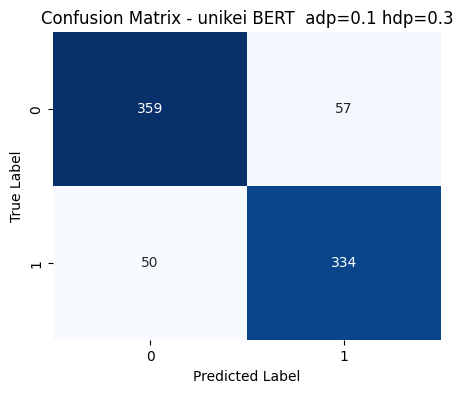


=== Training unikei BERT with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.493900,0.508830,0.815000,0.814070,0.786408,0.843750
2,0.392100,0.622978,0.772500,0.798673,0.694231,0.940104
3,0.320800,0.585580,0.840000,0.821727,0.883234,0.768229
4,0.276300,0.577204,0.856250,0.848085,0.860590,0.835938
5,0.225000,0.616113,0.846250,0.845283,0.817518,0.875000
6,0.201500,0.535465,0.873750,0.865513,0.885559,0.846354
7,0.180900,0.538275,0.892500,0.890863,0.868812,0.914062
8,0.139100,0.643241,0.852500,0.855392,0.807870,0.908854
9,0.112400,0.694202,0.877500,0.873385,0.866667,0.880208
10,0.095500,0.678220,0.868750,0.862385,0.868074,0.856771


=== unikei BERT  adp=0.2 hdp=0.1 ===
Accuracy: 0.86875
Precision: 0.8680738786279684
Recall: 0.8567708333333334
F1: 0.8623853211009175
Confusion Matrix:
[[366  50]
 [ 55 329]]



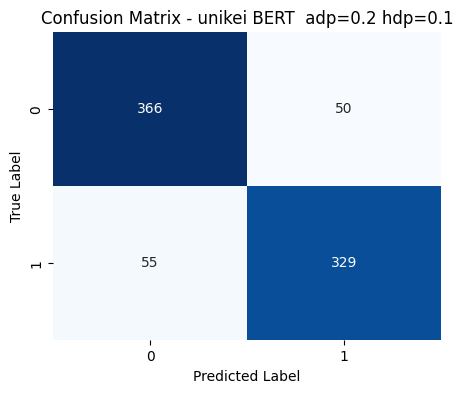


=== Training unikei BERT with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.499500,0.477437,0.823750,0.814717,0.822281,0.807292
2,0.388000,0.501591,0.786250,0.805017,0.716024,0.919271
3,0.313700,0.584075,0.841250,0.831341,0.848238,0.815104
4,0.284300,0.589855,0.848750,0.841830,0.845144,0.838542
5,0.250700,0.607658,0.843750,0.841169,0.821340,0.861979
6,0.207800,0.672118,0.863750,0.854083,0.878788,0.830729
7,0.173400,0.673170,0.868750,0.866920,0.844444,0.890625
8,0.148500,0.725182,0.851250,0.854345,0.806005,0.908854
9,0.131200,0.766934,0.862500,0.861111,0.835784,0.888021
10,0.110100,0.801592,0.862500,0.858247,0.849490,0.867188


=== unikei BERT  adp=0.2 hdp=0.2 ===
Accuracy: 0.8625
Precision: 0.8494897959183674
Recall: 0.8671875
F1: 0.8582474226804123
Confusion Matrix:
[[357  59]
 [ 51 333]]



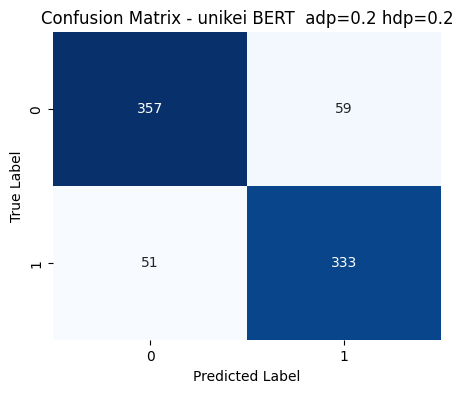


=== Training unikei BERT with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.510900,0.470872,0.817500,0.810881,0.806701,0.815104
2,0.410200,0.408626,0.841250,0.838217,0.820449,0.856771
3,0.335900,0.573483,0.845000,0.827298,0.889222,0.773438
4,0.296800,0.599833,0.843750,0.839538,0.827848,0.851562
5,0.276200,0.591018,0.845000,0.843434,0.818627,0.869792
6,0.249000,0.582535,0.857500,0.852713,0.846154,0.859375
7,0.204600,0.686256,0.851250,0.849558,0.825553,0.875000
8,0.180700,0.731667,0.850000,0.854722,0.798643,0.919271
9,0.168000,0.758144,0.862500,0.862155,0.830918,0.895833
10,0.148200,0.629108,0.885000,0.880208,0.880208,0.880208


=== unikei BERT  adp=0.2 hdp=0.3 ===
Accuracy: 0.8625
Precision: 0.8459595959595959
Recall: 0.8723958333333334
F1: 0.8589743589743589
Confusion Matrix:
[[355  61]
 [ 49 335]]



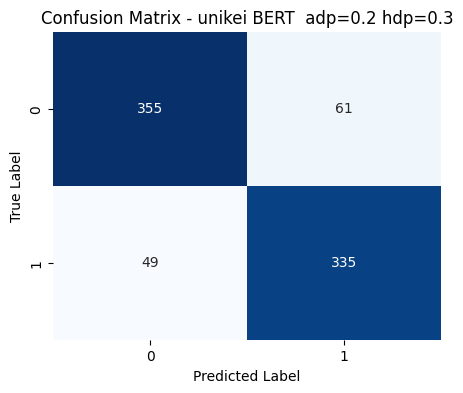


=== Training unikei BERT with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.497300,0.480301,0.793750,0.803337,0.740659,0.877604
2,0.393600,0.468223,0.798750,0.819304,0.719921,0.950521
3,0.315100,0.541179,0.837500,0.819444,0.877976,0.768229
4,0.264100,0.538768,0.863750,0.856011,0.868633,0.843750
5,0.227400,0.550778,0.860000,0.852632,0.861702,0.843750
6,0.191900,0.587061,0.863750,0.853691,0.880886,0.828125
7,0.156700,0.672775,0.880000,0.876923,0.863636,0.890625
8,0.131700,0.602500,0.880000,0.876923,0.863636,0.890625
9,0.118700,0.787526,0.867500,0.868159,0.830952,0.908854
10,0.108400,0.672392,0.880000,0.875325,0.873057,0.877604


=== unikei BERT  adp=0.3 hdp=0.1 ===
Accuracy: 0.88
Precision: 0.8730569948186528
Recall: 0.8776041666666666
F1: 0.8753246753246753
Confusion Matrix:
[[367  49]
 [ 47 337]]



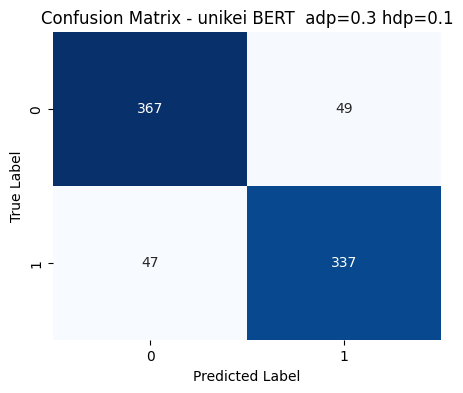


=== Training unikei BERT with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.502300,0.514402,0.808750,0.808989,0.776978,0.843750
2,0.396100,0.403443,0.851250,0.844850,0.845953,0.843750
3,0.344000,0.448795,0.837500,0.834606,0.815920,0.854167
4,0.288700,0.553109,0.850000,0.853659,0.802752,0.911458
5,0.259800,0.566829,0.857500,0.858561,0.819905,0.901042
6,0.216100,0.570715,0.858750,0.851900,0.857520,0.846354
7,0.180200,0.696043,0.871250,0.869455,0.846914,0.893229
8,0.172300,0.679618,0.861250,0.862454,0.822695,0.906250
9,0.152400,0.805611,0.863750,0.862200,0.837838,0.888021
10,0.123100,0.654145,0.878750,0.875481,0.863291,0.888021


=== unikei BERT  adp=0.3 hdp=0.2 ===
Accuracy: 0.85625
Precision: 0.8049886621315193
Recall: 0.9244791666666666
F1: 0.8606060606060606
Confusion Matrix:
[[330  86]
 [ 29 355]]



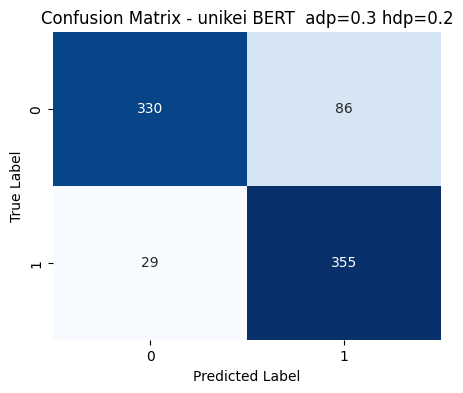


=== Training unikei BERT with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.515900,0.497777,0.803750,0.805933,0.767059,0.848958
2,0.397500,0.407004,0.843750,0.839125,0.829517,0.848958
3,0.353400,0.501265,0.848750,0.839309,0.856369,0.822917
4,0.318400,0.596439,0.857500,0.857500,0.824519,0.893229
5,0.318300,0.588795,0.858750,0.855683,0.839599,0.872396
6,0.260000,0.617698,0.863750,0.858991,0.853470,0.864583
7,0.233500,0.769503,0.867500,0.867500,0.834135,0.903646
8,0.215900,0.925848,0.817500,0.831797,0.745868,0.940104
9,0.181300,0.756580,0.878750,0.875800,0.861461,0.890625
10,0.180300,0.610476,0.876250,0.871595,0.868217,0.875000


=== unikei BERT  adp=0.3 hdp=0.3 ===
Accuracy: 0.87
Precision: 0.8349282296650717
Recall: 0.9088541666666666
F1: 0.8703241895261845
Confusion Matrix:
[[347  69]
 [ 35 349]]



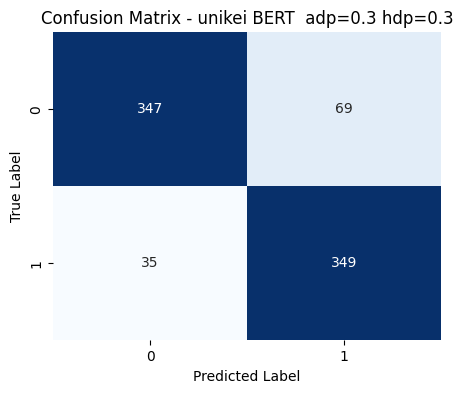

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training unikei BERT with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
            "unikei/bert-base-smiles",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"unikei BERT  adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning unikei BERT ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning unikei BERT ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.86125   0.867925   
1                           0.1                  0.2   0.86625   0.850633   
2                           0.1                  0.3   0.86625   0.854220   
3                           0.2                  0.1   0.86875   0.868074   
4                           0.2                  0.2   0.86250   0.849490   
5                           0.2                  0.3   0.86250   0.845960   
6                           0.3                  0.1   0.88000   0.873057   
7                           0.3                  0.2   0.85625   0.804989   
8                           0.3                  0.3   0.87000   0.834928   

     Recall        F1  
0  0.838542  0.852980  
1  0.875000  0.862644  
2  0.869792  0.861935  
3  0.856771  0.862385  
4  0.867188  0.858247  
5  0.872396  0.858974  
6  0.877

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
6,0.3,0.1,0.88,0.873057,0.877604,0.875325


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.1)

In [ ]:
df_results.to_csv('Data Hasil/unikei BERT Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\nunikei BERT TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("unikei/bert-base-smiles")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("unikei/bert-base-smiles", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_unikei_BERT")
        np.save("Data Hasil/Best_Model_unikei_BERT/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-07 07:30:52,020] A new study created in memory with name: no-name-72b1373d-6f7b-4296-b9f9-f686e52a57ce


Start Hyperparameter Tunning

unikei BERT TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.501300,0.475579,0.806250,0.807931,0.770686,0.848958
2,0.375900,0.447989,0.828750,0.834341,0.778781,0.898438
3,0.305100,0.492854,0.850000,0.842932,0.847368,0.838542
4,0.272800,0.529347,0.857500,0.855330,0.834158,0.877604
5,0.237500,0.583158,0.837500,0.848485,0.767932,0.947917
6,0.205200,0.551286,0.863750,0.857143,0.862797,0.851562
7,0.187600,0.709998,0.863750,0.866258,0.819026,0.919271
8,0.164200,0.782813,0.835000,0.845433,0.768085,0.940104
9,0.158000,0.715732,0.871250,0.872682,0.830588,0.919271
10,0.149200,0.707482,0.866250,0.867410,0.827423,0.911458



 Nilai Terbaik Baru Ditemukan
Menyimpan Model Baru


...

[I 2026-01-07 09:43:08,143] Trial 16 finished with value: 0.8702290076335878 and parameters: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 4 with value: 0.8821292775665399.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unikei/bert-base-smiles and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



unikei BERT TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.538000,0.467169,0.806250,0.792503,0.815427,0.770833
2,0.348800,0.370516,0.846250,0.840052,0.838961,0.841146
3,0.271200,0.378849,0.857500,0.853470,0.842640,0.864583
4,0.216400,0.447313,0.858750,0.852673,0.853786,0.851562
5,0.185300,0.474244,0.856250,0.858896,0.812065,0.911458
6,0.172800,0.467761,0.871250,0.862115,0.887052,0.838542
7,0.134200,0.621532,0.878750,0.875481,0.863291,0.888021
8,0.126500,0.702420,0.856250,0.859927,0.807780,0.919271
9,0.098800,0.760571,0.856250,0.860606,0.804989,0.924479
10,0.090900,0.670617,0.868750,0.868256,0.837772,0.901042


[I 2026-01-07 09:49:44,094] Trial 17 finished with value: 0.8754813863928113 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 4 with value: 0.8821292775665399.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_unikei_BERT.csv", index=False)
joblib.dump(study, f"Data Hasil/study_unikei_BERT.pkl")


=== BEST RESULT ===
Best F1: 0.8821292775665399
Best Params: {'learning_rate': 3e-05, 'weight_decay': 0.1, 'batch_size': 16}


['Data Hasil/study_unikei_BERT.pkl']

In [ ]:
data_bert_unikei = pd.read_csv("Data Hasil/optuna_results_unikei_BERT.csv")
data_bert_unikei

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.872682,2026-01-07 07:30:52.021872,2026-01-07 07:39:46.362888,0 days 00:08:54.341016,8,0.00002,0.01,0.87125,"[[347, 69], [34, 350]]",0.872682,0.830588,0.919271,"[0.5013, 0.3759, 0.3051, 0.2728, 0.2375, 0.205...","[0.4755793511867523, 0.4479886293411255, 0.492...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.864385,2026-01-07 07:39:46.363860,2026-01-07 07:51:35.457131,0 days 00:11:49.093271,8,0.00005,0.00,0.86625,"[[342, 74], [41, 343]]",0.864385,0.841975,0.888021,"[0.5047, 0.3777, 0.3213, 0.2743, 0.2486, 0.212...","[0.5979873538017273, 0.6185168623924255, 0.528...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.858209,2026-01-07 07:51:35.458367,2026-01-07 07:55:21.204136,0 days 00:03:45.745769,8,0.00005,0.10,0.85750,"[[328, 88], [43, 341]]",0.858209,0.821429,0.898438,"[0.4941, 0.3723, 0.3168, 0.2669, 0.2238]","[0.4565902650356293, 0.41565054655075073, 0.45...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.871990,2026-01-07 07:55:21.205134,2026-01-07 08:03:16.739146,0 days 00:07:55.534012,16,0.00002,0.01,0.87375,"[[367, 49], [56, 328]]",0.871990,0.849383,0.895833,"[0.542, 0.3755, 0.3005, 0.2442, 0.2136, 0.1929...","[0.4889586269855499, 0.3904634714126587, 0.406...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.882129,2026-01-07 08:03:16.740064,2026-01-07 08:09:55.873472,0 days 00:06:39.133408,16,0.00003,0.10,0.88375,"[[355, 61], [45, 339]]",0.882129,0.859259,0.906250,"[0.5384, 0.3622, 0.2839, 0.2271, 0.1918, 0.157...","[0.48136886954307556, 0.3853819966316223, 0.37...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.869136,2026-01-07 08:09:55.874433,2026-01-07 08:17:21.755514,0 days 00:07:25.881081,8,0.00003,0.01,0.86750,"[[352, 64], [46, 338]]",0.869136,0.826291,0.916667,"[0.4907, 0.3706, 0.3157, 0.2564, 0.2095, 0.187...","[0.4250096082687378, 0.4023345112800598, 0.466...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.871595,2026-01-07 08:17:21.756556,2026-01-07 08:24:03.286261,0 days 00:06:41.529705,8,0.00002,0.10,0.87625,"[[344, 72], [33, 351]]",0.871595,0.868217,0.875000,"[0.4915, 0.3755, 0.3008, 0.2606, 0.227, 0.1899...","[0.46627482771873474, 0.4168246388435364, 0.47...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.877060,2026-01-07 08:24:03.288688,2026-01-07 08:32:37.925687,0 days 00:08:34.636999,16,0.00005,0.01,0.87875,"[[355, 61], [38, 346]]",0.877060,0.854321,0.901042,"[0.4986, 0.3413, 0.259, 0.2129, 0.1778, 0.1694...","[0.47427231073379517, 0.3801996111869812, 0.36...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.865285,2026-01-07 08:32:37.926695,2026-01-07 08:41:11.372675,0 days 00:08:33.445980,16,0.00005,0.10,0.87000,"[[342, 74], [38, 346]]",0.865285,0.860825,0.869792,"[0.5202, 0.3641, 0.272, 0.2188, 0.188, 0.174, ...","[0.44129395484924316, 0.38548561930656433, 0.4...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.853437,2026-01-07 08:41:11.373767,2026-01-07 08:45:50.977346,0 days 00:04:39.603579,16,0.00002,0.00,0.85875,"[[349, 67], [51, 333]]",0.853437,0.850129,0.856771,"[0.5277, 0.3565, 0.2759, 0.2362, 0.1959, 0.173...","[0.4713227152824402, 0.400660902261734, 0.4237...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_bert_unikei.sort_values(by='value', ascending=False, inplace=True)
data_bert_unikei

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
4,4,0.882129,2026-01-07 08:03:16.740064,2026-01-07 08:09:55.873472,0 days 00:06:39.133408,16,0.00003,0.10,0.88375,"[[355, 61], [45, 339]]",0.882129,0.859259,0.906250,"[0.5384, 0.3622, 0.2839, 0.2271, 0.1918, 0.157...","[0.48136886954307556, 0.3853819966316223, 0.37...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
13,13,0.877238,2026-01-07 09:11:00.721797,2026-01-07 09:20:35.550445,0 days 00:09:34.828648,8,0.00003,0.00,0.88000,"[[352, 64], [42, 342]]",0.877238,0.861809,0.893229,"[0.5012, 0.3716, 0.2897, 0.2671, 0.2207, 0.196...","[0.4822133183479309, 0.4763048589229584, 0.508...",13,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.877060,2026-01-07 08:24:03.288688,2026-01-07 08:32:37.925687,0 days 00:08:34.636999,16,0.00005,0.01,0.87875,"[[355, 61], [38, 346]]",0.877060,0.854321,0.901042,"[0.4986, 0.3413, 0.259, 0.2129, 0.1778, 0.1694...","[0.47427231073379517, 0.3801996111869812, 0.36...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
17,17,0.875481,2026-01-07 09:43:08.143817,2026-01-07 09:49:44.094456,0 days 00:06:35.950639,16,0.00003,0.00,0.87875,"[[349, 67], [38, 346]]",0.875481,0.863291,0.888021,"[0.538, 0.3488, 0.2712, 0.2164, 0.1853, 0.1728...","[0.46716925501823425, 0.3705160617828369, 0.37...",17,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
0,0,0.872682,2026-01-07 07:30:52.021872,2026-01-07 07:39:46.362888,0 days 00:08:54.341016,8,0.00002,0.01,0.87125,"[[347, 69], [34, 350]]",0.872682,0.830588,0.919271,"[0.5013, 0.3759, 0.3051, 0.2728, 0.2375, 0.205...","[0.4755793511867523, 0.4479886293411255, 0.492...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.871990,2026-01-07 07:55:21.205134,2026-01-07 08:03:16.739146,0 days 00:07:55.534012,16,0.00002,0.01,0.87375,"[[367, 49], [56, 328]]",0.871990,0.849383,0.895833,"[0.542, 0.3755, 0.3005, 0.2442, 0.2136, 0.1929...","[0.4889586269855499, 0.3904634714126587, 0.406...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.871595,2026-01-07 08:17:21.756556,2026-01-07 08:24:03.286261,0 days 00:06:41.529705,8,0.00002,0.10,0.87625,"[[344, 72], [33, 351]]",0.871595,0.868217,0.875000,"[0.4915, 0.3755, 0.3008, 0.2606, 0.227, 0.1899...","[0.46627482771873474, 0.4168246388435364, 0.47...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
16,16,0.870229,2026-01-07 09:33:55.610337,2026-01-07 09:43:08.143091,0 days 00:09:12.532754,16,0.00005,0.00,0.87250,"[[357, 59], [43, 341]]",0.870229,0.850746,0.890625,"[0.4988, 0.3401, 0.2511, 0.2185, 0.1986, 0.164...","[0.4721454977989197, 0.36764541268348694, 0.37...",16,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
14,14,0.869240,2026-01-07 09:20:35.551224,2026-01-07 09:27:15.417848,0 days 00:06:39.866624,8,0.00002,0.00,0.86875,"[[333, 83], [30, 354]]",0.869240,0.832936,0.908854,"[0.4924, 0.358, 0.3036, 0.2573, 0.2137, 0.1865...","[0.4468524158000946, 0.4411434829235077, 0.531...",14,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
12,12,0.869231,2026-01-07 08:59:50.650112,2026-01-07 09:11:00.721112,0 days 00:11:10.071000,16,0.00002,0.10,0.87250,"[[351, 65], [39, 345]]",0.869231,0.856061,0.882812,"[0.518, 0.3615, 0.2754, 0.2326, 0.2028, 0.1916...","[0.4804591238498688, 0.4113210439682007, 0.429...",12,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


# TRANSFORMERS ChemBERTa MODEL 1 ("seyonec/ChemBERTa-zinc-base-v1")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([  0, 262,  21,  33, 286,  33,  39,  12,  50,  33,  39,  21, 268,  22,
          33,  39,  12, 348,  33,  39,  22,  13,  39, 263,  51,  13, 279,  13,
         268,  23,  33,  39,  12,  39,  33,  39,  12,  39,  33,  39,  23,  13,
          50,  24, 271,  12, 262,  24,  13,  50,  12,  39,  13,  39,  13, 279,
           2,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.476400,0.491014,0.817500,0.815190,0.793103,0.838542
2,0.343900,0.396532,0.847500,0.845960,0.821078,0.872396
3,0.287500,0.468949,0.840000,0.826087,0.863636,0.791667
4,0.214000,0.566420,0.855000,0.851662,0.836683,0.867188
5,0.178100,0.784825,0.822500,0.830952,0.765351,0.908854
6,0.181200,0.665820,0.835000,0.830334,0.819797,0.841146
7,0.117800,0.745435,0.850000,0.852217,0.808411,0.901042
8,0.110000,0.783843,0.856250,0.856787,0.821002,0.895833
9,0.090200,0.777150,0.857500,0.857500,0.824519,0.893229
10,0.074300,0.832163,0.847500,0.847880,0.813397,0.885417


TrainOutput(global_step=2808, training_loss=0.1836785013519461, metrics={'train_runtime': 313.306, 'train_samples_per_second': 119.117, 'train_steps_per_second': 14.937, 'total_flos': 625684919914368.0, 'train_loss': 0.1836785013519461, 'epoch': 12.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.86       416
           1       0.82      0.89      0.86       384

    accuracy                           0.86       800
   macro avg       0.86      0.86      0.86       800
weighted avg       0.86      0.86      0.86       800


Confusion Matrix:
[[343  73]
 [ 41 343]]


=== Seyonec ChemBERTa Baseline Model ===
Accuracy: 0.8575
Precision: 0.8245192307692307
Recall: 0.8932291666666666
F1: 0.8575
Confusion Matrix:
[[343  73]
 [ 41 343]]



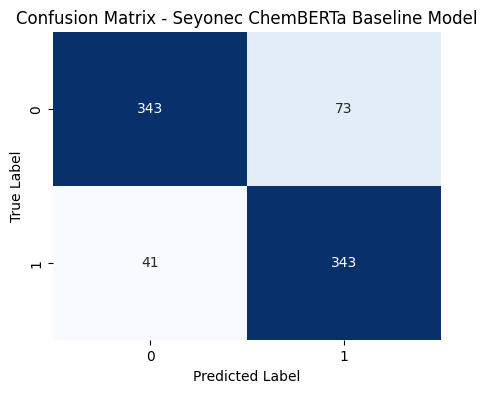

In [ ]:
# Model Evaluate
evaluate_model("Seyonec ChemBERTa Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/Seyonec ChemBERTa_baseline_loss.csv")

Loss history saved to Data Hasil/Seyonec ChemBERTa_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training ChemBERTa with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.465600,0.425835,0.827500,0.820312,0.820312,0.820312
2,0.354000,0.376272,0.842500,0.843284,0.807143,0.882812
3,0.279700,0.519237,0.828750,0.802309,0.899676,0.723958
4,0.220100,0.560513,0.850000,0.849624,0.818841,0.882812
5,0.175400,0.628098,0.868750,0.868586,0.836145,0.903646
6,0.166300,0.555857,0.877500,0.873711,0.864796,0.882812
7,0.124000,0.604147,0.877500,0.873057,0.868557,0.877604
8,0.114200,0.649687,0.873750,0.874845,0.834515,0.919271
9,0.091600,0.674813,0.872500,0.868557,0.859694,0.877604
10,0.069900,0.750709,0.876250,0.869908,0.877984,0.861979


=== ChemBERTa  adp=0.1 hdp=0.1 ===
Accuracy: 0.87125
Precision: 0.8452088452088452
Recall: 0.8958333333333334
F1: 0.8697850821744627
Confusion Matrix:
[[353  63]
 [ 40 344]]



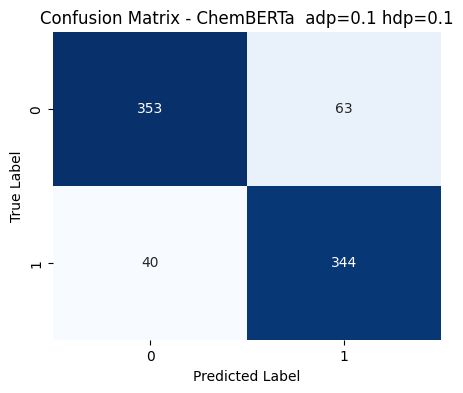


=== Training ChemBERTa with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.497600,0.443266,0.827500,0.827930,0.794258,0.864583
2,0.372000,0.408634,0.832500,0.836983,0.785388,0.895833
3,0.303200,0.464082,0.857500,0.844687,0.885714,0.807292
4,0.252200,0.593126,0.850000,0.849624,0.818841,0.882812
5,0.219100,0.738834,0.847500,0.852657,0.795045,0.919271
6,0.189100,0.667413,0.861250,0.852590,0.869919,0.835938
7,0.145200,0.658501,0.868750,0.864865,0.854962,0.875000
8,0.139500,0.861974,0.845000,0.848411,0.799539,0.903646
9,0.124000,0.740110,0.871250,0.868118,0.853904,0.882812
10,0.104300,0.770890,0.870000,0.867008,0.851759,0.882812


=== ChemBERTa  adp=0.1 hdp=0.2 ===
Accuracy: 0.875
Precision: 0.8480392156862745
Recall: 0.9010416666666666
F1: 0.8737373737373737
Confusion Matrix:
[[354  62]
 [ 38 346]]



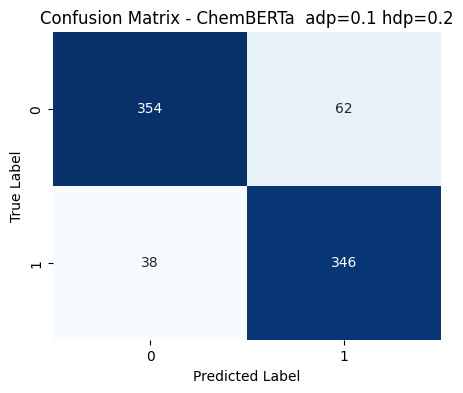


=== Training ChemBERTa with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.487900,0.653623,0.770000,0.790433,0.702429,0.903646
2,0.391300,0.422805,0.836250,0.840438,0.789474,0.898438
3,0.336800,0.493463,0.848750,0.847799,0.819951,0.877604
4,0.269400,0.605974,0.856250,0.855709,0.825666,0.888021
5,0.265900,0.683612,0.827500,0.834928,0.772124,0.908854
6,0.218100,0.768425,0.850000,0.846939,0.830000,0.864583
7,0.196700,0.698124,0.863750,0.864596,0.826603,0.906250
8,0.165400,0.792772,0.847500,0.852657,0.795045,0.919271
9,0.140100,0.795962,0.862500,0.863524,0.824645,0.906250
10,0.143600,0.758948,0.873750,0.869677,0.861893,0.877604


=== ChemBERTa  adp=0.1 hdp=0.3 ===
Accuracy: 0.8575
Precision: 0.8110599078341014
Recall: 0.9166666666666666
F1: 0.8606356968215159
Confusion Matrix:
[[334  82]
 [ 32 352]]



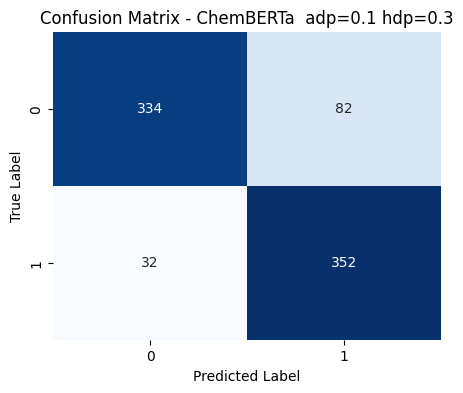


=== Training ChemBERTa with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.491600,0.568884,0.788750,0.798570,0.736264,0.872396
2,0.368900,0.386109,0.850000,0.850374,0.815789,0.888021
3,0.309100,0.412855,0.853750,0.844208,0.863760,0.825521
4,0.241900,0.540910,0.852500,0.849105,0.834171,0.864583
5,0.206700,0.697415,0.832500,0.841608,0.770563,0.927083


=== ChemBERTa  adp=0.2 hdp=0.1 ===
Accuracy: 0.8325
Precision: 0.7705627705627706
Recall: 0.9270833333333334
F1: 0.8416075650118203
Confusion Matrix:
[[310 106]
 [ 28 356]]



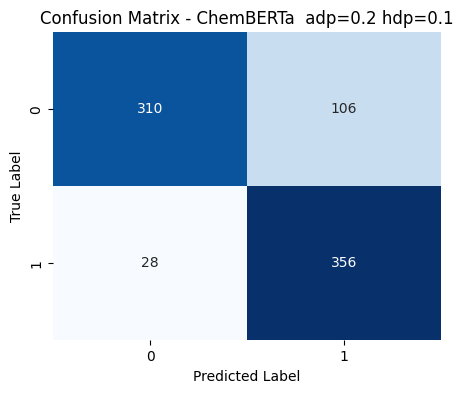


=== Training ChemBERTa with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.498300,0.547541,0.808750,0.812729,0.766744,0.864583
2,0.396500,0.497998,0.790000,0.807339,0.721311,0.916667
3,0.342000,0.512318,0.850000,0.840426,0.858696,0.822917
4,0.288700,0.578535,0.841250,0.843016,0.802353,0.888021
5,0.246400,0.713156,0.835000,0.843230,0.775109,0.924479
6,0.232400,0.692236,0.847500,0.845178,0.824257,0.867188
7,0.183100,0.736672,0.862500,0.858974,0.845960,0.872396
8,0.167400,0.749298,0.846250,0.847205,0.809976,0.888021
9,0.127400,0.785560,0.860000,0.857868,0.836634,0.880208
10,0.129000,0.768851,0.860000,0.859649,0.828502,0.893229


=== ChemBERTa  adp=0.2 hdp=0.2 ===
Accuracy: 0.855
Precision: 0.8205741626794258
Recall: 0.8932291666666666
F1: 0.8553615960099751
Confusion Matrix:
[[341  75]
 [ 41 343]]



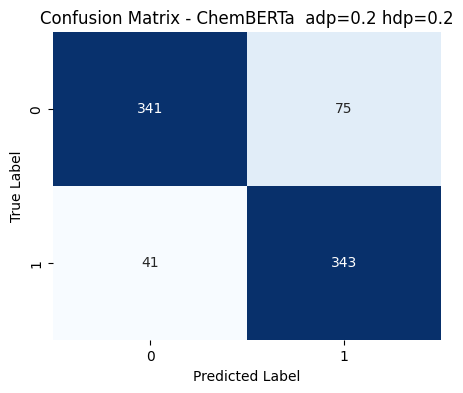


=== Training ChemBERTa with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.517600,0.572882,0.761250,0.784181,0.692615,0.903646
2,0.395500,0.445278,0.825000,0.828431,0.782407,0.880208
3,0.346500,0.462209,0.843750,0.836173,0.841689,0.830729
4,0.308000,0.719512,0.818750,0.831199,0.751579,0.929688
5,0.286700,0.926883,0.782500,0.807947,0.701149,0.953125
6,0.249200,0.569647,0.860000,0.859649,0.828502,0.893229
7,0.203900,0.884395,0.830000,0.841860,0.760504,0.942708
8,0.217300,0.785442,0.843750,0.847375,0.797701,0.903646
9,0.169700,0.880446,0.845000,0.848780,0.798165,0.906250


=== ChemBERTa  adp=0.2 hdp=0.3 ===
Accuracy: 0.845
Precision: 0.7981651376146789
Recall: 0.90625
F1: 0.848780487804878
Confusion Matrix:
[[328  88]
 [ 36 348]]



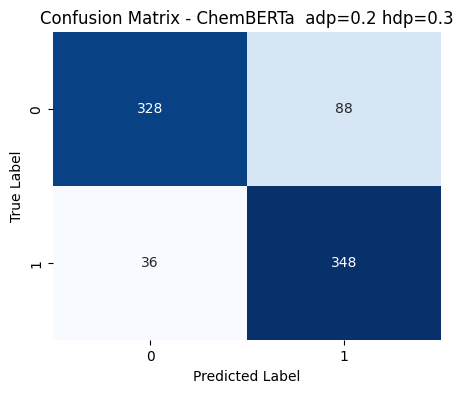


=== Training ChemBERTa with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.497200,0.454019,0.808750,0.810409,0.773050,0.851562
2,0.383400,0.499482,0.817500,0.827014,0.758696,0.908854
3,0.309200,0.425076,0.845000,0.838120,0.840314,0.835938
4,0.272000,0.546198,0.858750,0.856051,0.837905,0.875000
5,0.250400,0.679929,0.850000,0.854015,0.801370,0.914062
6,0.230000,0.663578,0.847500,0.846348,0.819512,0.875000
7,0.203900,0.711325,0.857500,0.860976,0.809633,0.919271
8,0.186500,0.757742,0.856250,0.859585,0.809195,0.916667
9,0.136600,0.711535,0.875000,0.870466,0.865979,0.875000
10,0.131700,0.698387,0.872500,0.869231,0.856061,0.882812


=== ChemBERTa  adp=0.3 hdp=0.1 ===
Accuracy: 0.8725
Precision: 0.849009900990099
Recall: 0.8932291666666666
F1: 0.8705583756345178
Confusion Matrix:
[[355  61]
 [ 41 343]]



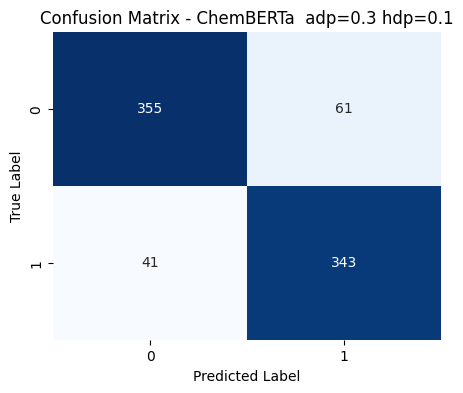


=== Training ChemBERTa with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.507000,0.542078,0.792500,0.806527,0.729958,0.901042
2,0.403200,0.434999,0.813750,0.823250,0.755991,0.903646
3,0.355400,0.441347,0.861250,0.852980,0.867925,0.838542
4,0.312100,0.583518,0.835000,0.842105,0.778761,0.916667
5,0.276000,0.568280,0.841250,0.847539,0.786192,0.919271
6,0.251200,0.631393,0.841250,0.842236,0.805226,0.882812


=== ChemBERTa  adp=0.3 hdp=0.2 ===
Accuracy: 0.84125
Precision: 0.8052256532066508
Recall: 0.8828125
F1: 0.8422360248447205
Confusion Matrix:
[[334  82]
 [ 45 339]]



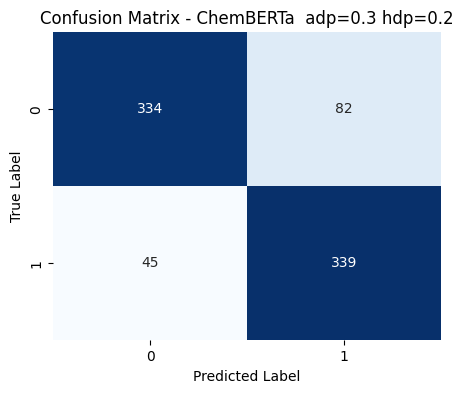


=== Training ChemBERTa with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.524100,0.552286,0.785000,0.794749,0.733480,0.867188
2,0.395600,0.409734,0.837500,0.841463,0.791284,0.898438
3,0.356400,0.452161,0.851250,0.850690,0.820823,0.882812
4,0.312000,0.515602,0.861250,0.864799,0.812357,0.924479
5,0.292800,0.817832,0.811250,0.828214,0.735354,0.947917
6,0.279600,0.509458,0.860000,0.859296,0.830097,0.890625
7,0.243900,0.878351,0.828750,0.841618,0.756757,0.947917


=== ChemBERTa  adp=0.3 hdp=0.3 ===
Accuracy: 0.82875
Precision: 0.7567567567567568
Recall: 0.9479166666666666
F1: 0.8416184971098266
Confusion Matrix:
[[299 117]
 [ 20 364]]



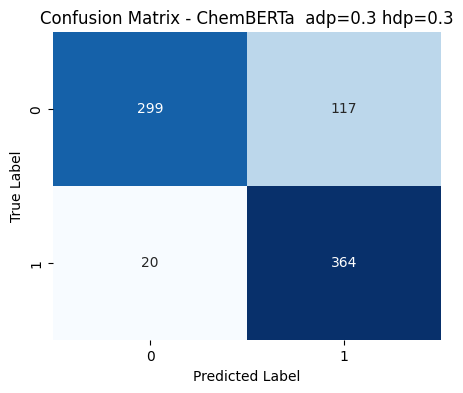

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training ChemBERTa with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
            "seyonec/ChemBERTa-zinc-base-v1",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"ChemBERTa  adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning Seyonec ChemBerta ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning Seyonec ChemBerta ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.87125   0.845209   
1                           0.1                  0.2   0.87500   0.848039   
2                           0.1                  0.3   0.85750   0.811060   
3                           0.2                  0.1   0.83250   0.770563   
4                           0.2                  0.2   0.85500   0.820574   
5                           0.2                  0.3   0.84500   0.798165   
6                           0.3                  0.1   0.87250   0.849010   
7                           0.3                  0.2   0.84125   0.805226   
8                           0.3                  0.3   0.82875   0.756757   

     Recall        F1  
0  0.895833  0.869785  
1  0.901042  0.873737  
2  0.916667  0.860636  
3  0.927083  0.841608  
4  0.893229  0.855362  
5  0.906250  0.848780  
6 

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
1,0.1,0.2,0.875,0.848039,0.901042,0.873737


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.2)

In [ ]:
df_results.to_csv('Data Hasil/Seyonec ChemBERTa Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\nSeyonec ChemBERTa TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("seyonec/ChemBERTa-zinc-base-v1", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_Seyonec_Chemberta")
        np.save("Data Hasil/Best_Model_Seyonec_Chemberta/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-08 17:18:05,849] A new study created in memory with name: no-name-6e89ce9f-9dc5-49ec-80c8-478d04adf481


Start Hyperparameter Tunning

Seyonec ChemBERTa TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.500800,0.494299,0.803750,0.804483,0.770883,0.841146
2,0.373400,0.475955,0.806250,0.816133,0.749455,0.895833
3,0.328600,0.491578,0.836250,0.837670,0.799054,0.880208
4,0.260400,0.618514,0.841250,0.844172,0.798144,0.895833
5,0.244700,0.675778,0.832500,0.838942,0.779018,0.908854
6,0.225300,0.574648,0.853750,0.845850,0.856000,0.835938
7,0.175100,0.665973,0.856250,0.854981,0.828851,0.882812
8,0.174300,0.774035,0.846250,0.850547,0.797267,0.911458
9,0.155100,0.724915,0.862500,0.859694,0.842500,0.877604
10,0.148300,0.756278,0.861250,0.859671,0.835381,0.885417



 Nilai Terbaik Baru Ditemukan
Menyimpan Model Baru


...

[I 2026-01-08 18:36:47,298] Trial 16 finished with value: 0.8621118012422361 and parameters: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 2 with value: 0.8837803320561941.



Seyonec ChemBERTa TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.517800,0.434037,0.827500,0.814516,0.841667,0.789062
2,0.353100,0.384868,0.841250,0.843016,0.802353,0.888021
3,0.267700,0.392138,0.846250,0.846442,0.812950,0.882812
4,0.219400,0.436550,0.842500,0.843284,0.807143,0.882812
5,0.197400,0.623918,0.828750,0.839766,0.762208,0.934896
6,0.184600,0.495790,0.857500,0.852713,0.846154,0.859375
7,0.139600,0.518561,0.861250,0.858599,0.840399,0.877604
8,0.120500,0.679772,0.848750,0.853688,0.796840,0.919271
9,0.121800,0.634886,0.846250,0.846442,0.812950,0.882812
10,0.111100,0.657904,0.862500,0.860406,0.839109,0.882812


[I 2026-01-08 18:41:21,531] Trial 17 finished with value: 0.8672566371681416 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 2 with value: 0.8837803320561941.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_seyonec_chemberta.csv", index=False)
joblib.dump(study, f"Data Hasil/study_seyonec_chemberta.pkl")


=== BEST RESULT ===
Best F1: 0.8837803320561941
Best Params: {'learning_rate': 5e-05, 'weight_decay': 0.1, 'batch_size': 8}


['Data Hasil/study_seyonec_chemberta.pkl']

In [ ]:
data_chemberta_seyonec = pd.read_csv("Data Hasil/optuna_results_seyonec_chemberta.csv")
data_chemberta_seyonec

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.864728,2026-01-08 17:18:05.850683,2026-01-08 17:24:51.006153,0 days 00:06:45.155470,8,0.00002,0.01,0.86625,"[[339, 77], [39, 345]]",0.864728,0.840295,0.890625,"[0.5008, 0.3734, 0.3286, 0.2604, 0.2447, 0.225...","[0.49429869651794434, 0.4759550094604492, 0.49...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.868159,2026-01-08 17:24:51.007350,2026-01-08 17:28:52.365545,0 days 00:04:01.358195,8,0.00005,0.00,0.86750,"[[343, 73], [40, 344]]",0.868159,0.830952,0.908854,"[0.4859, 0.3516, 0.3169, 0.241, 0.1953, 0.1917...","[0.45015454292297363, 0.43449077010154724, 0.4...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.883780,2026-01-08 17:28:52.366377,2026-01-08 17:35:01.791252,0 days 00:06:09.424875,8,0.00005,0.10,0.88625,"[[340, 76], [36, 348]]",0.883780,0.867168,0.901042,"[0.4977, 0.3714, 0.3057, 0.2614, 0.1974, 0.181...","[0.4433443546295166, 0.40494582056999207, 0.59...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.864532,2026-01-08 17:35:01.792052,2026-01-08 17:38:18.989123,0 days 00:03:17.197071,16,0.00002,0.01,0.86250,"[[353, 63], [44, 340]]",0.864532,0.820093,0.914062,"[0.5127, 0.3729, 0.2952, 0.256, 0.2207, 0.1855...","[0.43788233399391174, 0.3942999243736267, 0.42...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.868020,2026-01-08 17:38:18.989763,2026-01-08 17:42:53.465543,0 days 00:04:34.475780,16,0.00003,0.10,0.87000,"[[341, 75], [38, 346]]",0.868020,0.846535,0.890625,"[0.5178, 0.3532, 0.2679, 0.2196, 0.1974, 0.184...","[0.4340541958808899, 0.3849250078201294, 0.391...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.865557,2026-01-08 17:42:53.466219,2026-01-08 17:46:10.483469,0 days 00:03:17.017250,8,0.00003,0.01,0.86875,"[[353, 63], [43, 341]]",0.865557,0.851385,0.880208,"[0.4944, 0.3626, 0.291, 0.2406, 0.2156, 0.195,...","[0.5265480279922485, 0.48094499111175537, 0.46...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.868687,2026-01-08 17:46:10.484276,2026-01-08 17:50:53.176354,0 days 00:04:42.692078,8,0.00002,0.10,0.87000,"[[340, 76], [34, 350]]",0.868687,0.843137,0.895833,"[0.4982, 0.3763, 0.3168, 0.2566, 0.2348, 0.215...","[0.47197234630584717, 0.45988112688064575, 0.5...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.870466,2026-01-08 17:50:53.177065,2026-01-08 17:55:08.000383,0 days 00:04:14.823318,16,0.00005,0.01,0.87500,"[[345, 71], [37, 347]]",0.870466,0.865979,0.875000,"[0.5134, 0.3408, 0.267, 0.2233, 0.1984, 0.1712...","[0.4382033944129944, 0.39708682894706726, 0.41...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.866005,2026-01-08 17:55:08.001399,2026-01-08 17:58:44.476706,0 days 00:03:36.475307,16,0.00005,0.10,0.86500,"[[348, 68], [42, 342]]",0.866005,0.827014,0.908854,"[0.5134, 0.3409, 0.2669, 0.2231, 0.198, 0.1694...","[0.43823927640914917, 0.3972034454345703, 0.41...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.868256,2026-01-08 17:58:44.477366,2026-01-08 18:05:14.743476,0 days 00:06:30.266110,16,0.00002,0.00,0.86875,"[[345, 71], [35, 349]]",0.868256,0.837772,0.901042,"[0.5118, 0.3657, 0.2853, 0.2549, 0.2072, 0.206...","[0.4504129886627197, 0.4338255226612091, 0.453...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_chemberta_seyonec.sort_values(by='value', ascending=False, inplace=True)
data_chemberta_seyonec

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
2,2,0.883780,2026-01-08 17:28:52.366377,2026-01-08 17:35:01.791252,0 days 00:06:09.424875,8,0.00005,0.10,0.88625,"[[340, 76], [36, 348]]",0.883780,0.867168,0.901042,"[0.4977, 0.3714, 0.3057, 0.2614, 0.1974, 0.181...","[0.4433443546295166, 0.40494582056999207, 0.59...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
11,11,0.876289,2026-01-08 18:09:14.279284,2026-01-08 18:13:48.317810,0 days 00:04:34.038526,16,0.00003,0.01,0.88000,"[[353, 63], [41, 343]]",0.876289,0.867347,0.885417,"[0.5005, 0.3459, 0.2735, 0.2247, 0.1855, 0.190...","[0.45725691318511963, 0.40037667751312256, 0.4...",11,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
12,12,0.875784,2026-01-08 18:13:48.318534,2026-01-08 18:19:00.951177,0 days 00:05:12.632643,16,0.00002,0.10,0.87625,"[[348, 68], [35, 349]]",0.875784,0.845036,0.908854,"[0.5202, 0.3784, 0.2997, 0.2602, 0.2244, 0.206...","[0.45427176356315613, 0.4059813618659973, 0.43...",12,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
10,10,0.873057,2026-01-08 18:05:14.744148,2026-01-08 18:09:14.278633,0 days 00:03:59.534485,8,0.00005,0.01,0.87750,"[[355, 61], [43, 341]]",0.873057,0.868557,0.877604,"[0.4816, 0.382, 0.3037, 0.2456, 0.2066, 0.2014...","[0.5456404685974121, 0.4285152852535248, 0.415...",10,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
15,15,0.870801,2026-01-08 18:28:04.706059,2026-01-08 18:33:30.624326,0 days 00:05:25.918267,8,0.00003,0.10,0.87500,"[[346, 70], [39, 345]]",0.870801,0.864103,0.877604,"[0.484, 0.3578, 0.3153, 0.2514, 0.2075, 0.1876...","[0.4540875256061554, 0.4433618187904358, 0.502...",15,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.870466,2026-01-08 17:50:53.177065,2026-01-08 17:55:08.000383,0 days 00:04:14.823318,16,0.00005,0.01,0.87500,"[[345, 71], [37, 347]]",0.870466,0.865979,0.875000,"[0.5134, 0.3408, 0.267, 0.2233, 0.1984, 0.1712...","[0.4382033944129944, 0.39708682894706726, 0.41...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.868687,2026-01-08 17:46:10.484276,2026-01-08 17:50:53.176354,0 days 00:04:42.692078,8,0.00002,0.10,0.87000,"[[340, 76], [34, 350]]",0.868687,0.843137,0.895833,"[0.4982, 0.3763, 0.3168, 0.2566, 0.2348, 0.215...","[0.47197234630584717, 0.45988112688064575, 0.5...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.868256,2026-01-08 17:58:44.477366,2026-01-08 18:05:14.743476,0 days 00:06:30.266110,16,0.00002,0.00,0.86875,"[[345, 71], [35, 349]]",0.868256,0.837772,0.901042,"[0.5118, 0.3657, 0.2853, 0.2549, 0.2072, 0.206...","[0.4504129886627197, 0.4338255226612091, 0.453...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.868159,2026-01-08 17:24:51.007350,2026-01-08 17:28:52.365545,0 days 00:04:01.358195,8,0.00005,0.00,0.86750,"[[343, 73], [40, 344]]",0.868159,0.830952,0.908854,"[0.4859, 0.3516, 0.3169, 0.241, 0.1953, 0.1917...","[0.45015454292297363, 0.43449077010154724, 0.4...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.868020,2026-01-08 17:38:18.989763,2026-01-08 17:42:53.465543,0 days 00:04:34.475780,16,0.00003,0.10,0.87000,"[[341, 75], [38, 346]]",0.868020,0.846535,0.890625,"[0.5178, 0.3532, 0.2679, 0.2196, 0.1974, 0.184...","[0.4340541958808899, 0.3849250078201294, 0.391...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


# TRANSFORMERS ChemBERTa MODEL 2 ("DeepChem/ChemBERTa-77M-MLM")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "DeepChem/ChemBERTa-77M-MLM"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([12, 16, 16, 20, 22, 16, 23, 22, 16, 17, 23, 22, 16, 20, 23, 16, 21, 22,
         16, 17, 34, 16, 22, 16, 21, 18, 16, 17, 22, 19, 18, 19, 16, 18, 23, 16,
         26, 22, 16, 17, 16, 22, 16, 17, 16, 22, 16, 26, 18, 23, 32, 16, 16, 16,
         17, 16, 16, 32, 18, 23, 17, 16, 18, 16, 18, 19, 16, 13,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 592, 'bos_token_id': 591, 'pad_token_id': 0}.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.606800,0.514351,0.760000,0.761787,0.727488,0.799479
2,0.445200,0.475104,0.787500,0.793187,0.744292,0.848958
3,0.390700,0.478291,0.800000,0.809976,0.744541,0.888021
4,0.344800,0.457585,0.820000,0.821340,0.784360,0.861979
5,0.324800,0.452783,0.826250,0.829865,0.782910,0.882812
6,0.298500,0.425839,0.836250,0.833545,0.813896,0.854167
7,0.278700,0.462983,0.840000,0.844660,0.790909,0.906250
8,0.255700,0.483030,0.842500,0.847458,0.791855,0.911458
9,0.254100,0.474402,0.846250,0.849449,0.801386,0.903646
10,0.237900,0.486444,0.846250,0.850183,0.798627,0.908854


TrainOutput(global_step=3510, training_loss=0.3025691833930817, metrics={'train_runtime': 121.0782, 'train_samples_per_second': 308.23, 'train_steps_per_second': 38.653, 'total_flos': 54406502068320.0, 'train_loss': 0.3025691833930817, 'epoch': 15.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       416
           1       0.83      0.90      0.86       384

    accuracy                           0.86       800
   macro avg       0.86      0.86      0.86       800
weighted avg       0.86      0.86      0.86       800


Confusion Matrix:
[[345  71]
 [ 40 344]]


=== DeepChem ChemBERTa Baseline Model ===
Accuracy: 0.86125
Precision: 0.8289156626506025
Recall: 0.8958333333333334
F1: 0.8610763454317898
Confusion Matrix:
[[345  71]
 [ 40 344]]



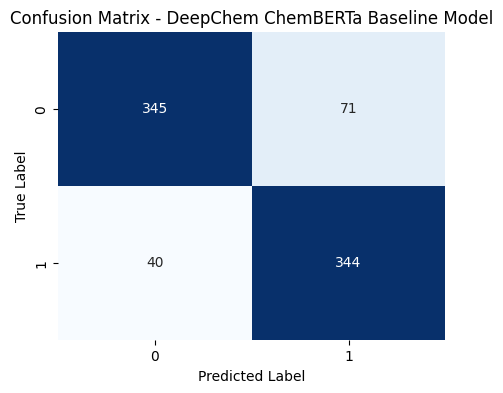

In [ ]:
# Model Evaluate
evaluate_model("DeepChem ChemBERTa Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/DeepChem ChemBERTa_baseline_loss.csv")

Loss history saved to Data Hasil/DeepChem ChemBERTa_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training DeepChem ChemBERTa with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.586300,0.494523,0.766250,0.758085,0.753213,0.763021
2,0.417200,0.448468,0.803750,0.803995,0.772182,0.838542
3,0.351600,0.452177,0.810000,0.819048,0.754386,0.895833
4,0.304400,0.433283,0.843750,0.841169,0.821340,0.861979
5,0.279400,0.428409,0.842500,0.845209,0.800000,0.895833
6,0.259400,0.431692,0.848750,0.845070,0.831234,0.859375
7,0.243500,0.452602,0.860000,0.860349,0.825359,0.898438
8,0.225000,0.475052,0.852500,0.855746,0.806452,0.911458
9,0.221100,0.465377,0.860000,0.860000,0.826923,0.895833
10,0.208500,0.468710,0.857500,0.857143,0.826087,0.890625


=== DeepChem ChemBERTa  adp=0.1 hdp=0.1 ===
Accuracy: 0.8575
Precision: 0.8260869565217391
Recall: 0.890625
F1: 0.8571428571428571
Confusion Matrix:
[[344  72]
 [ 42 342]]



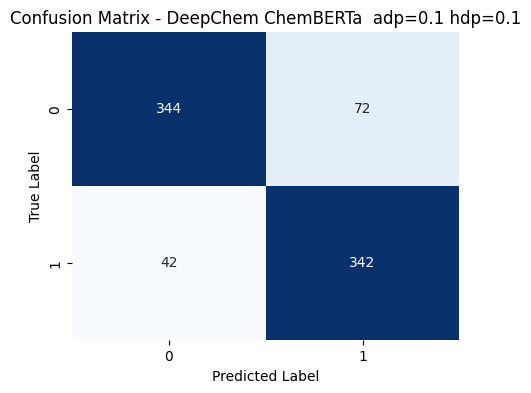


=== Training DeepChem ChemBERTa with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.615600,0.514331,0.747500,0.751843,0.711628,0.796875
2,0.448600,0.477845,0.785000,0.790244,0.743119,0.843750
3,0.388700,0.498560,0.787500,0.800937,0.727660,0.890625
4,0.341300,0.488664,0.813750,0.821983,0.759382,0.895833
5,0.337100,0.476592,0.827500,0.834928,0.772124,0.908854
6,0.308100,0.444151,0.836250,0.838072,0.797647,0.882812
7,0.299600,0.519989,0.823750,0.835088,0.757962,0.929688
8,0.281600,0.522041,0.820000,0.832947,0.751046,0.934896
9,0.272300,0.496788,0.843750,0.850299,0.787140,0.924479
10,0.283500,0.480385,0.850000,0.855072,0.797297,0.921875


=== DeepChem ChemBERTa  adp=0.1 hdp=0.2 ===
Accuracy: 0.83625
Precision: 0.7685774946921444
Recall: 0.9427083333333334
F1: 0.8467836257309942
Confusion Matrix:
[[307 109]
 [ 22 362]]



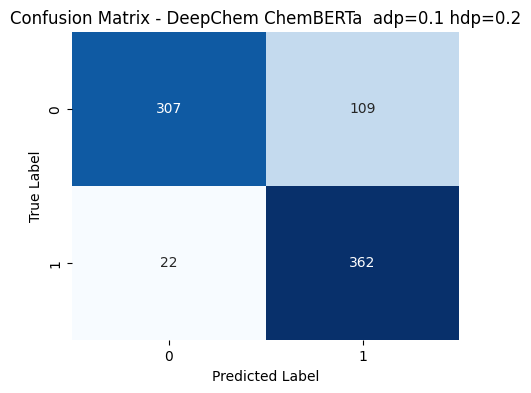


=== Training DeepChem ChemBERTa with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.650000,0.564116,0.750000,0.749373,0.722222,0.778646
2,0.489600,0.506450,0.761250,0.763906,0.727059,0.804688
3,0.430700,0.503036,0.782500,0.787805,0.740826,0.841146
4,0.396400,0.498340,0.790000,0.794621,0.748848,0.846354
5,0.379000,0.494575,0.791250,0.798065,0.744921,0.859375
6,0.366900,0.466455,0.808750,0.811344,0.770492,0.856771
7,0.348700,0.552826,0.796250,0.811561,0.729730,0.914062
8,0.335200,0.524163,0.800000,0.813084,0.737288,0.906250
9,0.324100,0.507155,0.817500,0.826603,0.759825,0.906250
10,0.327300,0.531923,0.812500,0.823944,0.750000,0.914062


=== DeepChem ChemBERTa  adp=0.1 hdp=0.3 ===
Accuracy: 0.81875
Precision: 0.750524109014675
Recall: 0.9322916666666666
F1: 0.8315911730545877
Confusion Matrix:
[[297 119]
 [ 26 358]]



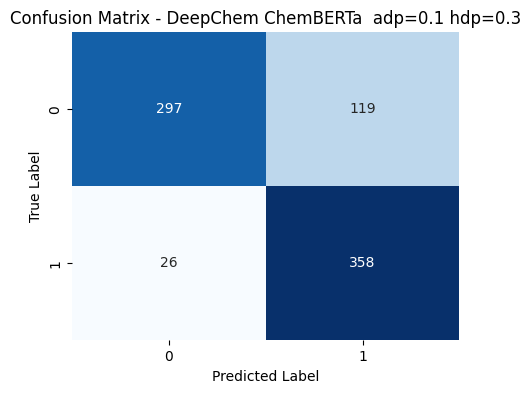


=== Training DeepChem ChemBERTa with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.610000,0.505413,0.770000,0.770000,0.740385,0.802083
2,0.447400,0.477230,0.788750,0.793651,0.747126,0.846354
3,0.390600,0.453126,0.810000,0.814634,0.766055,0.869792
4,0.338900,0.449127,0.831250,0.828025,0.810474,0.846354
5,0.330100,0.439263,0.835000,0.836634,0.797170,0.880208
6,0.304700,0.408859,0.848750,0.846252,0.826303,0.867188
7,0.285800,0.438150,0.846250,0.846824,0.811456,0.885417
8,0.278600,0.437494,0.851250,0.853268,0.810304,0.901042
9,0.259900,0.456078,0.850000,0.850746,0.814286,0.890625
10,0.262200,0.453295,0.853750,0.854658,0.817102,0.895833


=== DeepChem ChemBERTa  adp=0.2 hdp=0.1 ===
Accuracy: 0.85625
Precision: 0.8077803203661327
Recall: 0.9192708333333334
F1: 0.8599269183922046
Confusion Matrix:
[[332  84]
 [ 31 353]]



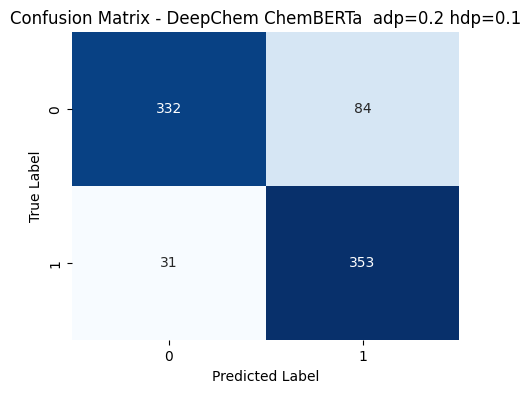


=== Training DeepChem ChemBERTa with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.629200,0.530597,0.750000,0.748111,0.724390,0.773438
2,0.471700,0.493261,0.768750,0.771323,0.734118,0.812500
3,0.416600,0.487021,0.790000,0.790524,0.758373,0.825521
4,0.376500,0.478555,0.811250,0.810540,0.782082,0.841146
5,0.365300,0.464231,0.821250,0.821473,0.788969,0.856771
6,0.349000,0.448617,0.825000,0.820051,0.809645,0.830729
7,0.336600,0.486922,0.825000,0.830918,0.774775,0.895833
8,0.318300,0.458078,0.840000,0.841584,0.801887,0.885417
9,0.302700,0.454789,0.846250,0.846442,0.812950,0.882812
10,0.320800,0.440023,0.855000,0.855362,0.820574,0.893229


=== DeepChem ChemBERTa  adp=0.2 hdp=0.2 ===
Accuracy: 0.85
Precision: 0.8069767441860465
Recall: 0.9036458333333334
F1: 0.8525798525798526
Confusion Matrix:
[[333  83]
 [ 37 347]]



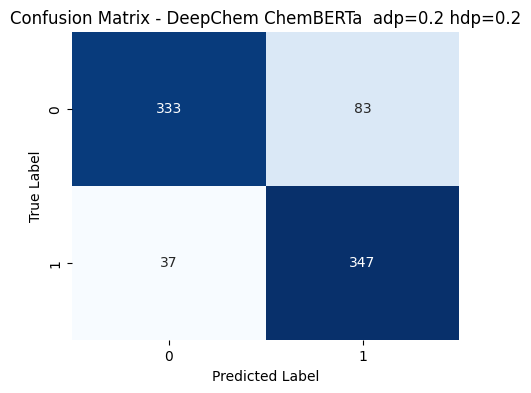


=== Training DeepChem ChemBERTa with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.643100,0.575928,0.731250,0.747948,0.680171,0.830729
2,0.494200,0.514724,0.760000,0.772512,0.708696,0.848958
3,0.440100,0.512264,0.768750,0.780546,0.716776,0.856771
4,0.416700,0.486773,0.786250,0.791209,0.744828,0.843750
5,0.409100,0.480831,0.791250,0.799037,0.742729,0.864583
6,0.380300,0.468800,0.788750,0.790582,0.754137,0.830729
7,0.381400,0.509423,0.783750,0.798603,0.722105,0.893229
8,0.365000,0.514427,0.785000,0.801386,0.719917,0.903646
9,0.355600,0.492789,0.798750,0.810365,0.739785,0.895833
10,0.373700,0.506440,0.797500,0.810304,0.736170,0.901042


=== DeepChem ChemBERTa  adp=0.2 hdp=0.3 ===
Accuracy: 0.8
Precision: 0.7333333333333333
Recall: 0.9166666666666666
F1: 0.8148148148148148
Confusion Matrix:
[[288 128]
 [ 32 352]]



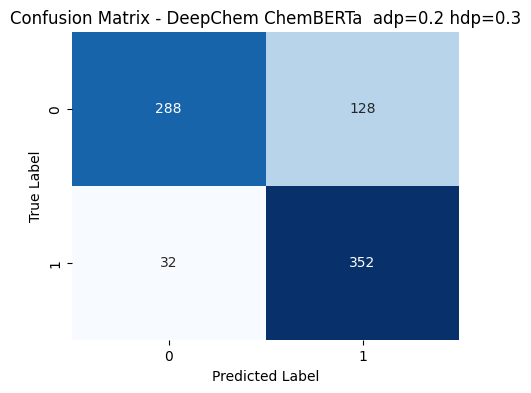


=== Training DeepChem ChemBERTa with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.609200,0.515975,0.762500,0.767157,0.724537,0.815104
2,0.456500,0.481956,0.785000,0.787654,0.748826,0.830729
3,0.408200,0.477444,0.795000,0.800971,0.750000,0.859375
4,0.365300,0.467324,0.808750,0.812270,0.767981,0.861979
5,0.350800,0.457498,0.825000,0.826733,0.787736,0.869792
6,0.345400,0.438499,0.815000,0.808786,0.802564,0.815104
7,0.330300,0.492007,0.822500,0.830549,0.766520,0.906250
8,0.320900,0.454529,0.841250,0.844553,0.796767,0.898438
9,0.294800,0.458586,0.837500,0.839901,0.796729,0.888021
10,0.312400,0.437909,0.837500,0.837093,0.806763,0.869792


=== DeepChem ChemBERTa  adp=0.3 hdp=0.1 ===
Accuracy: 0.84625
Precision: 0.7972665148063781
Recall: 0.9114583333333334
F1: 0.850546780072904
Confusion Matrix:
[[327  89]
 [ 34 350]]



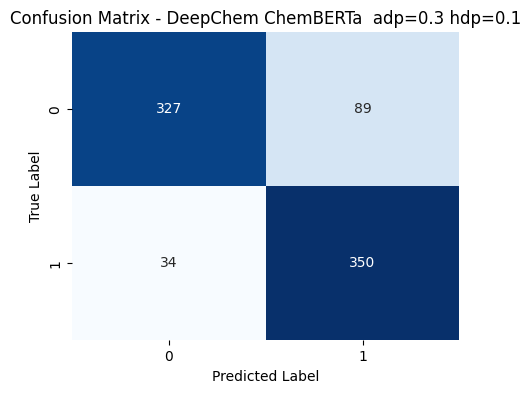


=== Training DeepChem ChemBERTa with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.631300,0.551693,0.742500,0.757647,0.690987,0.838542
2,0.486500,0.512021,0.772500,0.784870,0.718615,0.864583
3,0.438600,0.499211,0.783750,0.795266,0.728850,0.875000
4,0.397200,0.479153,0.798750,0.805320,0.751693,0.867188
5,0.384700,0.495171,0.798750,0.809917,0.740821,0.893229
6,0.377700,0.460414,0.818750,0.823815,0.772210,0.882812
7,0.362100,0.536927,0.787500,0.805492,0.718367,0.916667
8,0.350100,0.514784,0.792500,0.809633,0.723361,0.919271
9,0.341300,0.501744,0.807500,0.819249,0.745726,0.908854


=== DeepChem ChemBERTa  adp=0.3 hdp=0.2 ===
Accuracy: 0.8075
Precision: 0.7457264957264957
Recall: 0.9088541666666666
F1: 0.8192488262910798
Confusion Matrix:
[[297 119]
 [ 35 349]]



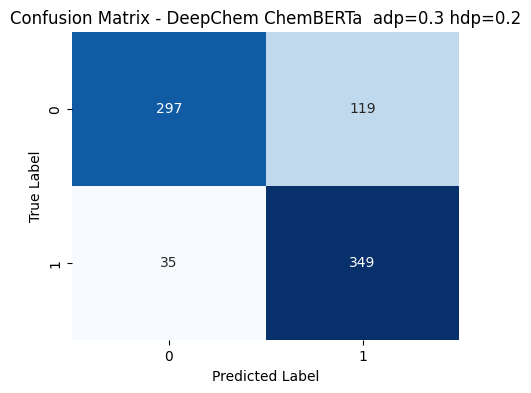


=== Training DeepChem ChemBERTa with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.656500,0.593580,0.726250,0.748565,0.669405,0.848958
2,0.515800,0.537376,0.747500,0.770455,0.683468,0.882812
3,0.464700,0.522139,0.771250,0.787456,0.710692,0.882812
4,0.431600,0.494765,0.791250,0.796093,0.749425,0.848958
5,0.434400,0.505614,0.795000,0.808411,0.733051,0.901042
6,0.398300,0.478999,0.797500,0.804819,0.748879,0.869792
7,0.408400,0.550349,0.777500,0.798643,0.706000,0.919271
8,0.385300,0.537184,0.778750,0.798635,0.709091,0.914062


=== DeepChem ChemBERTa  adp=0.3 hdp=0.3 ===
Accuracy: 0.77875
Precision: 0.7090909090909091
Recall: 0.9140625
F1: 0.7986348122866894
Confusion Matrix:
[[272 144]
 [ 33 351]]



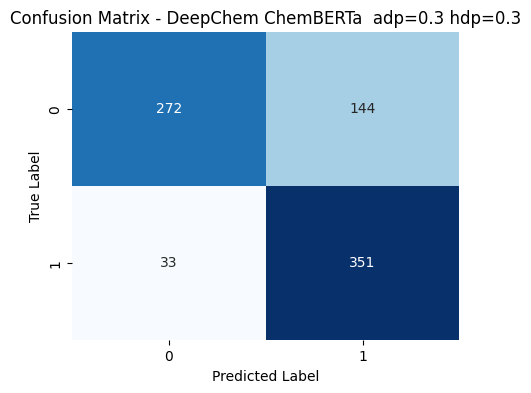

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training DeepChem ChemBERTa with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
            "DeepChem/ChemBERTa-77M-MLM",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"DeepChem ChemBERTa  adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning DeepChem ChemBerta ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning DeepChem ChemBerta ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.85750   0.826087   
1                           0.1                  0.2   0.83625   0.768577   
2                           0.1                  0.3   0.81875   0.750524   
3                           0.2                  0.1   0.85625   0.807780   
4                           0.2                  0.2   0.85000   0.806977   
5                           0.2                  0.3   0.80000   0.733333   
6                           0.3                  0.1   0.84625   0.797267   
7                           0.3                  0.2   0.80750   0.745726   
8                           0.3                  0.3   0.77875   0.709091   

     Recall        F1  
0  0.890625  0.857143  
1  0.942708  0.846784  
2  0.932292  0.831591  
3  0.919271  0.859927  
4  0.903646  0.852580  
5  0.916667  0.814815  
6

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
3,0.2,0.1,0.85625,0.80778,0.919271,0.859927


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.1)

In [ ]:
df_results.to_csv('Data Hasil/DeepChem ChemBERTa Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\nDeepChem ChemBERTa TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("DeepChem/ChemBERTa-77M-MLM", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_DeepChem_Chemberta")
        np.save("Data Hasil/Best_Model_DeepChem_Chemberta/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-06 16:21:16,813] A new study created in memory with name: no-name-1401036b-f226-4be1-bf08-825206d985db


Start Hyperparameter Tunning

DeepChem ChemBERTa TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.665500,0.624710,0.741250,0.742217,0.711217,0.776042
2,0.571700,0.521312,0.758750,0.758448,0.730120,0.789062
3,0.477700,0.486211,0.776250,0.776529,0.745803,0.809896
4,0.426000,0.470698,0.791250,0.782835,0.781818,0.783854
5,0.399900,0.458617,0.815000,0.808290,0.804124,0.812500
6,0.379000,0.451375,0.818750,0.812903,0.805627,0.820312
7,0.361200,0.461262,0.810000,0.808564,0.782927,0.835938
8,0.352300,0.450663,0.808750,0.806574,0.783784,0.830729
9,0.346100,0.448425,0.818750,0.813385,0.804071,0.822917
10,0.337600,0.451010,0.820000,0.816327,0.800000,0.833333


[I 2026-01-06 16:22:35,976] Trial 0 finished with value: 0.8299492385786802 and parameters: {'learning_rate': 2e-05, 'weight_decay': 0.01, 'batch_size': 8}. Best is trial 0 with value: 0.8299492385786802.


...

[I 2026-01-06 16:38:31,218] Trial 16 finished with value: 0.8553615960099751 and parameters: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 2 with value: 0.866581956797967.



DeepChem ChemBERTa TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.670600,0.626447,0.746250,0.739409,0.729114,0.750000
2,0.564200,0.510325,0.760000,0.748691,0.752632,0.744792
3,0.462000,0.481313,0.782500,0.779747,0.758621,0.802083
4,0.419500,0.459417,0.790000,0.782383,0.778351,0.786458
5,0.385400,0.449970,0.801250,0.791612,0.796834,0.786458
6,0.369600,0.444429,0.810000,0.807107,0.787129,0.828125
7,0.353800,0.444150,0.815000,0.812183,0.792079,0.833333
8,0.341500,0.435249,0.818750,0.816223,0.795062,0.838542
9,0.327000,0.427781,0.825000,0.823232,0.799020,0.848958
10,0.320600,0.425768,0.827500,0.824427,0.805970,0.843750


[I 2026-01-06 16:39:17,139] Trial 17 finished with value: 0.8407643312101911 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 2 with value: 0.866581956797967.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_DeepChem_chemberta.csv", index=False)
joblib.dump(study, f"Data Hasil/study_DeepChem_chemberta.pkl")


=== BEST RESULT ===
Best F1: 0.866581956797967
Best Params: {'learning_rate': 5e-05, 'weight_decay': 0.1, 'batch_size': 8}


['Data Hasil/study_DeepChem_chemberta.pkl']

In [ ]:
data_chemberta_DeepChem = pd.read_csv("Data Hasil/optuna_results_DeepChem_chemberta.csv")
data_chemberta_DeepChem

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.829949,2026-01-06 16:21:16.814929,2026-01-06 16:22:35.976837,0 days 00:01:19.161908,8,0.00002,0.01,0.83250,"[[341, 75], [59, 325]]",0.829949,0.809406,0.851562,"[0.6655, 0.5717, 0.4777, 0.426, 0.3999, 0.379,...","[0.6247102618217468, 0.5213119983673096, 0.486...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.865672,2026-01-06 16:22:35.977810,2026-01-06 16:23:51.723213,0 days 00:01:15.745403,8,0.00005,0.00,0.86500,"[[345, 71], [38, 346]]",0.865672,0.828571,0.906250,"[0.5961, 0.4422, 0.3824, 0.3371, 0.3229, 0.302...","[0.5006580948829651, 0.46882542967796326, 0.46...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.866582,2026-01-06 16:23:51.724258,2026-01-06 16:25:11.322264,0 days 00:01:19.598006,8,0.00005,0.10,0.86875,"[[354, 62], [43, 341]]",0.866582,0.846154,0.888021,"[0.6087, 0.4514, 0.3927, 0.342, 0.3263, 0.3004...","[0.5130051374435425, 0.463379830121994, 0.4497...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.835192,2026-01-06 16:25:11.323183,2026-01-06 16:26:05.144193,0 days 00:00:53.821010,16,0.00002,0.01,0.83375,"[[331, 85], [49, 335]]",0.835192,0.796690,0.877604,"[0.6782, 0.622, 0.5291, 0.4667, 0.433, 0.4035,...","[0.654132604598999, 0.5753127336502075, 0.5080...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.845283,2026-01-06 16:26:05.145116,2026-01-06 16:26:48.308143,0 days 00:00:43.163027,16,0.00003,0.10,0.84625,"[[335, 81], [44, 340]]",0.845283,0.817518,0.875000,"[0.6679, 0.5546, 0.4602, 0.4165, 0.3855, 0.359...","[0.6251905560493469, 0.5075751543045044, 0.479...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.858942,2026-01-06 16:26:48.308849,2026-01-06 16:28:03.952413,0 days 00:01:15.643564,8,0.00003,0.01,0.86000,"[[347, 69], [44, 340]]",0.858942,0.831707,0.888021,"[0.6496, 0.4978, 0.4258, 0.3758, 0.3622, 0.349...","[0.5708328485488892, 0.48548081517219543, 0.46...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.817481,2026-01-06 16:28:03.953139,2026-01-06 16:28:47.976266,0 days 00:00:44.023127,8,0.00002,0.10,0.82250,"[[338, 78], [66, 318]]",0.817481,0.807107,0.828125,"[0.6694, 0.5791, 0.4939, 0.4412, 0.4144, 0.390...","[0.6297301650047302, 0.5308205485343933, 0.491...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.855709,2026-01-06 16:28:47.977706,2026-01-06 16:29:26.012771,0 days 00:00:38.035065,16,0.00005,0.01,0.85625,"[[354, 62], [57, 327]]",0.855709,0.825666,0.888021,"[0.6357, 0.4702, 0.4045, 0.3692, 0.3369, 0.318...","[0.5522284507751465, 0.48182544112205505, 0.45...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.866083,2026-01-06 16:29:26.013454,2026-01-06 16:30:14.877333,0 days 00:00:48.863879,16,0.00005,0.10,0.86625,"[[341, 75], [35, 349]]",0.866083,0.833735,0.901042,"[0.6427, 0.4767, 0.4037, 0.3643, 0.3279, 0.317...","[0.5518675446510315, 0.46798408031463623, 0.43...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.821159,2026-01-06 16:30:14.878017,2026-01-06 16:31:08.728013,0 days 00:00:53.849996,16,0.00002,0.00,0.82250,"[[333, 83], [62, 322]]",0.821159,0.795122,0.848958,"[0.6803, 0.6256, 0.5329, 0.4743, 0.439, 0.4131...","[0.6573339700698853, 0.5813344120979309, 0.513...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_chemberta_DeepChem.sort_values(by='value', ascending=False, inplace=True)
data_chemberta_DeepChem

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
2,2,0.866582,2026-01-06 16:23:51.724258,2026-01-06 16:25:11.322264,0 days 00:01:19.598006,8,0.00005,0.10,0.86875,"[[354, 62], [43, 341]]",0.866582,0.846154,0.888021,"[0.6087, 0.4514, 0.3927, 0.342, 0.3263, 0.3004...","[0.5130051374435425, 0.463379830121994, 0.4497...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.866083,2026-01-06 16:29:26.013454,2026-01-06 16:30:14.877333,0 days 00:00:48.863879,16,0.00005,0.10,0.86625,"[[341, 75], [35, 349]]",0.866083,0.833735,0.901042,"[0.6427, 0.4767, 0.4037, 0.3643, 0.3279, 0.317...","[0.5518675446510315, 0.46798408031463623, 0.43...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
10,10,0.865672,2026-01-06 16:31:08.728818,2026-01-06 16:32:24.249044,0 days 00:01:15.520226,8,0.00005,0.01,0.86500,"[[345, 71], [38, 346]]",0.865672,0.828571,0.906250,"[0.5961, 0.4422, 0.3824, 0.3371, 0.3229, 0.302...","[0.5006577968597412, 0.46882981061935425, 0.46...",10,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.865672,2026-01-06 16:22:35.977810,2026-01-06 16:23:51.723213,0 days 00:01:15.745403,8,0.00005,0.00,0.86500,"[[345, 71], [38, 346]]",0.865672,0.828571,0.906250,"[0.5961, 0.4422, 0.3824, 0.3371, 0.3229, 0.302...","[0.5006580948829651, 0.46882542967796326, 0.46...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.858942,2026-01-06 16:26:48.308849,2026-01-06 16:28:03.952413,0 days 00:01:15.643564,8,0.00003,0.01,0.86000,"[[347, 69], [44, 340]]",0.858942,0.831707,0.888021,"[0.6496, 0.4978, 0.4258, 0.3758, 0.3622, 0.349...","[0.5708328485488892, 0.48548081517219543, 0.46...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
15,15,0.857855,2026-01-06 16:36:27.848068,2026-01-06 16:37:47.571212,0 days 00:01:19.723144,8,0.00003,0.10,0.85750,"[[342, 74], [40, 344]]",0.857855,0.822967,0.895833,"[0.6431, 0.4951, 0.4282, 0.3794, 0.357, 0.3417...","[0.565536379814148, 0.49179863929748535, 0.478...",15,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.855709,2026-01-06 16:28:47.977706,2026-01-06 16:29:26.012771,0 days 00:00:38.035065,16,0.00005,0.01,0.85625,"[[354, 62], [57, 327]]",0.855709,0.825666,0.888021,"[0.6357, 0.4702, 0.4045, 0.3692, 0.3369, 0.318...","[0.5522284507751465, 0.48182544112205505, 0.45...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
16,16,0.855362,2026-01-06 16:37:47.572296,2026-01-06 16:38:31.218638,0 days 00:00:43.646342,16,0.00005,0.00,0.85500,"[[334, 82], [38, 346]]",0.855362,0.820574,0.893229,"[0.6391, 0.4687, 0.4082, 0.3683, 0.338, 0.3182...","[0.5509769320487976, 0.4760130047798157, 0.462...",16,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
13,13,0.847584,2026-01-06 16:34:11.928352,2026-01-06 16:35:07.976461,0 days 00:00:56.048109,8,0.00003,0.00,0.84625,"[[342, 74], [48, 336]]",0.847584,0.808511,0.890625,"[0.6431, 0.4951, 0.4283, 0.3795, 0.3571, 0.341...","[0.5655201077461243, 0.49184975028038025, 0.47...",13,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.845283,2026-01-06 16:26:05.145116,2026-01-06 16:26:48.308143,0 days 00:00:43.163027,16,0.00003,0.10,0.84625,"[[335, 81], [44, 340]]",0.845283,0.817518,0.875000,"[0.6679, 0.5546, 0.4602, 0.4165, 0.3855, 0.359...","[0.6251905560493469, 0.5075751543045044, 0.479...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


# TRANSFORMERS ChemBERTa MODEL 3 ("Derify/ChemBERTa-druglike")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "Derify/ChemBERTa-druglike"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

model.safetensors:   0%|          | 0.00/612M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([ 0,  6,  6, 10, 12,  6, 13, 12,  6,  7, 13, 12,  6, 10, 13,  6, 11, 12,
          6,  7, 24,  6, 12,  6, 11,  8,  6,  7, 12,  9,  8,  9,  6,  8, 13,  6,
         16, 12,  6,  7,  6, 12,  6,  7,  6, 12,  6, 16,  8, 13, 22,  6,  6,  6,
          7,  6,  6, 22,  8, 13,  7,  6,  8,  6,  8,  9,  6,  2,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.449400,0.597493,0.828750,0.833939,0.780045,0.895833
2,0.379900,0.439287,0.817500,0.827423,0.757576,0.911458
3,0.319200,0.557560,0.845000,0.834225,0.857143,0.812500
4,0.257600,0.531105,0.862500,0.858974,0.845960,0.872396
5,0.243900,0.585252,0.866250,0.863694,0.845387,0.882812
6,0.216100,0.555485,0.866250,0.860858,0.859740,0.861979
7,0.189200,0.605571,0.883750,0.881226,0.864662,0.898438
8,0.150600,0.635870,0.877500,0.878109,0.840476,0.919271
9,0.131800,0.584874,0.883750,0.881226,0.864662,0.898438
10,0.106000,0.583737,0.883750,0.880616,0.868354,0.893229


TrainOutput(global_step=2340, training_loss=0.24436793042044355, metrics={'train_runtime': 968.9037, 'train_samples_per_second': 38.518, 'train_steps_per_second': 4.83, 'total_flos': 1840455096828480.0, 'train_loss': 0.24436793042044355, 'epoch': 10.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       416
           1       0.86      0.90      0.88       384

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800


Confusion Matrix:
[[362  54]
 [ 39 345]]


=== Derify ChemBERTa Baseline Model ===
Accuracy: 0.88375
Precision: 0.8646616541353384
Recall: 0.8984375
F1: 0.8812260536398467
Confusion Matrix:
[[362  54]
 [ 39 345]]



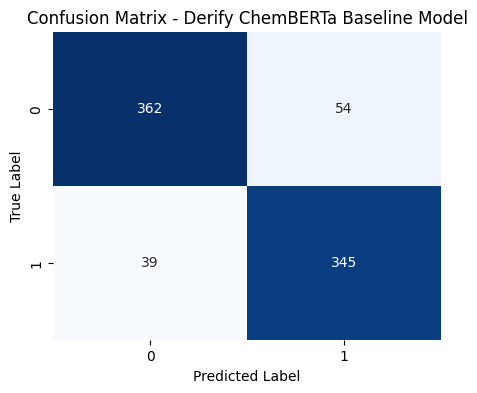

In [ ]:
# Model Evaluate
evaluate_model("Derify ChemBERTa Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/Derify ChemBERTa_baseline_loss.csv")

Loss history saved to Data Hasil/Derify ChemBERTa_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training Derify ChemBERTa with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.470400,0.736275,0.788750,0.805970,0.720739,0.914062
2,0.404300,0.407598,0.851250,0.853629,0.808858,0.903646
3,0.337700,0.328004,0.882500,0.879177,0.868020,0.890625
4,0.276000,0.536154,0.861250,0.857510,0.845570,0.869792
5,0.258800,0.528207,0.866250,0.863694,0.845387,0.882812
6,0.244800,0.422507,0.862500,0.856021,0.860526,0.851562


=== Derify ChemBERTa  adp=0.1 hdp=0.1 ===
Accuracy: 0.8625
Precision: 0.8605263157894737
Recall: 0.8515625
F1: 0.856020942408377
Confusion Matrix:
[[363  53]
 [ 57 327]]



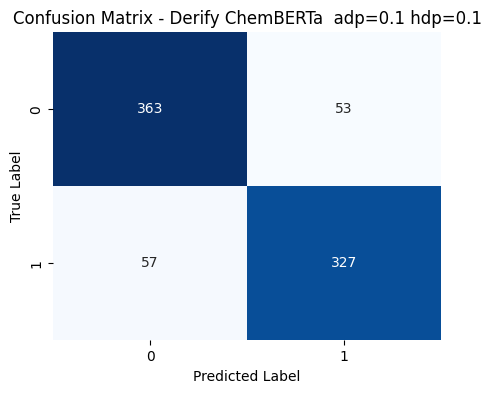


=== Training Derify ChemBERTa with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.473700,0.666953,0.813750,0.825731,0.749469,0.919271
2,0.370800,0.459170,0.817500,0.826603,0.759825,0.906250
3,0.322200,0.442449,0.847500,0.835135,0.867978,0.804688
4,0.287700,0.525211,0.867500,0.864103,0.851010,0.877604
5,0.248800,0.641422,0.867500,0.866499,0.839024,0.895833
6,0.237500,0.494014,0.875000,0.872774,0.853234,0.893229
7,0.199200,0.661649,0.871250,0.871089,0.838554,0.906250
8,0.154900,0.620380,0.870000,0.867008,0.851759,0.882812
9,0.140300,0.613060,0.892500,0.891414,0.865196,0.919271
10,0.129400,0.619063,0.885000,0.882051,0.868687,0.895833


=== Derify ChemBERTa  adp=0.1 hdp=0.2 ===
Accuracy: 0.8775
Precision: 0.8629441624365483
Recall: 0.8854166666666666
F1: 0.8740359897172236
Confusion Matrix:
[[362  54]
 [ 44 340]]



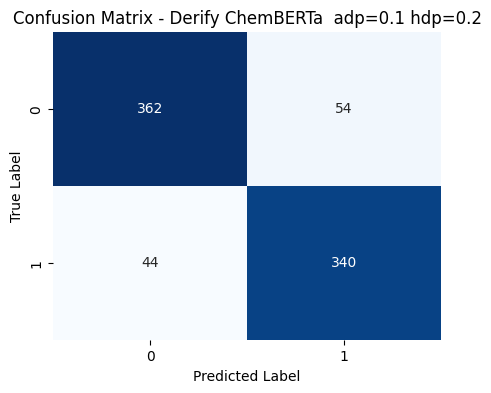


=== Training Derify ChemBERTa with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.475500,0.689552,0.793750,0.807468,0.731501,0.901042
2,0.385700,0.421443,0.838750,0.836915,0.813268,0.861979
3,0.345000,0.401500,0.868750,0.865557,0.851385,0.880208
4,0.295500,0.481889,0.868750,0.864166,0.858612,0.869792
5,0.269700,0.652353,0.863750,0.864932,0.825059,0.908854
6,0.257400,0.532598,0.878750,0.872200,0.882667,0.861979
7,0.207900,0.674450,0.878750,0.874515,0.868895,0.880208
8,0.201700,0.631169,0.877500,0.874036,0.862944,0.885417
9,0.194600,0.617272,0.895000,0.894207,0.865854,0.924479
10,0.156400,0.506603,0.887500,0.884910,0.869347,0.901042


=== Derify ChemBERTa  adp=0.1 hdp=0.3 ===
Accuracy: 0.89125
Precision: 0.9002695417789758
Recall: 0.8697916666666666
F1: 0.8847682119205298
Confusion Matrix:
[[379  37]
 [ 50 334]]



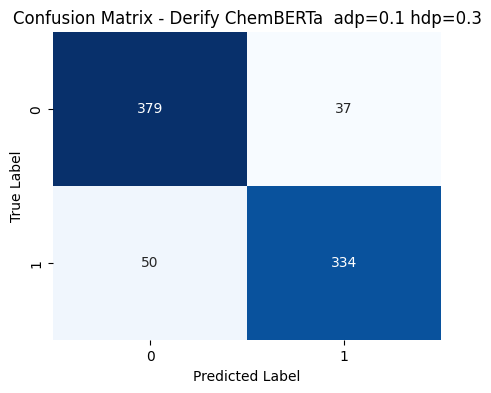


=== Training Derify ChemBERTa with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.497800,0.696205,0.795000,0.812785,0.723577,0.927083
2,0.380600,0.361402,0.852500,0.854680,0.810748,0.903646
3,0.315400,0.335113,0.867500,0.860892,0.867725,0.854167
4,0.283500,0.434746,0.852500,0.852868,0.818182,0.890625
5,0.259400,0.489083,0.878750,0.878294,0.847458,0.911458
6,0.224200,0.443235,0.891250,0.890013,0.864865,0.916667
7,0.183400,0.528445,0.888750,0.888889,0.853717,0.927083
8,0.166300,0.462588,0.890000,0.890547,0.852381,0.932292
9,0.142700,0.537587,0.891250,0.891114,0.857831,0.927083
10,0.114600,0.484641,0.902500,0.900763,0.880597,0.921875


=== Derify ChemBERTa  adp=0.2 hdp=0.1 ===
Accuracy: 0.9
Precision: 0.874384236453202
Recall: 0.9244791666666666
F1: 0.8987341772151899
Confusion Matrix:
[[365  51]
 [ 29 355]]



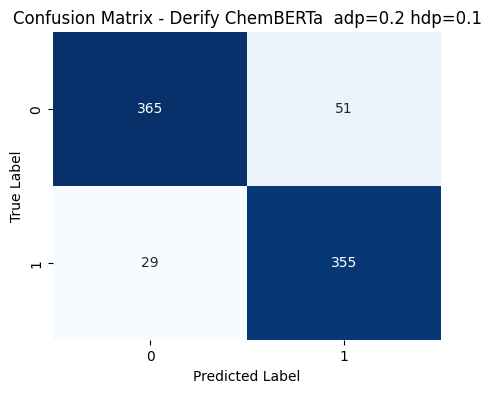


=== Training Derify ChemBERTa with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.486100,0.525075,0.818750,0.823386,0.773455,0.880208
2,0.392700,0.438521,0.837500,0.844125,0.782222,0.916667
3,0.365700,0.416780,0.845000,0.841026,0.828283,0.854167
4,0.303500,0.444206,0.878750,0.877680,0.850856,0.906250
5,0.269500,0.562974,0.862500,0.863861,0.823113,0.908854
6,0.258600,0.516268,0.865000,0.862595,0.843284,0.882812
7,0.222900,0.622834,0.872500,0.868557,0.859694,0.877604


=== Derify ChemBERTa  adp=0.2 hdp=0.2 ===
Accuracy: 0.8725
Precision: 0.8596938775510204
Recall: 0.8776041666666666
F1: 0.8685567010309279
Confusion Matrix:
[[361  55]
 [ 47 337]]



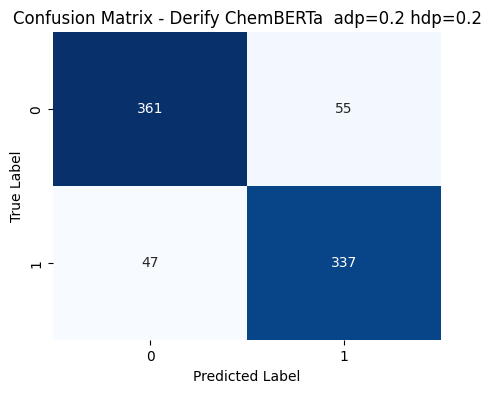


=== Training Derify ChemBERTa with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.515700,0.661988,0.796250,0.814562,0.723232,0.932292
2,0.426300,0.460186,0.826250,0.832732,0.774049,0.901042
3,0.366200,0.474448,0.858750,0.854194,0.846547,0.861979
4,0.308500,0.553368,0.865000,0.861893,0.846734,0.877604
5,0.281600,0.747073,0.852500,0.855746,0.806452,0.911458
6,0.291400,0.539691,0.865000,0.860465,0.853846,0.867188
7,0.251500,0.635773,0.876250,0.873563,0.857143,0.890625
8,0.237600,0.614692,0.880000,0.876923,0.863636,0.890625
9,0.222200,0.672645,0.876250,0.872587,0.862595,0.882812
10,0.190100,0.610509,0.870000,0.872236,0.825581,0.924479


=== Derify ChemBERTa  adp=0.2 hdp=0.3 ===
Accuracy: 0.8825
Precision: 0.84688995215311
Recall: 0.921875
F1: 0.8827930174563591
Confusion Matrix:
[[352  64]
 [ 30 354]]



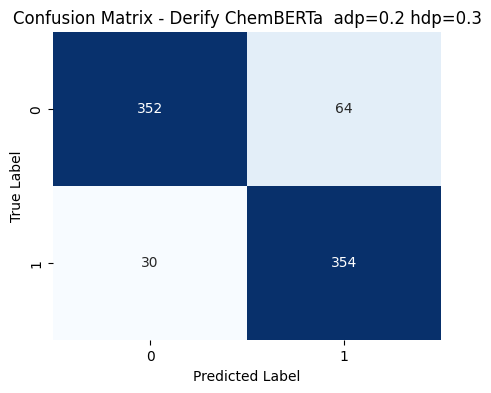


=== Training Derify ChemBERTa with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.471300,0.590608,0.805000,0.815166,0.747826,0.895833
2,0.399300,0.377773,0.848750,0.854392,0.794183,0.924479
3,0.348100,0.410931,0.851250,0.850314,0.822384,0.880208
4,0.307100,0.530413,0.875000,0.870801,0.864103,0.877604
5,0.288700,0.596012,0.852500,0.853234,0.816667,0.893229
6,0.291100,0.484683,0.863750,0.859355,0.851662,0.867188
7,0.232800,0.574716,0.870000,0.868687,0.843137,0.895833


=== Derify ChemBERTa  adp=0.3 hdp=0.1 ===
Accuracy: 0.87
Precision: 0.8431372549019608
Recall: 0.8958333333333334
F1: 0.8686868686868687
Confusion Matrix:
[[352  64]
 [ 40 344]]



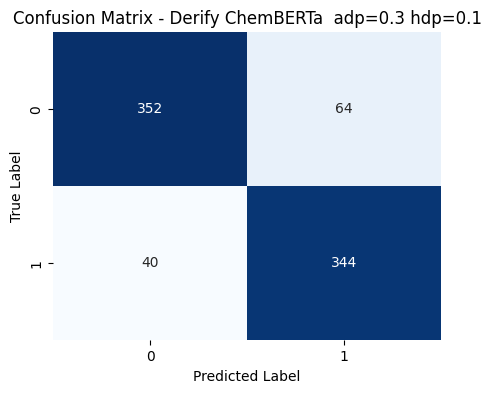


=== Training Derify ChemBERTa with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.499100,0.654640,0.807500,0.816667,0.752193,0.893229
2,0.420000,0.439431,0.812500,0.827189,0.741736,0.934896
3,0.378100,0.535726,0.816250,0.814159,0.791155,0.838542
4,0.357000,0.465232,0.847500,0.846734,0.817961,0.877604
5,0.321400,0.795443,0.827500,0.837647,0.763948,0.927083
6,0.295500,0.607700,0.842500,0.837209,0.830769,0.843750
7,0.282000,0.645563,0.855000,0.854271,0.825243,0.885417
8,0.258800,0.580948,0.853750,0.856442,0.809745,0.908854
9,0.245900,0.599478,0.878750,0.874515,0.868895,0.880208
10,0.211900,0.571625,0.861250,0.861423,0.827338,0.898438


=== Derify ChemBERTa  adp=0.3 hdp=0.2 ===
Accuracy: 0.87875
Precision: 0.8614609571788413
Recall: 0.890625
F1: 0.8758002560819462
Confusion Matrix:
[[361  55]
 [ 42 342]]



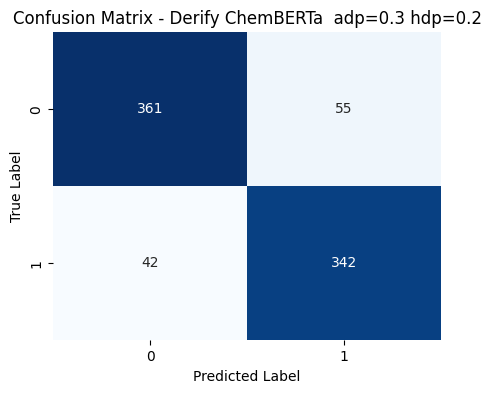


=== Training Derify ChemBERTa with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.571100,0.700778,0.745000,0.774834,0.672414,0.914062
2,0.474900,0.472641,0.803750,0.808303,0.760920,0.861979
3,0.410000,0.560467,0.805000,0.811138,0.757919,0.872396
4,0.375200,0.613906,0.812500,0.817073,0.768349,0.872396
5,0.376300,0.898290,0.808750,0.821470,0.744186,0.916667
6,0.362000,0.554710,0.850000,0.843342,0.845550,0.841146
7,0.344100,0.655478,0.847500,0.851220,0.800459,0.908854
8,0.314700,0.557438,0.858750,0.858218,0.828087,0.890625
9,0.302500,0.790786,0.855000,0.852417,0.833333,0.872396
10,0.311000,0.635934,0.853750,0.856793,0.808314,0.911458


=== Derify ChemBERTa  adp=0.3 hdp=0.3 ===
Accuracy: 0.85125
Precision: 0.796420581655481
Recall: 0.9270833333333334
F1: 0.8567990373044525
Confusion Matrix:
[[325  91]
 [ 28 356]]



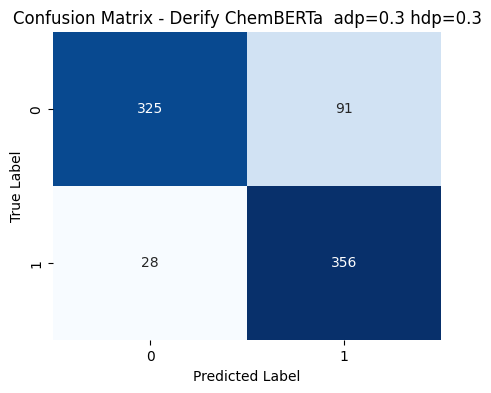

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training Derify ChemBERTa with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
            "Derify/ChemBERTa-druglike",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"Derify ChemBERTa  adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning Derify ChemBerta ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning Derify ChemBerta ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.86250   0.860526   
1                           0.1                  0.2   0.87750   0.862944   
2                           0.1                  0.3   0.89125   0.900270   
3                           0.2                  0.1   0.90000   0.874384   
4                           0.2                  0.2   0.87250   0.859694   
5                           0.2                  0.3   0.88250   0.846890   
6                           0.3                  0.1   0.87000   0.843137   
7                           0.3                  0.2   0.87875   0.861461   
8                           0.3                  0.3   0.85125   0.796421   

     Recall        F1  
0  0.851562  0.856021  
1  0.885417  0.874036  
2  0.869792  0.884768  
3  0.924479  0.898734  
4  0.877604  0.868557  
5  0.921875  0.882793  
6  

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
3,0.2,0.1,0.9,0.874384,0.924479,0.898734


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.1)

In [ ]:
df_results.to_csv('Data Hasil/Derify ChemBERTa Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\nDerify ChemBERTa TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("Derify/ChemBERTa-druglike")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("Derify/ChemBERTa-druglike", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_Derify_Chemberta")
        np.save("Data Hasil/Best_Model_Derify_Chemberta/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-06 20:11:12,189] A new study created in memory with name: no-name-20ba2568-0f11-4abc-b95c-3b9185e45869


Start Hyperparameter Tunning

Derify ChemBERTa TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.436500,0.450233,0.828750,0.833130,0.782609,0.890625
2,0.336400,0.361424,0.860000,0.858586,0.833333,0.885417
3,0.274300,0.377332,0.868750,0.865900,0.849624,0.882812
4,0.233900,0.403571,0.890000,0.886305,0.879487,0.893229
5,0.185900,0.538832,0.877500,0.876574,0.848780,0.906250
6,0.163100,0.501067,0.878750,0.875800,0.861461,0.890625
7,0.132900,0.604931,0.882500,0.881313,0.855392,0.908854



 Nilai Terbaik Baru Ditemukan
Menyimpan Model Baru


...

[I 2026-01-07 00:30:35,606] Trial 16 finished with value: 0.8928571428571429 and parameters: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 11 with value: 0.9039692701664532.



Derify ChemBERTa TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Derify/ChemBERTa-druglike and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.449800,0.394697,0.836250,0.824632,0.848485,0.802083
2,0.308600,0.335526,0.866250,0.867738,0.825882,0.914062
3,0.234200,0.333628,0.876250,0.873239,0.858942,0.888021
4,0.187500,0.357710,0.887500,0.882199,0.886842,0.877604
5,0.160700,0.406353,0.882500,0.879177,0.868020,0.890625
6,0.147200,0.456214,0.887500,0.881890,0.888889,0.875000
7,0.117800,0.508619,0.885000,0.884422,0.854369,0.916667
8,0.099200,0.522424,0.886250,0.885822,0.854722,0.919271
9,0.075300,0.584361,0.883750,0.883019,0.854015,0.914062
10,0.066600,0.561114,0.877500,0.875635,0.853960,0.898438


[I 2026-01-07 00:43:02,680] Trial 17 finished with value: 0.8858218318695107 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 11 with value: 0.9039692701664532.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_Derify_chemberta.csv", index=False)
joblib.dump(study, f"Data Hasil/study_Derify_chemberta.pkl")


=== BEST RESULT ===
Best F1: 0.9039692701664532
Best Params: {'learning_rate': 3e-05, 'weight_decay': 0.01, 'batch_size': 16}


['Data Hasil/study_Derify_chemberta.pkl']

In [ ]:
data_chemberta_Derify = pd.read_csv("Data Hasil/optuna_results_Derify_chemberta.csv")
data_chemberta_Derify

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.886305,2026-01-06 20:11:12.190831,2026-01-06 20:20:14.886412,0 days 00:09:02.695581,8,0.00002,0.01,0.89000,"[[357, 59], [35, 349]]",0.886305,0.879487,0.893229,"[0.4365, 0.3364, 0.2743, 0.2339, 0.1859, 0.163...","[0.4502331614494324, 0.3614235818386078, 0.377...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.893453,2026-01-06 20:20:14.887317,2026-01-06 20:45:41.592183,0 days 00:25:26.704866,8,0.00005,0.00,0.89625,"[[368, 48], [36, 348]]",0.893453,0.881013,0.906250,"[0.4615, 0.3682, 0.3467, 0.3043, 0.2763, 0.248...","[0.6133741736412048, 0.43790093064308167, 0.38...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.885751,2026-01-06 20:45:41.593151,2026-01-06 20:58:28.561299,0 days 00:12:46.968148,8,0.00005,0.10,0.88875,"[[371, 45], [43, 341]]",0.885751,0.873418,0.898438,"[0.4804, 0.3795, 0.3052, 0.2763, 0.2339, 0.219...","[0.5239028930664062, 0.4253392517566681, 0.340...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.899873,2026-01-06 20:58:28.562059,2026-01-06 21:14:23.044356,0 days 00:15:54.482297,16,0.00002,0.01,0.90125,"[[367, 49], [31, 353]]",0.899873,0.876543,0.924479,"[0.4337, 0.2824, 0.2075, 0.1798, 0.1497, 0.119...","[0.3672996163368225, 0.33131644129753113, 0.34...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.900763,2026-01-06 21:14:23.045257,2026-01-06 21:29:09.752374,0 days 00:14:46.707117,16,0.00003,0.10,0.90250,"[[370, 46], [36, 348]]",0.900763,0.880597,0.921875,"[0.4349, 0.2999, 0.237, 0.1922, 0.1589, 0.1468...","[0.3727000951766968, 0.3191480338573456, 0.341...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.875161,2026-01-06 21:29:09.753772,2026-01-06 21:38:09.759962,0 days 00:09:00.006190,8,0.00003,0.01,0.87875,"[[353, 63], [39, 345]]",0.875161,0.865140,0.885417,"[0.4606, 0.3391, 0.2827, 0.2288, 0.1823, 0.162...","[0.486747145652771, 0.4374884068965912, 0.4038...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.896104,2026-01-06 21:38:09.760741,2026-01-06 21:57:14.363333,0 days 00:19:04.602592,8,0.00002,0.10,0.90000,"[[373, 43], [40, 344]]",0.896104,0.893782,0.898438,"[0.4493, 0.3396, 0.2781, 0.2169, 0.1905, 0.156...","[0.4261702001094818, 0.3649849593639374, 0.396...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.868766,2026-01-06 21:57:14.364047,2026-01-06 22:04:06.738156,0 days 00:06:52.374109,16,0.00005,0.01,0.87500,"[[365, 51], [51, 333]]",0.868766,0.875661,0.861979,"[0.4599, 0.3337, 0.2657, 0.231, 0.2074, 0.1657]","[0.42729026079177856, 0.3508022725582123, 0.33...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.896552,2026-01-06 22:04:06.738890,2026-01-06 22:17:41.933136,0 days 00:13:35.194246,16,0.00005,0.10,0.89875,"[[372, 44], [42, 342]]",0.896552,0.879699,0.914062,"[0.4351, 0.3297, 0.2502, 0.1949, 0.1806, 0.151...","[0.393136590719223, 0.3184891939163208, 0.3147...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.876963,2026-01-06 22:17:41.934097,2026-01-06 22:24:34.382567,0 days 00:06:52.448470,16,0.00002,0.00,0.88250,"[[373, 43], [54, 330]]",0.876963,0.881579,0.872396,"[0.4415, 0.2988, 0.2282, 0.1739, 0.1617, 0.1349]","[0.3769270181655884, 0.30564752221107483, 0.33...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_chemberta_Derify.sort_values(by='value', ascending=False, inplace=True)
data_chemberta_Derify

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
11,11,0.903969,2026-01-06 22:44:53.503897,2026-01-06 23:00:47.641238,0 days 00:15:54.137341,16,0.00003,0.01,0.90625,"[[372, 44], [37, 347]]",0.903969,0.889169,0.919271,"[0.4543, 0.317, 0.2387, 0.2013, 0.1633, 0.1426...","[0.39282822608947754, 0.33923888206481934, 0.3...",11,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.900763,2026-01-06 21:14:23.045257,2026-01-06 21:29:09.752374,0 days 00:14:46.707117,16,0.00003,0.10,0.90250,"[[370, 46], [36, 348]]",0.900763,0.880597,0.921875,"[0.4349, 0.2999, 0.237, 0.1922, 0.1589, 0.1468...","[0.3727000951766968, 0.3191480338573456, 0.341...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.899873,2026-01-06 20:58:28.562059,2026-01-06 21:14:23.044356,0 days 00:15:54.482297,16,0.00002,0.01,0.90125,"[[367, 49], [31, 353]]",0.899873,0.876543,0.924479,"[0.4337, 0.2824, 0.2075, 0.1798, 0.1497, 0.119...","[0.3672996163368225, 0.33131644129753113, 0.34...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
15,15,0.896638,2026-01-06 23:54:19.174489,2026-01-07 00:15:53.962657,0 days 00:21:34.788168,8,0.00003,0.10,0.89625,"[[367, 49], [33, 351]]",0.896638,0.859189,0.937500,"[0.4661, 0.3441, 0.2917, 0.2289, 0.1952, 0.155...","[0.466475248336792, 0.42730018496513367, 0.381...",15,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.896552,2026-01-06 22:04:06.738890,2026-01-06 22:17:41.933136,0 days 00:13:35.194246,16,0.00005,0.10,0.89875,"[[372, 44], [42, 342]]",0.896552,0.879699,0.914062,"[0.4351, 0.3297, 0.2502, 0.1949, 0.1806, 0.151...","[0.393136590719223, 0.3184891939163208, 0.3147...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
10,10,0.896203,2026-01-06 22:24:34.383242,2026-01-06 22:44:53.503194,0 days 00:20:19.119952,8,0.00005,0.01,0.89750,"[[353, 63], [22, 362]]",0.896203,0.871921,0.921875,"[0.4809, 0.3828, 0.3223, 0.2801, 0.254, 0.2484...","[0.604384183883667, 0.43229132890701294, 0.432...",10,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.896104,2026-01-06 21:38:09.760741,2026-01-06 21:57:14.363333,0 days 00:19:04.602592,8,0.00002,0.10,0.90000,"[[373, 43], [40, 344]]",0.896104,0.893782,0.898438,"[0.4493, 0.3396, 0.2781, 0.2169, 0.1905, 0.156...","[0.4261702001094818, 0.3649849593639374, 0.396...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
12,12,0.894536,2026-01-06 23:00:47.642326,2026-01-06 23:19:57.713681,0 days 00:19:10.071355,16,0.00002,0.10,0.89625,"[[367, 49], [34, 350]]",0.894536,0.873449,0.916667,"[0.4317, 0.2895, 0.2266, 0.1789, 0.1618, 0.141...","[0.38595595955848694, 0.3347277045249939, 0.34...",12,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.893453,2026-01-06 20:20:14.887317,2026-01-06 20:45:41.592183,0 days 00:25:26.704866,8,0.00005,0.00,0.89625,"[[368, 48], [36, 348]]",0.893453,0.881013,0.906250,"[0.4615, 0.3682, 0.3467, 0.3043, 0.2763, 0.248...","[0.6133741736412048, 0.43790093064308167, 0.38...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
14,14,0.892903,2026-01-06 23:37:45.708068,2026-01-06 23:54:19.173803,0 days 00:16:33.465735,8,0.00002,0.00,0.89625,"[[369, 47], [42, 342]]",0.892903,0.884910,0.901042,"[0.4316, 0.3319, 0.2646, 0.2198, 0.1853, 0.143...","[0.43996649980545044, 0.38446715474128723, 0.3...",14,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


# TRANSFORMERS PharmBERT MODEL 1 ("Lianglab/PharmBERT-uncased")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "Lianglab/PharmBERT-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/424 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([  101, 10507,  2487,  1027, 27166,  1027,  1039,  1006,  1050,  1027,
         27723, 12273,  2475,  1027,  1039,  1006,  8040,  1027, 29248,  1007,
          1039,  1006,  1027,  1051,  1007,  1051,  2278,  1007, 13316,  2509,
          1027,  1039,  1006,  1039,  1027,  1039,  1006,  1039,  1027,  1039,
          2509,  1007,  1050,  2549,  9468,  2278,  1006, 10507,  2549,  1007,
          1050,  1006,  1039,  1007,  1039,  1007,  1051,  2278,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.549900,0.661441,0.785000,0.789731,0.744240,0.841146
2,0.454100,0.488022,0.783750,0.800000,0.719335,0.901042
3,0.393900,0.468989,0.818750,0.805890,0.829201,0.783854
4,0.341500,0.465428,0.833750,0.818057,0.861671,0.778646
5,0.295900,0.903077,0.805000,0.819861,0.736515,0.924479
6,0.280900,0.532770,0.836250,0.835220,0.807786,0.864583
7,0.257000,0.519594,0.841250,0.833987,0.837270,0.830729
8,0.222200,0.734437,0.843750,0.847001,0.799076,0.901042
9,0.200200,0.658904,0.852500,0.845953,0.848168,0.843750
10,0.193500,0.605093,0.860000,0.854922,0.850515,0.859375


TrainOutput(global_step=3978, training_loss=0.22401339280179783, metrics={'train_runtime': 956.7596, 'train_samples_per_second': 39.007, 'train_steps_per_second': 4.892, 'total_flos': 1760570626949280.0, 'train_loss': 0.22401339280179783, 'epoch': 17.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       416
           1       0.84      0.88      0.86       384

    accuracy                           0.86       800
   macro avg       0.86      0.86      0.86       800
weighted avg       0.86      0.86      0.86       800


Confusion Matrix:
[[353  63]
 [ 46 338]]


=== uncased PharmBERT Baseline Model ===
Accuracy: 0.86375
Precision: 0.8428927680798005
Recall: 0.8802083333333334
F1: 0.8611464968152867
Confusion Matrix:
[[353  63]
 [ 46 338]]



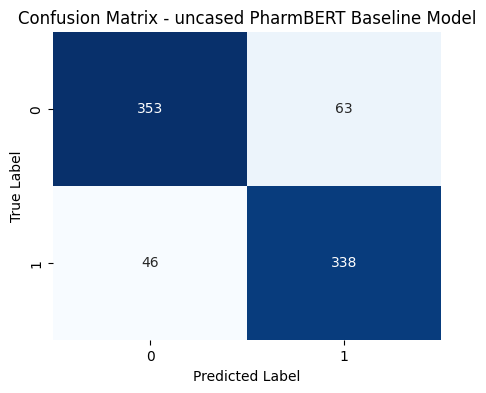

In [ ]:
# Model Evaluate
evaluate_model("uncased PharmBERT Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/uncased PharmBERT_baseline_loss.csv")

Loss history saved to Data Hasil/uncased PharmBERT_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training uncased PharmBERT with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.523600,0.585204,0.775000,0.785203,0.724670,0.856771
2,0.454900,0.477154,0.791250,0.806039,0.727463,0.903646
3,0.395300,0.513364,0.800000,0.782016,0.820000,0.747396
4,0.345200,0.480471,0.843750,0.830853,0.864789,0.799479
5,0.310700,0.517656,0.818750,0.815756,0.796526,0.835938
6,0.270000,0.599684,0.833750,0.819539,0.855524,0.786458
7,0.257000,0.615906,0.827500,0.831707,0.782110,0.888021
8,0.215900,0.674269,0.835000,0.837438,0.794393,0.885417
9,0.223000,0.586750,0.857500,0.850394,0.857143,0.843750
10,0.175400,0.593880,0.851250,0.846847,0.837150,0.856771


=== uncased PharmBERT adp=0.1 hdp=0.1 ===
Accuracy: 0.835
Precision: 0.8264248704663213
Recall: 0.8307291666666666
F1: 0.8285714285714286
Confusion Matrix:
[[349  67]
 [ 65 319]]



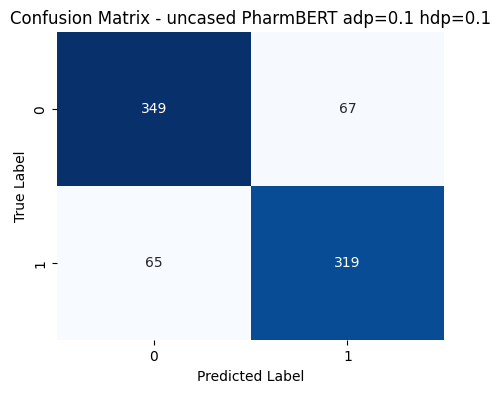


=== Training uncased PharmBERT with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.543600,0.749143,0.773750,0.767651,0.756962,0.778646
2,0.469400,0.509118,0.747500,0.779956,0.670412,0.932292
3,0.413700,0.502826,0.801250,0.786003,0.813370,0.760417
4,0.368700,0.584416,0.811250,0.810063,0.783455,0.838542
5,0.345600,0.469033,0.826250,0.824716,0.799511,0.851562
6,0.337800,0.560723,0.826250,0.818301,0.821522,0.815104
7,0.311200,0.651709,0.831250,0.836364,0.782313,0.898438
8,0.278000,0.770705,0.832500,0.827763,0.817259,0.838542
9,0.251900,0.748722,0.852500,0.852500,0.819712,0.888021
10,0.243700,0.672798,0.845000,0.843434,0.818627,0.869792


=== uncased PharmBERT adp=0.1 hdp=0.2 ===
Accuracy: 0.85
Precision: 0.8333333333333334
Recall: 0.859375
F1: 0.8461538461538461
Confusion Matrix:
[[350  66]
 [ 54 330]]



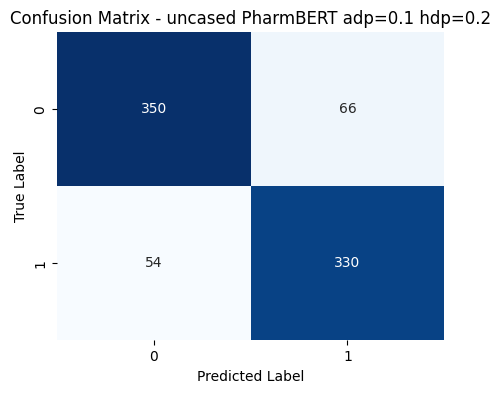


=== Training uncased PharmBERT with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.583200,0.755960,0.747500,0.733509,0.743316,0.723958
2,0.484500,0.530814,0.766250,0.782305,0.707368,0.875000
3,0.442900,0.544811,0.806250,0.800515,0.791349,0.809896
4,0.414000,0.553823,0.801250,0.784261,0.818697,0.752604
5,0.369500,0.686730,0.795000,0.793451,0.768293,0.820312
6,0.367000,0.576945,0.823750,0.817121,0.813953,0.820312
7,0.334100,0.815035,0.810000,0.805128,0.792929,0.817708
8,0.337400,0.717325,0.821250,0.813559,0.814621,0.812500
9,0.305000,0.742651,0.820000,0.804878,0.838983,0.773438


=== uncased PharmBERT adp=0.1 hdp=0.3 ===
Accuracy: 0.82
Precision: 0.8389830508474576
Recall: 0.7734375
F1: 0.8048780487804879
Confusion Matrix:
[[359  57]
 [ 87 297]]



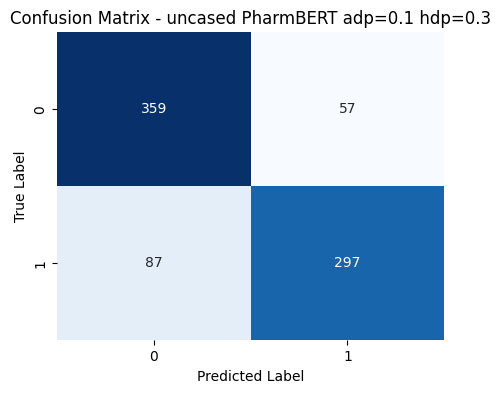


=== Training uncased PharmBERT with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.516500,0.678005,0.781250,0.799542,0.713701,0.908854
2,0.445800,0.436134,0.817500,0.812821,0.800505,0.825521
3,0.384200,0.499368,0.820000,0.801653,0.850877,0.757812
4,0.348900,0.444610,0.835000,0.835411,0.801435,0.872396
5,0.303800,0.754487,0.822500,0.828916,0.771300,0.895833
6,0.278800,0.492892,0.858750,0.846259,0.886040,0.809896
7,0.265200,0.538829,0.846250,0.844106,0.822222,0.867188
8,0.252900,0.618311,0.861250,0.856404,0.850900,0.861979
9,0.231600,0.623367,0.868750,0.859813,0.882192,0.838542
10,0.207600,0.673817,0.853750,0.852830,0.824818,0.882812


=== uncased PharmBERT adp=0.2 hdp=0.1 ===
Accuracy: 0.86625
Precision: 0.8560411311053985
Recall: 0.8671875
F1: 0.8615782664941786
Confusion Matrix:
[[360  56]
 [ 51 333]]



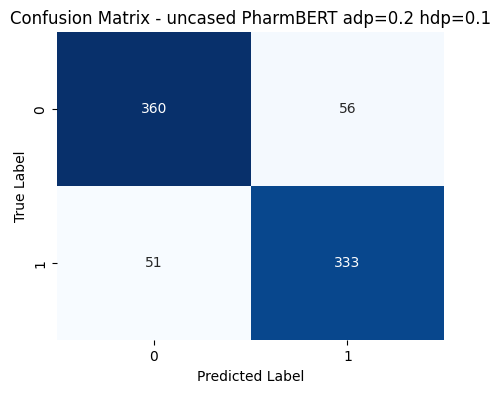


=== Training uncased PharmBERT with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.563300,0.533906,0.796250,0.786928,0.790026,0.783854
2,0.477600,0.477781,0.795000,0.798030,0.757009,0.843750
3,0.457900,0.523921,0.803750,0.811976,0.751663,0.882812
4,0.401100,0.510441,0.798750,0.798498,0.768675,0.830729
5,0.350300,0.622082,0.807500,0.813107,0.761364,0.872396
6,0.339400,0.586671,0.826250,0.808276,0.859238,0.763021
7,0.301300,0.564626,0.831250,0.823067,0.828496,0.817708
8,0.278900,0.669572,0.843750,0.841572,0.819753,0.864583
9,0.267300,0.697314,0.848750,0.841830,0.845144,0.838542
10,0.254200,0.738388,0.828750,0.820446,0.825858,0.815104


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.563300,0.533906,0.796250,0.786928,0.790026,0.783854
2,0.477600,0.477781,0.795000,0.798030,0.757009,0.843750
3,0.457900,0.523921,0.803750,0.811976,0.751663,0.882812
4,0.401100,0.510441,0.798750,0.798498,0.768675,0.830729
5,0.350300,0.622082,0.807500,0.813107,0.761364,0.872396
6,0.339400,0.586671,0.826250,0.808276,0.859238,0.763021
7,0.301300,0.564626,0.831250,0.823067,0.828496,0.817708
8,0.278900,0.669572,0.843750,0.841572,0.819753,0.864583
9,0.267300,0.697314,0.848750,0.841830,0.845144,0.838542
10,0.254200,0.738388,0.828750,0.820446,0.825858,0.815104


=== uncased PharmBERT adp=0.2 hdp=0.2 ===
Accuracy: 0.8425
Precision: 0.8208955223880597
Recall: 0.859375
F1: 0.8396946564885496
Confusion Matrix:
[[344  72]
 [ 54 330]]



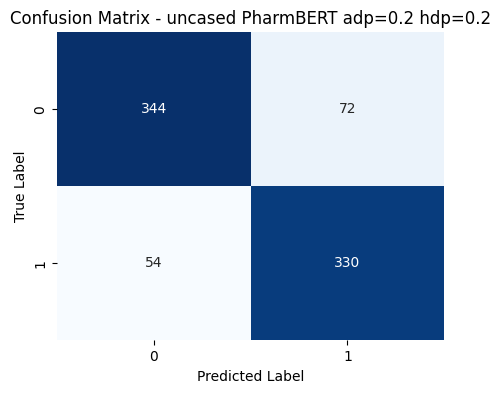


=== Training uncased PharmBERT with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.574500,0.735110,0.766250,0.751660,0.766938,0.736979
2,0.499600,0.472435,0.791250,0.803760,0.732334,0.890625
3,0.448600,0.605823,0.785000,0.760446,0.817365,0.710938
4,0.419300,0.487855,0.801250,0.793238,0.792208,0.794271
5,0.398900,0.492760,0.805000,0.786301,0.829480,0.747396


=== uncased PharmBERT adp=0.2 hdp=0.3 ===
Accuracy: 0.805
Precision: 0.8294797687861272
Recall: 0.7473958333333334
F1: 0.7863013698630137
Confusion Matrix:
[[357  59]
 [ 97 287]]



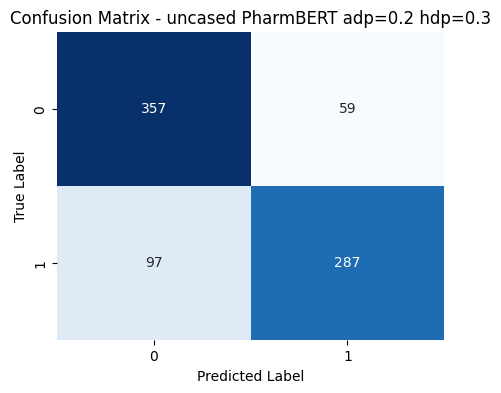


=== Training uncased PharmBERT with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.543500,0.657807,0.761250,0.780207,0.698969,0.882812
2,0.474200,0.460222,0.797500,0.804819,0.748879,0.869792
3,0.446200,0.523315,0.827500,0.816000,0.836066,0.796875
4,0.378800,0.534407,0.831250,0.819277,0.842975,0.796875
5,0.349900,0.533806,0.808750,0.812729,0.766744,0.864583
6,0.335100,0.511813,0.835000,0.824000,0.844262,0.804688
7,0.304100,0.688130,0.818750,0.823815,0.772210,0.882812
8,0.286700,0.660813,0.840000,0.837975,0.815271,0.861979
9,0.236600,0.728059,0.841250,0.842236,0.805226,0.882812
10,0.245100,0.604779,0.845000,0.838542,0.838542,0.838542


=== uncased PharmBERT adp=0.3 hdp=0.1 ===
Accuracy: 0.8575
Precision: 0.8552631578947368
Recall: 0.8463541666666666
F1: 0.8507853403141361
Confusion Matrix:
[[361  55]
 [ 59 325]]



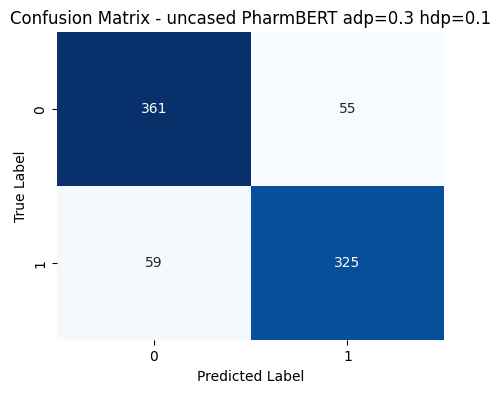


=== Training uncased PharmBERT with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.560400,0.687075,0.778750,0.769831,0.768831,0.770833
2,0.512100,0.581881,0.760000,0.784753,0.688976,0.911458
3,0.473300,0.521563,0.803750,0.804969,0.769596,0.843750
4,0.414000,0.746717,0.785000,0.799065,0.724576,0.890625
5,0.406000,0.641922,0.816250,0.811780,0.798489,0.825521
6,0.373600,0.490078,0.817500,0.813299,0.798995,0.828125
7,0.346500,0.723883,0.808750,0.806574,0.783784,0.830729
8,0.399100,0.719242,0.821250,0.825822,0.775744,0.882812
9,0.348700,0.683713,0.831250,0.825806,0.818414,0.833333
10,0.305500,0.654058,0.840000,0.839196,0.810680,0.869792


=== uncased PharmBERT adp=0.3 hdp=0.2 ===
Accuracy: 0.85375
Precision: 0.8329177057356608
Recall: 0.8697916666666666
F1: 0.8509554140127389
Confusion Matrix:
[[349  67]
 [ 50 334]]



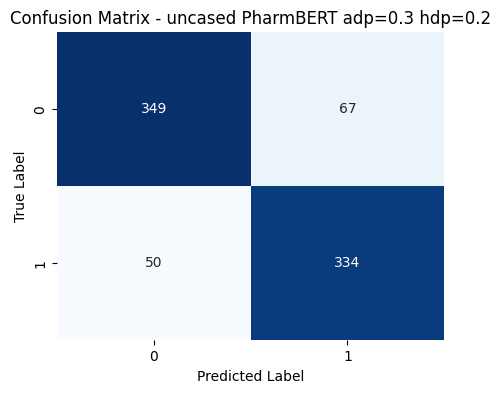


=== Training uncased PharmBERT with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.597100,0.867671,0.736250,0.705718,0.759760,0.658854
2,0.519000,0.483516,0.788750,0.792638,0.749420,0.841146
3,0.467100,0.556532,0.790000,0.770492,0.810345,0.734375
4,0.452700,0.502263,0.807500,0.802564,0.790404,0.815104
5,0.405600,0.623728,0.816250,0.807339,0.812665,0.802083
6,0.399300,0.529642,0.802500,0.791557,0.802139,0.781250
7,0.362900,0.673635,0.815000,0.819512,0.770642,0.875000
8,0.381500,0.780176,0.817500,0.816121,0.790244,0.843750
9,0.341300,0.702328,0.826250,0.814419,0.835616,0.794271
10,0.353700,0.601407,0.828750,0.821847,0.820779,0.822917


=== uncased PharmBERT adp=0.3 hdp=0.3 ===
Accuracy: 0.84625
Precision: 0.8372093023255814
Recall: 0.84375
F1: 0.8404669260700389
Confusion Matrix:
[[353  63]
 [ 60 324]]



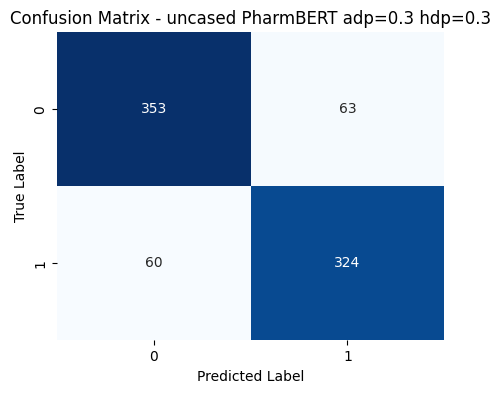

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training uncased PharmBERT with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
           "Lianglab/PharmBERT-uncased",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"uncased PharmBERT adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning uncased PharmBERT ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning uncased PharmBERT ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.83500   0.826425   
1                           0.1                  0.2   0.85000   0.833333   
2                           0.1                  0.3   0.82000   0.838983   
3                           0.2                  0.1   0.86625   0.856041   
4                           0.2                  0.2   0.84250   0.820896   
5                           0.2                  0.3   0.80500   0.829480   
6                           0.3                  0.1   0.85750   0.855263   
7                           0.3                  0.2   0.85375   0.832918   
8                           0.3                  0.3   0.84625   0.837209   

     Recall        F1  
0  0.830729  0.828571  
1  0.859375  0.846154  
2  0.773438  0.804878  
3  0.867188  0.861578  
4  0.859375  0.839695  
5  0.747396  0.786301  
6 

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
3,0.2,0.1,0.86625,0.856041,0.867188,0.861578


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.1)

In [ ]:
df_results.to_csv('Data Hasil/uncased PharmBERT Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\nuncased PharmBERT TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("Lianglab/PharmBERT-uncased")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("Lianglab/PharmBERT-uncased", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_uncased_PharmBERT")
        np.save("Data Hasil/Best_Model_uncased_PharmBERT/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-07 12:40:33,806] A new study created in memory with name: no-name-578150d5-d8e3-4b30-9880-112d0650571a


Start Hyperparameter Tunning

uncased PharmBERT TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.504800,0.574986,0.796250,0.797011,0.763723,0.833333
2,0.419200,0.441023,0.805000,0.803030,0.779412,0.828125
3,0.377600,0.561689,0.795000,0.770308,0.833333,0.716146
4,0.343700,0.514046,0.825000,0.807692,0.854651,0.765625
5,0.311900,0.538164,0.831250,0.831461,0.798561,0.867188
6,0.284500,0.554030,0.848750,0.830295,0.899696,0.770833
7,0.247300,0.677453,0.841250,0.839849,0.814181,0.867188
8,0.249600,0.719353,0.833750,0.838396,0.785877,0.898438
9,0.200400,0.754128,0.856250,0.855346,0.827251,0.885417
10,0.214000,0.656491,0.857500,0.855330,0.834158,0.877604



 Nilai Terbaik Baru Ditemukan
Menyimpan Model Baru


...

[I 2026-01-07 15:09:06,743] Trial 16 finished with value: 0.8688946015424165 and parameters: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 11 with value: 0.8727735368956743.



uncased PharmBERT TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.545700,0.491273,0.791250,0.780552,0.787798,0.773438
2,0.419800,0.480302,0.790000,0.801887,0.732759,0.885417
3,0.361700,0.434730,0.820000,0.817259,0.797030,0.838542
4,0.300900,0.422947,0.845000,0.832884,0.863128,0.804688
5,0.272000,0.443284,0.836250,0.829205,0.830287,0.828125
6,0.229100,0.421618,0.853750,0.849421,0.839695,0.859375
7,0.213200,0.462735,0.853750,0.845850,0.856000,0.835938
8,0.167800,0.672144,0.840000,0.845411,0.788288,0.911458
9,0.163900,0.593707,0.862500,0.857143,0.854922,0.859375
10,0.156300,0.585265,0.856250,0.851613,0.843990,0.859375


[I 2026-01-07 15:17:25,084] Trial 17 finished with value: 0.8571428571428571 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 11 with value: 0.8727735368956743.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_uncased_PharmBERT.csv", index=False)
joblib.dump(study, f"Data Hasil/study_uncased_PharmBERT.pkl")

In [ ]:
data_pharmbert_uncased = pd.read_csv("Data Hasil/optuna_results_uncased_PharmBERT.csv")
data_pharmbert_uncased

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.855346,2026-01-07 12:40:33.807891,2026-01-07 12:49:50.982215,0 days 00:09:17.174324,8,0.00002,0.01,0.85625,"[[357, 59], [56, 328]]",0.855346,0.827251,0.885417,"[0.5048, 0.4192, 0.3776, 0.3437, 0.3119, 0.284...","[0.5749862790107727, 0.4410225749015808, 0.561...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.854592,2026-01-07 12:49:50.983542,2026-01-07 12:59:05.754164,0 days 00:09:14.770622,8,0.00005,0.00,0.85750,"[[357, 59], [57, 327]]",0.854592,0.837500,0.872396,"[0.5541, 0.4901, 0.4363, 0.3704, 0.3279, 0.311...","[0.6202275156974792, 0.509519100189209, 0.5423...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.859671,2026-01-07 12:59:05.755162,2026-01-07 13:06:55.939195,0 days 00:07:50.184033,8,0.00005,0.10,0.86125,"[[358, 58], [66, 318]]",0.859671,0.835381,0.885417,"[0.5224, 0.4691, 0.4036, 0.3461, 0.3124, 0.278...","[0.7335566878318787, 0.47273755073547363, 0.54...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.860131,2026-01-07 13:06:55.940165,2026-01-07 13:15:24.495016,0 days 00:08:28.554851,16,0.00002,0.01,0.86625,"[[369, 47], [61, 323]]",0.860131,0.863517,0.856771,"[0.5389, 0.3898, 0.3204, 0.2751, 0.2395, 0.231...","[0.4940434992313385, 0.48797282576560974, 0.41...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.866060,2026-01-07 13:15:24.495930,2026-01-07 13:22:23.417047,0 days 00:06:58.921117,16,0.00003,0.10,0.87125,"[[365, 51], [61, 323]]",0.866060,0.864935,0.867188,"[0.5132, 0.4063, 0.3476, 0.2748, 0.2498, 0.231...","[0.4847189784049988, 0.5164927840232849, 0.412...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.848718,2026-01-07 13:22:23.417911,2026-01-07 13:29:21.465751,0 days 00:06:58.047840,8,0.00003,0.01,0.85250,"[[357, 59], [58, 326]]",0.848718,0.835859,0.861979,"[0.515, 0.4179, 0.3691, 0.3265, 0.2829, 0.2618...","[0.5611470937728882, 0.4446321129798889, 0.465...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.853234,2026-01-07 13:29:21.467197,2026-01-07 13:37:49.801086,0 days 00:08:28.333889,8,0.00002,0.10,0.85250,"[[354, 62], [53, 331]]",0.853234,0.816667,0.893229,"[0.5111, 0.4099, 0.3559, 0.3122, 0.2904, 0.264...","[0.5699703097343445, 0.436131089925766, 0.4705...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.855643,2026-01-07 13:37:49.801992,2026-01-07 13:45:27.307742,0 days 00:07:37.505750,16,0.00005,0.01,0.86250,"[[337, 79], [46, 338]]",0.855643,0.862434,0.848958,"[0.5154, 0.3985, 0.3318, 0.2934, 0.268, 0.2246...","[0.49528804421424866, 0.44997474551200867, 0.4...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.871009,2026-01-07 13:45:27.308736,2026-01-07 13:55:15.041974,0 days 00:09:47.733238,16,0.00005,0.10,0.87375,"[[358, 58], [52, 332]]",0.871009,0.854637,0.888021,"[0.5152, 0.3971, 0.3359, 0.289, 0.2505, 0.2468...","[0.4917122721672058, 0.4399910271167755, 0.434...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.849351,2026-01-07 13:55:15.043521,2026-01-07 14:00:07.854278,0 days 00:04:52.810757,16,0.00002,0.00,0.85500,"[[357, 59], [58, 326]]",0.849351,0.847150,0.851562,"[0.5384, 0.4068, 0.3334, 0.2983, 0.2668, 0.226...","[0.5091117024421692, 0.4536621868610382, 0.446...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_pharmbert_uncased.sort_values(by='value', ascending=False, inplace=True)
data_pharmbert_uncased

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
11,11,0.872774,2026-01-07 14:07:48.928628,2026-01-07 14:20:54.067160,0 days 00:13:05.138532,16,0.00003,0.01,0.87500,"[[363, 53], [50, 334]]",0.872774,0.853234,0.893229,"[0.5392, 0.3928, 0.3218, 0.2799, 0.2496, 0.235...","[0.47888168692588806, 0.4813709259033203, 0.43...",11,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.871009,2026-01-07 13:45:27.308736,2026-01-07 13:55:15.041974,0 days 00:09:47.733238,16,0.00005,0.10,0.87375,"[[358, 58], [52, 332]]",0.871009,0.854637,0.888021,"[0.5152, 0.3971, 0.3359, 0.289, 0.2505, 0.2468...","[0.4917122721672058, 0.4399910271167755, 0.434...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
16,16,0.868895,2026-01-07 14:58:04.447685,2026-01-07 15:09:06.743185,0 days 00:11:02.295500,16,0.00005,0.00,0.87250,"[[347, 69], [41, 343]]",0.868895,0.857868,0.880208,"[0.4998, 0.4096, 0.3386, 0.284, 0.246, 0.237, ...","[0.5060269236564636, 0.4432762861251831, 0.441...",16,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.866060,2026-01-07 13:15:24.495930,2026-01-07 13:22:23.417047,0 days 00:06:58.921117,16,0.00003,0.10,0.87125,"[[365, 51], [61, 323]]",0.866060,0.864935,0.867188,"[0.5132, 0.4063, 0.3476, 0.2748, 0.2498, 0.231...","[0.4847189784049988, 0.5164927840232849, 0.412...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
12,12,0.864385,2026-01-07 14:20:54.068144,2026-01-07 14:31:56.094027,0 days 00:11:02.025883,16,0.00002,0.10,0.86625,"[[352, 64], [51, 333]]",0.864385,0.841975,0.888021,"[0.5414, 0.4067, 0.3561, 0.2966, 0.2644, 0.240...","[0.4862145185470581, 0.49043697118759155, 0.42...",12,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
14,14,0.863920,2026-01-07 14:41:09.432595,2026-01-07 14:50:22.786477,0 days 00:09:13.353882,8,0.00002,0.00,0.86375,"[[343, 73], [50, 334]]",0.863920,0.829736,0.901042,"[0.4997, 0.428, 0.3729, 0.3323, 0.306, 0.261, ...","[0.5526100993156433, 0.4581071436405182, 0.465...",14,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
13,13,0.860435,2026-01-07 14:31:56.094857,2026-01-07 14:41:09.431587,0 days 00:09:13.336730,8,0.00003,0.00,0.86375,"[[358, 58], [52, 332]]",0.860435,0.846348,0.875000,"[0.5133, 0.4309, 0.3779, 0.3285, 0.2884, 0.266...","[0.514850914478302, 0.4738706350326538, 0.5584...",13,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.860131,2026-01-07 13:06:55.940165,2026-01-07 13:15:24.495016,0 days 00:08:28.554851,16,0.00002,0.01,0.86625,"[[369, 47], [61, 323]]",0.860131,0.863517,0.856771,"[0.5389, 0.3898, 0.3204, 0.2751, 0.2395, 0.231...","[0.4940434992313385, 0.48797282576560974, 0.41...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.859671,2026-01-07 12:59:05.755162,2026-01-07 13:06:55.939195,0 days 00:07:50.184033,8,0.00005,0.10,0.86125,"[[358, 58], [66, 318]]",0.859671,0.835381,0.885417,"[0.5224, 0.4691, 0.4036, 0.3461, 0.3124, 0.278...","[0.7335566878318787, 0.47273755073547363, 0.54...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
17,17,0.857143,2026-01-07 15:09:06.743912,2026-01-07 15:17:25.083917,0 days 00:08:18.340005,16,0.00003,0.00,0.86250,"[[369, 47], [68, 316]]",0.857143,0.854922,0.859375,"[0.5457, 0.4198, 0.3617, 0.3009, 0.272, 0.2291...","[0.4912734925746918, 0.4803016781806946, 0.434...",17,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


# TRANSFORMERS PharmBERT MODEL 2 ("Lianglab/PharmBERT-cased")

## Split Data

In [ ]:
# Definisikan X dan y
X = df['Smiles']
y = df['Label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Reset index for integer-based indexing in the custom Dataset
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Define Model

In [ ]:
model_name = "Lianglab/PharmBERT-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
best_f1_temp = -1.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Ubah dataset ke format hugging face
train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({"text": X_test, "labels": y_test}).map(tokenize, batched=True)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1866
})

In [ ]:
train_dataset[1]

{'labels': tensor(1),
 'input_ids': tensor([  101, 21362,  1475,   134,   140,  2249,   134,   140,   113,   151,
           134,   140,  1475, 15517,  1477,   134,   140,   113,  9314,   134,
           140,  1477,   114,   140,   113,   134,   152,   114,   152,  1658,
           114, 14056,  1495,   134,   140,   113,   140,   134,   140,   113,
           140,   134,   140,  1495,   114,   151,  1527, 12096,  1658,   113,
         21362,  1527,   114,   151,   113,   140,   114,   140,   114,   152,
          1658,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         

## Run Default Model

In [ ]:
# Training Arguments
training_args = TrainingArguments(
  eval_strategy="epoch",
  save_strategy="epoch",
  logging_strategy="epoch",
  load_best_model_at_end=True,
  save_total_limit=1,
  metric_for_best_model="f1",

  num_train_epochs=20,
  seed=seed_value,
  data_seed=seed_value
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

/tmp/ipython-input-3157159542.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.511300,0.813925,0.750000,0.773756,0.684000,0.890625
2,0.449100,0.452388,0.796250,0.805257,0.743929,0.877604
3,0.402500,0.480497,0.810000,0.801047,0.805263,0.796875
4,0.339400,0.614037,0.806250,0.810745,0.763218,0.864583
5,0.315000,0.614258,0.811250,0.822978,0.748401,0.914062
6,0.269900,0.529890,0.833750,0.829268,0.817722,0.841146
7,0.245900,0.628423,0.830000,0.832924,0.788372,0.882812
8,0.238600,0.747832,0.833750,0.838002,0.787185,0.895833
9,0.214200,0.700936,0.851250,0.844850,0.845953,0.843750
10,0.169200,0.735569,0.846250,0.840467,0.837209,0.843750


TrainOutput(global_step=2808, training_loss=0.28765394884636597, metrics={'train_runtime': 666.4891, 'train_samples_per_second': 55.995, 'train_steps_per_second': 7.022, 'total_flos': 1242755736670080.0, 'train_loss': 0.28765394884636597, 'epoch': 12.0})

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       416
           1       0.85      0.84      0.84       384

    accuracy                           0.85       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.85      0.85      0.85       800


Confusion Matrix:
[[357  59]
 [ 60 324]]


=== cased PharmBERT Baseline Model ===
Accuracy: 0.85125
Precision: 0.8459530026109661
Recall: 0.84375
F1: 0.8448500651890483
Confusion Matrix:
[[357  59]
 [ 60 324]]



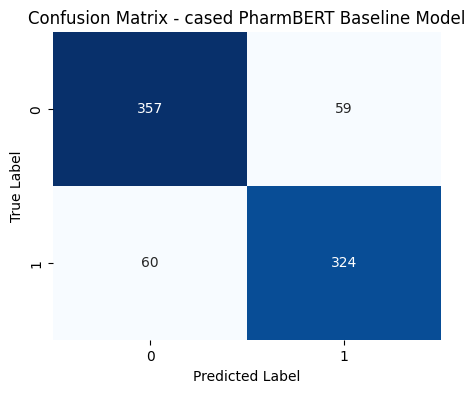

In [ ]:
# Model Evaluate
evaluate_model("cased PharmBERT Baseline Model", y_test, y_pred)

In [ ]:
df_loss_chemberta_baseline = save_loss_from_trainer(trainer, "Data Hasil/cased PharmBERT_baseline_loss.csv")

Loss history saved to Data Hasil/cased PharmBERT_baseline_loss.csv


## Dropout Tunning

In [ ]:
# Kombinasi parameter
attention_dropout = [0.1, 0.2, 0.3]
hidden_dropout = [0.1, 0.2, 0.3]

results = []


=== Training cased PharmBERT with 0.1 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.504100,0.711463,0.798750,0.806723,0.748330,0.875000
2,0.413600,0.437103,0.812500,0.822275,0.754348,0.903646
3,0.378200,0.459777,0.806250,0.787380,0.831884,0.747396
4,0.315500,0.517185,0.827500,0.820312,0.820312,0.820312
5,0.286600,0.684723,0.835000,0.837037,0.795775,0.882812
6,0.274300,0.613396,0.843750,0.837027,0.838120,0.835938
7,0.225100,0.706291,0.848750,0.844673,0.832911,0.856771
8,0.210700,0.799529,0.841250,0.845311,0.794050,0.903646
9,0.178800,0.852093,0.853750,0.847854,0.846753,0.848958
10,0.159200,0.766180,0.852500,0.847938,0.839286,0.856771


=== cased PharmBERT adp=0.1 hdp=0.1 ===
Accuracy: 0.85375
Precision: 0.8264058679706602
Recall: 0.8802083333333334
F1: 0.8524590163934426
Confusion Matrix:
[[345  71]
 [ 46 338]]



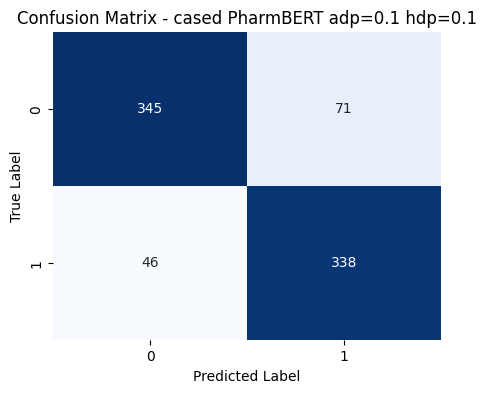


=== Training cased PharmBERT with 0.1 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.520100,0.778145,0.773750,0.786305,0.719222,0.867188
2,0.461100,0.463452,0.801250,0.809124,0.750557,0.877604
3,0.396100,0.421011,0.815000,0.822115,0.763393,0.890625
4,0.346000,0.581891,0.807500,0.810811,0.767442,0.859375
5,0.328900,0.636169,0.821250,0.830368,0.762527,0.911458
6,0.318500,0.507251,0.837500,0.839901,0.796729,0.888021
7,0.275700,0.644330,0.831250,0.831461,0.798561,0.867188
8,0.262800,0.589257,0.847500,0.842377,0.835897,0.848958
9,0.226800,0.699446,0.850000,0.844156,0.841969,0.846354
10,0.211500,0.721481,0.855000,0.846966,0.858289,0.835938


=== cased PharmBERT adp=0.1 hdp=0.2 ===
Accuracy: 0.8425
Precision: 0.8086124401913876
Recall: 0.8802083333333334
F1: 0.8428927680798005
Confusion Matrix:
[[336  80]
 [ 46 338]]



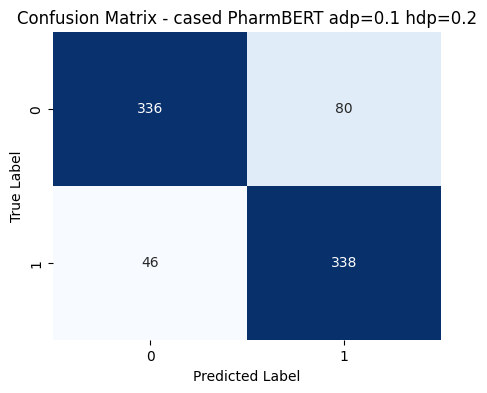


=== Training cased PharmBERT with 0.1 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.609400,0.627057,0.737500,0.748804,0.692478,0.815104
2,0.508400,0.468778,0.773750,0.776819,0.737705,0.820312
3,0.452300,0.454423,0.827500,0.823529,0.809045,0.838542
4,0.401500,0.636154,0.807500,0.809877,0.769953,0.854167
5,0.379100,0.663725,0.838750,0.836502,0.814815,0.859375
6,0.357900,0.446405,0.827500,0.824427,0.805970,0.843750
7,0.321900,0.734128,0.835000,0.839416,0.787671,0.898438
8,0.323100,0.824095,0.821250,0.826667,0.773243,0.888021
9,0.316600,0.733683,0.827500,0.816489,0.834239,0.799479
10,0.297900,0.671889,0.841250,0.834420,0.835509,0.833333


=== cased PharmBERT adp=0.1 hdp=0.3 ===
Accuracy: 0.84125
Precision: 0.835509138381201
Recall: 0.8333333333333334
F1: 0.834419817470665
Confusion Matrix:
[[353  63]
 [ 64 320]]



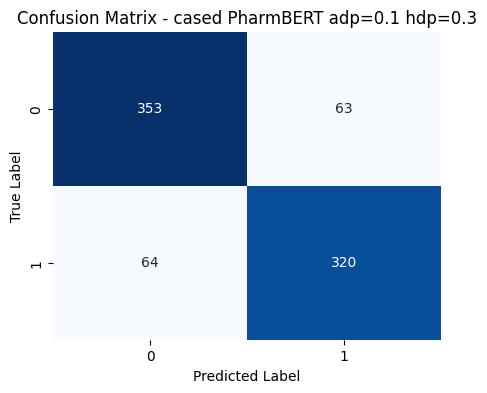


=== Training cased PharmBERT with 0.2 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.521600,0.646264,0.762500,0.784091,0.695565,0.898438
2,0.438700,0.445793,0.808750,0.812729,0.766744,0.864583
3,0.400700,0.418944,0.821250,0.812089,0.819629,0.804688
4,0.347100,0.637217,0.826250,0.833533,0.771619,0.906250
5,0.328200,0.831093,0.810000,0.823666,0.742678,0.924479
6,0.298100,0.592336,0.836250,0.835634,0.806295,0.867188
7,0.290200,0.631219,0.843750,0.849216,0.791011,0.916667
8,0.247100,0.673543,0.852500,0.849490,0.832500,0.867188
9,0.219900,0.717775,0.848750,0.841415,0.846966,0.835938
10,0.210400,0.636747,0.858750,0.857143,0.832924,0.882812


=== cased PharmBERT adp=0.2 hdp=0.1 ===
Accuracy: 0.86625
Precision: 0.8274231678486997
Recall: 0.9114583333333334
F1: 0.8674101610904585
Confusion Matrix:
[[343  73]
 [ 34 350]]



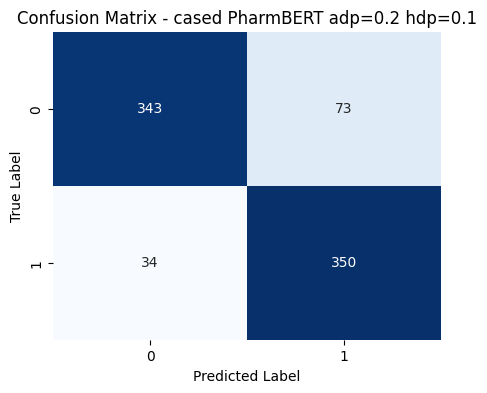


=== Training cased PharmBERT with 0.2 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.557700,0.649560,0.766250,0.776583,0.717439,0.846354
2,0.464600,0.479921,0.806250,0.809816,0.765661,0.859375
3,0.425700,0.475334,0.805000,0.798969,0.790816,0.807292
4,0.381100,0.670024,0.808750,0.813642,0.764302,0.869792
5,0.373200,0.579239,0.825000,0.829684,0.778539,0.888021
6,0.326400,0.525442,0.837500,0.832905,0.822335,0.843750
7,0.327400,0.733916,0.818750,0.819427,0.785203,0.856771
8,0.303100,0.776336,0.823750,0.823529,0.792771,0.856771
9,0.294700,0.635224,0.831250,0.830189,0.802920,0.859375


=== cased PharmBERT adp=0.2 hdp=0.2 ===
Accuracy: 0.83125
Precision: 0.8029197080291971
Recall: 0.859375
F1: 0.8301886792452831
Confusion Matrix:
[[335  81]
 [ 54 330]]



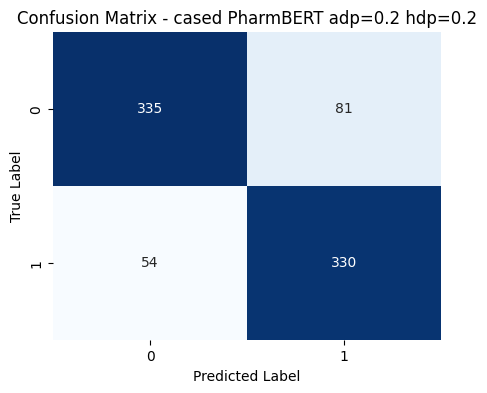


=== Training cased PharmBERT with 0.2 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.628200,0.702669,0.695000,0.733042,0.632075,0.872396
2,0.535300,0.503309,0.765000,0.787330,0.696000,0.906250
3,0.453400,0.491123,0.781250,0.794842,0.722814,0.882812
4,0.408100,0.482332,0.818750,0.818068,0.789346,0.848958
5,0.386000,0.562567,0.807500,0.813107,0.761364,0.872396
6,0.360300,0.516018,0.821250,0.817834,0.800499,0.835938
7,0.353700,0.929311,0.796250,0.814139,0.724138,0.929688


=== cased PharmBERT adp=0.2 hdp=0.3 ===
Accuracy: 0.79625
Precision: 0.7241379310344828
Recall: 0.9296875
F1: 0.814139110604333
Confusion Matrix:
[[280 136]
 [ 27 357]]



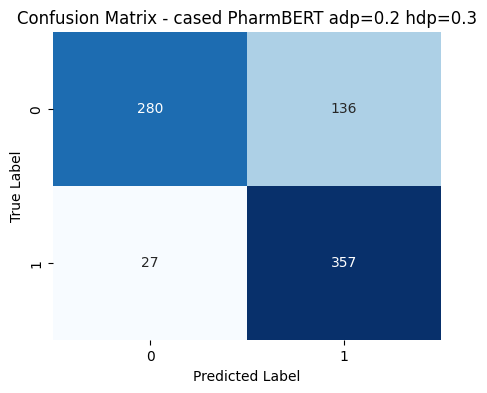


=== Training cased PharmBERT with 0.3 attention_probs_dropout_prob and 0.1 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.522100,0.620171,0.780000,0.789474,0.730088,0.859375
2,0.456600,0.460371,0.803750,0.805933,0.767059,0.848958
3,0.419800,0.530218,0.803750,0.793693,0.801061,0.786458
4,0.363100,0.517823,0.822500,0.811170,0.828804,0.794271
5,0.355900,0.462663,0.835000,0.838235,0.791667,0.890625
6,0.317900,0.467190,0.825000,0.820513,0.808081,0.833333
7,0.331300,0.592421,0.823750,0.823529,0.792771,0.856771
8,0.291700,0.759848,0.830000,0.836538,0.776786,0.906250


=== cased PharmBERT adp=0.3 hdp=0.1 ===
Accuracy: 0.83
Precision: 0.7767857142857143
Recall: 0.90625
F1: 0.8365384615384616
Confusion Matrix:
[[316 100]
 [ 36 348]]



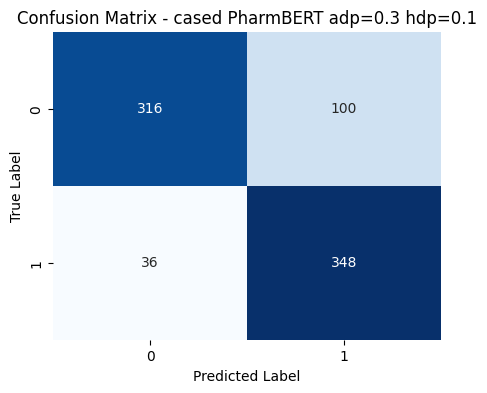


=== Training cased PharmBERT with 0.3 attention_probs_dropout_prob and 0.2 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.555000,0.638526,0.741250,0.755608,0.691145,0.833333
2,0.491300,0.574018,0.770000,0.792793,0.698413,0.916667
3,0.436300,0.491985,0.811250,0.803641,0.802597,0.804688
4,0.387200,0.746967,0.803750,0.815077,0.744086,0.901042
5,0.386800,0.521710,0.806250,0.817001,0.747300,0.901042
6,0.343700,0.536530,0.826250,0.822930,0.805486,0.841146
7,0.334400,0.637996,0.825000,0.830508,0.776018,0.893229
8,0.322700,0.678858,0.821250,0.824969,0.778291,0.877604
9,0.294600,0.640191,0.841250,0.839849,0.814181,0.867188
10,0.295000,0.609169,0.845000,0.844612,0.814010,0.877604


=== cased PharmBERT adp=0.3 hdp=0.2 ===
Accuracy: 0.8325
Precision: 0.7828054298642534
Recall: 0.9010416666666666
F1: 0.837772397094431
Confusion Matrix:
[[320  96]
 [ 38 346]]



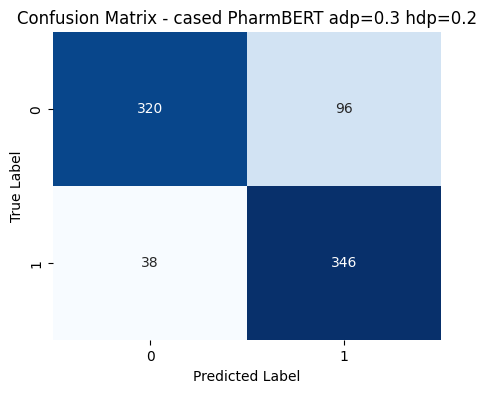


=== Training cased PharmBERT with 0.3 attention_probs_dropout_prob and 0.3 hidden_dropout_prob ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.597600,0.629687,0.747500,0.754258,0.707763,0.807292
2,0.503100,0.581339,0.733750,0.762011,0.667319,0.888021
3,0.460700,0.631665,0.755000,0.782705,0.681467,0.919271
4,0.429000,0.716079,0.793750,0.810127,0.725773,0.916667
5,0.405300,0.643296,0.821250,0.825397,0.777011,0.880208
6,0.366700,0.498129,0.833750,0.834783,0.798100,0.875000
7,0.373500,0.704226,0.813750,0.821128,0.761693,0.890625
8,0.385200,0.794428,0.810000,0.820755,0.750000,0.906250
9,0.359100,0.714054,0.842500,0.840506,0.817734,0.864583
10,0.359500,0.764826,0.817500,0.827014,0.758696,0.908854


=== cased PharmBERT adp=0.3 hdp=0.3 ===
Accuracy: 0.82375
Precision: 0.7941888619854721
Recall: 0.8541666666666666
F1: 0.823086574654956
Confusion Matrix:
[[331  85]
 [ 56 328]]



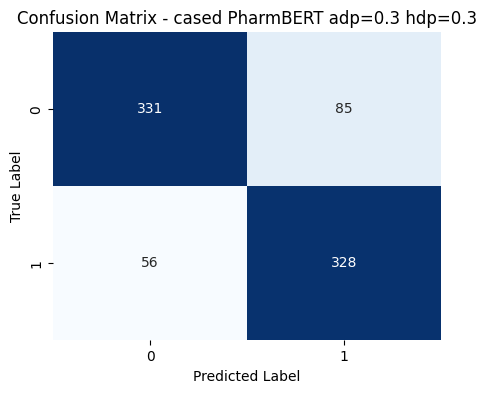

In [ ]:
for adp in attention_dropout:
    for hdp in hidden_dropout:
        print(f"\n=== Training cased PharmBERT with {adp} attention_probs_dropout_prob and {hdp} hidden_dropout_prob ===")

        # Load model untuk dropout tunning
        model = AutoModelForSequenceClassification.from_pretrained(
           "Lianglab/PharmBERT-cased",
            num_labels=2,
            attention_probs_dropout_prob=adp,
            hidden_dropout_prob=hdp
        )

        # --- Training args ---
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            load_best_model_at_end=False,
            save_total_limit=1,
            metric_for_best_model="f1",

            num_train_epochs=20,
            seed=seed_value,
            data_seed=seed_value,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        )

        # --- Train ---
        trainer.train()

        # --- Predict ---
        preds = trainer.predict(test_dataset)
        y_pred = preds.predictions.argmax(axis=1)
        y_true = preds.label_ids

        # --- Evaluasi ---
        acc, prec, rec, f1 = evaluate_tunning(f"cased PharmBERT adp={adp} hdp={hdp}", y_true, y_pred)
        results.append({
            "attention_probs_dropout_prob": adp,
            "hidden_dropout_prob": hdp,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

In [ ]:
# Simpan hasil ke DataFrame
df_results = pd.DataFrame(results)
print("\n=== Ringkasan Hasil Dropout Tunning cased PharmBERT ===")
print(df_results)


=== Ringkasan Hasil Dropout Tunning cased PharmBERT ===
   attention_probs_dropout_prob  hidden_dropout_prob  Accuracy  Precision  \
0                           0.1                  0.1   0.85375   0.826406   
1                           0.1                  0.2   0.84250   0.808612   
2                           0.1                  0.3   0.84125   0.835509   
3                           0.2                  0.1   0.86625   0.827423   
4                           0.2                  0.2   0.83125   0.802920   
5                           0.2                  0.3   0.79625   0.724138   
6                           0.3                  0.1   0.83000   0.776786   
7                           0.3                  0.2   0.83250   0.782805   
8                           0.3                  0.3   0.82375   0.794189   

     Recall        F1  
0  0.880208  0.852459  
1  0.880208  0.842893  
2  0.833333  0.834420  
3  0.911458  0.867410  
4  0.859375  0.830189  
5  0.929688  0.814139  
6  0

In [ ]:
df_results_sort = df_results.sort_values(by='F1', ascending=False)
df_results_sort.head(1)

,attention_probs_dropout_prob,hidden_dropout_prob,Accuracy,Precision,Recall,F1
3,0.2,0.1,0.86625,0.827423,0.911458,0.86741


In [ ]:
best_adp = df_results_sort.iloc[0]['attention_probs_dropout_prob']
best_hdp = df_results_sort.iloc[0]['hidden_dropout_prob']

In [ ]:
best_hdp

np.float64(0.1)

In [ ]:
df_results.to_csv('Data Hasil/cased PharmBERT Tuning Dropout.csv', index=False)

## Hyperparameter Tunning

In [ ]:
def objective(trial):
    global seed_value, best_f1_temp, best_adp, best_hdp


    # List Hyperparameter
    lr = trial.suggest_categorical("learning_rate", [2e-5, 3e-5, 5e-5])
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    bs = trial.suggest_categorical("batch_size", [8, 16])

    print(f"\ncased PharmBERT TRIAL {trial.number}: LR={lr:.2e}, WD={wd:.4f}, BS={bs}")

    # Setup Model
    config = AutoConfig.from_pretrained("Lianglab/PharmBERT-cased")
    config.attention_probs_dropout_prob = best_adp
    config.hidden_dropout_prob = best_hdp
    config.num_labels = 2

    model = AutoModelForSequenceClassification.from_pretrained("Lianglab/PharmBERT-cased", config=config, ignore_mismatched_sizes=True)

    # Define Training Args Untuk Tunning
    args = TrainingArguments(
        eval_strategy="epoch",
        logging_strategy="epoch",

        save_strategy="no",
        load_best_model_at_end=False,

        metric_for_best_model="f1",
        save_total_limit=1,

        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=20,

        seed=seed_value,
        data_seed=seed_value,
        report_to="none"
    )

    # Siapkan Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Train Trainer
    trainer.train()

    # Ambil Log History
    history = trainer.state.log_history

    # Ambil list metric
    eval_f1_list   = [x['eval_f1'] for x in history if 'eval_f1' in x]
    eval_acc_list  = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    eval_prec_list = [x['eval_precision'] for x in history if 'eval_precision' in x]
    eval_rec_list  = [x['eval_recall'] for x in history if 'eval_recall' in x]

    # Cari Nilai Metrik Terbaik
    if eval_f1_list:
        # Cari nilai terbaik
        best_f1 = max(eval_f1_list)
        best_idx = np.argmax(eval_f1_list)

        # Ambil metric lain di index yang sama
        best_acc  = eval_acc_list[best_idx]
        best_prec = eval_prec_list[best_idx]
        best_rec  = eval_rec_list[best_idx]
    else:
        best_f1, best_acc, best_prec, best_rec = 0.0, 0.0, 0.0, 0.0

    # Save Angka ke CSV
    trial.set_user_attr("f1", best_f1)
    trial.set_user_attr("accuracy", best_acc)
    trial.set_user_attr("precision", best_prec)
    trial.set_user_attr("recall", best_rec)

    trial.set_user_attr("train_loss_history", [x['loss'] for x in history if 'loss' in x])
    trial.set_user_attr("val_loss_history", [x['eval_loss'] for x in history if 'eval_loss' in x])

    # Save Confusion Matrix
    preds = trainer.predict(test_dataset)
    cm = confusion_matrix(preds.label_ids, np.argmax(preds.predictions, axis=1))

    # Simpan Confusion Matrix (Format: [[TN, FP], [FN, TP]])
    trial.set_user_attr("confusion_matrix", str(cm.tolist()))

    # Save Best Model
    if best_f1 > best_f1_temp:
        print(f"\n Nilai Terbaik Baru Ditemukan")
        print("Menyimpan Model Baru")

        best_f1_temp = best_f1
        trainer.save_model("Data Hasil/Best_Model_cased_PharmBERT")
        np.save("Data Hasil/Best_Model_cased_PharmBERT/confusion_matrix.npy", cm)

    del model, trainer
    torch.cuda.empty_cache()

    return best_f1

In [ ]:
# Definisikan Ruang Pencarian
search_space = {
    "learning_rate": [2e-5, 3e-5, 5e-5],
    "weight_decay": [0.0, 0.01, 0.1],
    "batch_size": [8, 16]
}

# Setup Optuna Dengan Search Space
sampler = GridSampler(search_space)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Start Optuna
print("Start Hyperparameter Tunning")
study.optimize(objective)

[I 2026-01-07 17:52:59,910] A new study created in memory with name: no-name-04b0848a-6494-450f-ab3e-9f09ff1aa6e5


Start Hyperparameter Tunning

cased PharmBERT TRIAL 0: LR=2.00e-05, WD=0.0100, BS=8


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.507900,0.541527,0.793750,0.798535,0.751724,0.851562
2,0.411800,0.427388,0.822500,0.827251,0.776256,0.885417
3,0.345600,0.550261,0.821250,0.802759,0.853372,0.757812
4,0.329800,0.524809,0.830000,0.826531,0.810000,0.843750
5,0.301900,0.481369,0.846250,0.842510,0.828715,0.856771
6,0.277100,0.526851,0.851250,0.847240,0.835443,0.859375
7,0.227700,0.680634,0.841250,0.838628,0.818859,0.859375
8,0.236800,0.706557,0.843750,0.845488,0.804706,0.890625
9,0.208400,0.756738,0.852500,0.849873,0.830846,0.869792
10,0.196500,0.739559,0.853750,0.847458,0.848564,0.846354



 Nilai Terbaik Baru Ditemukan
Menyimpan Model Baru


...

[I 2026-01-07 20:32:47,471] Trial 16 finished with value: 0.8312020460358056 and parameters: {'learning_rate': 5e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 12 with value: 0.8728179551122195.



cased PharmBERT TRIAL 17: LR=3.00e-05, WD=0.0000, BS=16


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Lianglab/PharmBERT-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.524600,0.466003,0.775000,0.768638,0.758883,0.778646
2,0.393100,0.451018,0.800000,0.802956,0.761682,0.848958
3,0.342000,0.403323,0.818750,0.809461,0.816976,0.802083
4,0.286700,0.396466,0.833750,0.826597,0.827676,0.825521
5,0.245400,0.502764,0.833750,0.828829,0.819338,0.838542
6,0.230600,0.462481,0.852500,0.852130,0.821256,0.885417
7,0.195900,0.534940,0.842500,0.834646,0.841270,0.828125
8,0.195300,0.533232,0.851250,0.852174,0.814727,0.893229
9,0.168000,0.653564,0.847500,0.844784,0.825871,0.864583
10,0.157700,0.614626,0.857500,0.847594,0.870879,0.825521


[I 2026-01-07 20:40:32,181] Trial 17 finished with value: 0.8521739130434782 and parameters: {'learning_rate': 3e-05, 'weight_decay': 0.0, 'batch_size': 16}. Best is trial 12 with value: 0.8728179551122195.


In [ ]:
# Save Study Results
print("\n=== BEST RESULT ===")
print(f"Best F1: {study.best_value}")
print(f"Best Params: {study.best_params}")

df_results = study.trials_dataframe()
df_results.to_csv(f"Data Hasil/optuna_results_cased_PharmBERT.csv", index=False)
joblib.dump(study, f"Data Hasil/study_cased_PharmBERT.pkl")


=== BEST RESULT ===
Best F1: 0.8728179551122195
Best Params: {'learning_rate': 2e-05, 'weight_decay': 0.1, 'batch_size': 16}


['Data Hasil/study_cased_PharmBERT.pkl']

In [ ]:
data_pharmbert_cased = pd.read_csv("Data Hasil/optuna_results_cased_PharmBERT.csv")
data_pharmbert_cased

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.852792,2026-01-07 17:52:59.912344,2026-01-07 18:03:51.307974,0 days 00:10:51.395630,8,0.00002,0.01,0.85500,"[[348, 68], [52, 332]]",0.852792,0.831683,0.875000,"[0.5079, 0.4118, 0.3456, 0.3298, 0.3019, 0.277...","[0.5415269136428833, 0.42738837003707886, 0.55...",0,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.857143,2026-01-07 18:03:51.308880,2026-01-07 18:11:39.872207,0 days 00:07:48.563327,8,0.00005,0.00,0.86125,"[[353, 63], [62, 322]]",0.857143,0.847328,0.867188,"[0.5182, 0.4592, 0.4119, 0.367, 0.3314, 0.3012...","[0.6792790293693542, 0.45740455389022827, 0.42...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.859296,2026-01-07 18:11:39.873157,2026-01-07 18:21:46.106293,0 days 00:10:06.233136,8,0.00005,0.10,0.86000,"[[343, 73], [43, 341]]",0.859296,0.830097,0.890625,"[0.5215, 0.4374, 0.3978, 0.3299, 0.3121, 0.283...","[0.6569628715515137, 0.4785963296890259, 0.409...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.861893,2026-01-07 18:21:46.107205,2026-01-07 18:32:59.745029,0 days 00:11:13.637824,16,0.00002,0.01,0.86500,"[[343, 73], [40, 344]]",0.861893,0.846734,0.877604,"[0.5292, 0.4014, 0.3523, 0.3038, 0.2678, 0.233...","[0.4838757812976837, 0.45150038599967957, 0.41...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.861076,2026-01-07 18:32:59.746004,2026-01-07 18:40:43.939820,0 days 00:07:44.193816,16,0.00003,0.10,0.86125,"[[355, 61], [52, 332]]",0.861076,0.828916,0.895833,"[0.5375, 0.4133, 0.3499, 0.3121, 0.2622, 0.230...","[0.49868524074554443, 0.5035909414291382, 0.42...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.864796,2026-01-07 18:40:43.940723,2026-01-07 18:54:40.067833,0 days 00:13:56.127110,8,0.00003,0.01,0.86750,"[[341, 75], [45, 339]]",0.864796,0.847500,0.882812,"[0.5411, 0.44, 0.3906, 0.3204, 0.3006, 0.2675,...","[0.7372755408287048, 0.4308371841907501, 0.424...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
6,6,0.852547,2026-01-07 18:54:40.070000,2026-01-07 19:01:41.322074,0 days 00:07:01.252074,8,0.00002,0.10,0.86250,"[[362, 54], [62, 322]]",0.852547,0.878453,0.828125,"[0.513, 0.4256, 0.3678, 0.3402, 0.287, 0.2834,...","[0.6610357761383057, 0.44069457054138184, 0.44...",6,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.860025,2026-01-07 19:01:41.323462,2026-01-07 19:15:39.425698,0 days 00:13:58.102236,16,0.00005,0.01,0.86125,"[[347, 69], [44, 340]]",0.860025,0.833741,0.888021,"[0.5144, 0.3974, 0.3374, 0.3052, 0.2723, 0.251...","[0.5000284314155579, 0.43154647946357727, 0.44...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
8,8,0.847826,2026-01-07 19:15:39.426406,2026-01-07 19:21:19.008064,0 days 00:05:39.581658,16,0.00005,0.10,0.86000,"[[328, 88], [39, 345]]",0.847826,0.886364,0.812500,"[0.5347, 0.4024, 0.3804, 0.3009, 0.2681, 0.231...","[0.477970153093338, 0.4239412546157837, 0.4074...",8,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
9,9,0.847500,2026-01-07 19:21:19.008970,2026-01-07 19:26:16.939697,0 days 00:04:57.930727,16,0.00002,0.00,0.84750,"[[357, 59], [60, 324]]",0.847500,0.814904,0.882812,"[0.5187, 0.3817, 0.3315, 0.2973, 0.2575, 0.230...","[0.46293890476226807, 0.4676365554332733, 0.38...",9,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE


In [ ]:
data_pharmbert_cased.sort_values(by='value', ascending=False, inplace=True)
data_pharmbert_cased

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_weight_decay,user_attrs_accuracy,user_attrs_confusion_matrix,user_attrs_f1,user_attrs_precision,user_attrs_recall,user_attrs_train_loss_history,user_attrs_val_loss_history,system_attrs_grid_id,system_attrs_search_space,state
12,12,0.872818,2026-01-07 19:39:34.290601,2026-01-07 19:52:54.675733,0 days 00:13:20.385132,16,0.00002,0.10,0.87250,"[[350, 66], [41, 343]]",0.872818,0.837321,0.911458,"[0.5213, 0.3884, 0.3381, 0.2991, 0.2513, 0.227...","[0.45301780104637146, 0.5191975235939026, 0.42...",12,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
5,5,0.864796,2026-01-07 18:40:43.940723,2026-01-07 18:54:40.067833,0 days 00:13:56.127110,8,0.00003,0.01,0.86750,"[[341, 75], [45, 339]]",0.864796,0.847500,0.882812,"[0.5411, 0.44, 0.3906, 0.3204, 0.3006, 0.2675,...","[0.7372755408287048, 0.4308371841907501, 0.424...",5,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
3,3,0.861893,2026-01-07 18:21:46.107205,2026-01-07 18:32:59.745029,0 days 00:11:13.637824,16,0.00002,0.01,0.86500,"[[343, 73], [40, 344]]",0.861893,0.846734,0.877604,"[0.5292, 0.4014, 0.3523, 0.3038, 0.2678, 0.233...","[0.4838757812976837, 0.45150038599967957, 0.41...",3,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
14,14,0.861809,2026-01-07 20:04:35.640325,2026-01-07 20:19:16.138631,0 days 00:14:40.498306,8,0.00002,0.00,0.86250,"[[354, 62], [49, 335]]",0.861809,0.832524,0.893229,"[0.5193, 0.414, 0.3689, 0.3245, 0.3139, 0.2811...","[0.5407335162162781, 0.4371824562549591, 0.471...",14,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
4,4,0.861076,2026-01-07 18:32:59.746004,2026-01-07 18:40:43.939820,0 days 00:07:44.193816,16,0.00003,0.10,0.86125,"[[355, 61], [52, 332]]",0.861076,0.828916,0.895833,"[0.5375, 0.4133, 0.3499, 0.3121, 0.2622, 0.230...","[0.49868524074554443, 0.5035909414291382, 0.42...",4,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
13,13,0.860051,2026-01-07 19:52:54.676681,2026-01-07 20:04:35.639533,0 days 00:11:40.962852,8,0.00003,0.00,0.86250,"[[352, 64], [46, 338]]",0.860051,0.840796,0.880208,"[0.5135, 0.4251, 0.3649, 0.3291, 0.305, 0.2777...","[0.6067280173301697, 0.45080703496932983, 0.44...",13,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
7,7,0.860025,2026-01-07 19:01:41.323462,2026-01-07 19:15:39.425698,0 days 00:13:58.102236,16,0.00005,0.01,0.86125,"[[347, 69], [44, 340]]",0.860025,0.833741,0.888021,"[0.5144, 0.3974, 0.3374, 0.3052, 0.2723, 0.251...","[0.5000284314155579, 0.43154647946357727, 0.44...",7,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
2,2,0.859296,2026-01-07 18:11:39.873157,2026-01-07 18:21:46.106293,0 days 00:10:06.233136,8,0.00005,0.10,0.86000,"[[343, 73], [43, 341]]",0.859296,0.830097,0.890625,"[0.5215, 0.4374, 0.3978, 0.3299, 0.3121, 0.283...","[0.6569628715515137, 0.4785963296890259, 0.409...",2,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
15,15,0.858612,2026-01-07 20:19:16.139531,2026-01-07 20:27:49.504672,0 days 00:08:33.365141,8,0.00003,0.10,0.86250,"[[342, 74], [52, 332]]",0.858612,0.847716,0.869792,"[0.5136, 0.4353, 0.3748, 0.3237, 0.2995, 0.285...","[0.599555492401123, 0.4327333867549896, 0.4978...",15,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
1,1,0.857143,2026-01-07 18:03:51.308880,2026-01-07 18:11:39.872207,0 days 00:07:48.563327,8,0.00005,0.00,0.86125,"[[353, 63], [62, 322]]",0.857143,0.847328,0.867188,"[0.5182, 0.4592, 0.4119, 0.367, 0.3314, 0.3012...","[0.6792790293693542, 0.45740455389022827, 0.42...",1,"{'batch_size': [8, 16], 'learning_rate': [2e-0...",COMPLETE
